Post-viewing hippocampal/MTL activity for spatially precise versus spatially imprecise remembered items, with later extension to temporal encoding session e1/e2/e3.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nibabel as nib

from nilearn import image, plotting, datasets
from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm.second_level import SecondLevelModel
from nilearn.reporting import get_clusters_table
from nilearn.maskers import NiftiMasker

from scipy.stats import ttest_1samp, wilcoxon, spearmanr

In [2]:
# --------------------------------------------------
# Project paths
# --------------------------------------------------

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")

BIDS_DIR = PROJECT_ROOT / "data" / "bids_ackbar"
FMRIPREP_DIR = PROJECT_ROOT / "data" / "fmriprep_output"

OUT_DIR = PROJECT_ROOT / "data" / "processed" / "glm" / "spatial_precision_post_viewing"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EVENTS_OUT_DIR = PROJECT_ROOT / "data" / "preprocessed" / "relabeled_events_spatial_precision"
EVENTS_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BIDS_DIR exists:", BIDS_DIR.exists())
print("FMRIPREP_DIR exists:", FMRIPREP_DIR.exists())
print("OUT_DIR:", OUT_DIR)

PROJECT_ROOT: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
BIDS_DIR exists: True
FMRIPREP_DIR exists: True
OUT_DIR: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_precision_post_viewing


In [3]:
# --------------------------------------------------
# Load item-level encoding-post RSA table
# --------------------------------------------------

ENCPOST_ITEM_LEVEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "rsa"
    / "irrelevant_memory"
    / "encoding_post_same_item_roi_rsa_item_level.csv"
)

encpost_item_level = pd.read_csv(ENCPOST_ITEM_LEVEL_PATH)

print("Loaded:", ENCPOST_ITEM_LEVEL_PATH)
print("Shape:", encpost_item_level.shape)
print("Columns:")
print(encpost_item_level.columns.tolist())

display(encpost_item_level.head())

Loaded: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/rsa/irrelevant_memory/encoding_post_same_item_roi_rsa_item_level.csv
Shape: (1604, 12)
Columns:
['sub', 'roi', 'encoding_session', 'event', 'enc_item_id', 'post_item_id', 'memory_label', 'stim_cat', 'encoding_post_similarity', 'placement_distance', 'placement_confidence', 'temporal_confidence']


,sub,roi,encoding_session,event,enc_item_id,post_item_id,memory_label,stim_cat,encoding_post_similarity,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,hippocampus,e1,food_2_e1_11_nr_o_v1_old.jpg,enc_item_000,item_002,true_week,food,0.131472,222.2831,23,37
1,sub-P10,hippocampus,e1,pirate_3_e1_16_nr_h_v1_old.jpg,enc_item_001,item_005,true_week,pirate,-0.020967,947.1715,38,59
2,sub-P10,hippocampus,e1,pirate_5_e1_7_nr_h_v1_old.jpg,enc_item_002,item_006,schema_week,pirate,-0.120586,348.2472,18,35
3,sub-P10,hippocampus,e1,wealth_7_e1_12_nr_o_v1_old.jpg,enc_item_003,item_011,other_wrong_week,wealth,0.169080,822.6772,35,53
4,sub-P10,amygdala,e1,food_2_e1_11_nr_o_v1_old.jpg,enc_item_000,item_002,true_week,food,-0.403617,222.2831,23,37


In [4]:
# --------------------------------------------------

# Build subject-item memory table

# --------------------------------------------------

item_memory = (

    encpost_item_level

    .drop_duplicates(["sub", "event"])

    .copy()

)

print("Item-level table shape:", item_memory.shape)

print("\nSubjects:", item_memory["sub"].nunique())

print(sorted(item_memory["sub"].unique()))

print("\nMemory labels:")

print(item_memory["memory_label"].value_counts())

print("\nEncoding sessions:")

print(item_memory["encoding_session"].value_counts())

print("\nPlacement distance summary:")

display(item_memory["placement_distance"].describe())

display(item_memory.head())

Item-level table shape: (401, 12)

Subjects: 20
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P18', 'sub-P19', 'sub-P20', 'sub-P21', 'sub-P23', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P41', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P49', 'sub-P50']

Memory labels:
memory_label
schema_week         199
true_week           117
other_wrong_week     85
Name: count, dtype: int64

Encoding sessions:
encoding_session
e1    135
e2    133
e3    133
Name: count, dtype: int64

Placement distance summary:


count     401.000000
mean      520.548144
std       351.142887
min         0.952219
25%       280.716400
50%       457.170300
75%       680.814500
max      1919.112000
Name: placement_distance, dtype: float64

,sub,roi,encoding_session,event,enc_item_id,post_item_id,memory_label,stim_cat,encoding_post_similarity,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,hippocampus,e1,food_2_e1_11_nr_o_v1_old.jpg,enc_item_000,item_002,true_week,food,0.131472,222.2831,23,37
1,sub-P10,hippocampus,e1,pirate_3_e1_16_nr_h_v1_old.jpg,enc_item_001,item_005,true_week,pirate,-0.020967,947.1715,38,59
2,sub-P10,hippocampus,e1,pirate_5_e1_7_nr_h_v1_old.jpg,enc_item_002,item_006,schema_week,pirate,-0.120586,348.2472,18,35
3,sub-P10,hippocampus,e1,wealth_7_e1_12_nr_o_v1_old.jpg,enc_item_003,item_011,other_wrong_week,wealth,0.169080,822.6772,35,53
16,sub-P10,hippocampus,e2,drink_2_e2_8_nr_o_v1_old.jpg,enc_item_000,item_000,schema_week,drink,0.160120,680.8145,61,63


In [5]:
# --------------------------------------------------
# Define high vs low spatial precision within subject
# --------------------------------------------------

item_memory = item_memory.dropna(subset=["placement_distance"]).copy()

item_memory["spatial_precision_group"] = np.nan

for sub, sub_df in item_memory.groupby("sub"):
    median_dist = sub_df["placement_distance"].median()
    
    item_memory.loc[
        item_memory["sub"] == sub,
        "spatial_precision_group"
    ] = np.where(
        item_memory.loc[item_memory["sub"] == sub, "placement_distance"] <= median_dist,
        "high_spatial_precision",
        "low_spatial_precision",
    )

print("Spatial precision groups:")
print(item_memory["spatial_precision_group"].value_counts())

print("\nPer subject counts:")
display(
    item_memory
    .groupby(["sub", "spatial_precision_group"])
    .size()
    .unstack(fill_value=0)
)

print("\nPlacement distance by group:")
display(
    item_memory
    .groupby("spatial_precision_group")["placement_distance"]
    .describe()
)

Spatial precision groups:
spatial_precision_group
high_spatial_precision    204
low_spatial_precision     197
Name: count, dtype: int64

Per subject counts:


/tmp/ipykernel_3114717/376675513.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['high_spatial_precision' 'low_spatial_precision' 'high_spatial_precision'
 'low_spatial_precision' 'low_spatial_precision' 'low_spatial_precision'
 'low_spatial_precision' 'high_spatial_precision' 'high_spatial_precision'
 'high_spatial_precision' 'low_spatial_precision' 'high_spatial_precision']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  item_memory.loc[


spatial_precision_group,high_spatial_precision,low_spatial_precision
sub,,
sub-P10,6,6
sub-P12,6,6
sub-P13,11,10
sub-P14,12,12
sub-P15,12,12
sub-P18,11,11
sub-P19,10,9
sub-P20,12,11
sub-P21,9,8



Placement distance by group:


,count,mean,std,min,25%,50%,75%,max
spatial_precision_group,,,,,,,,
high_spatial_precision,204.0,276.875069,149.811803,0.952219,154.728975,282.79415,380.71975,751.8544
low_spatial_precision,197.0,772.879653,320.303114,387.285600,541.289400,680.81450,917.39900,1919.1120


In [6]:
# --------------------------------------------------
# Check whether high/low spatial precision is balanced across encoding sessions
# --------------------------------------------------

session_precision_counts = (
    item_memory
    .groupby(["encoding_session", "spatial_precision_group"])
    .size()
    .unstack(fill_value=0)
)

display(session_precision_counts)

subject_session_counts = (
    item_memory
    .groupby(["sub", "encoding_session", "spatial_precision_group"])
    .size()
    .reset_index(name="n_items")
)

display(subject_session_counts.head(20))

spatial_precision_group,high_spatial_precision,low_spatial_precision
encoding_session,,
e1,68,67
e2,67,66
e3,69,64


,sub,encoding_session,spatial_precision_group,n_items
0,sub-P10,e1,high_spatial_precision,2
1,sub-P10,e1,low_spatial_precision,2
2,sub-P10,e2,high_spatial_precision,2
3,sub-P10,e2,low_spatial_precision,3
4,sub-P10,e3,high_spatial_precision,2
5,sub-P10,e3,low_spatial_precision,1
6,sub-P12,e1,high_spatial_precision,3
7,sub-P12,e1,low_spatial_precision,4
8,sub-P12,e2,high_spatial_precision,3
9,sub-P12,e2,low_spatial_precision,2


In [7]:
# --------------------------------------------------
# Create relabeled post-viewing events for spatial precision GLM
# --------------------------------------------------

for sub in sorted(item_memory["sub"].unique()):
    ses = "ses-05"
    
    events_candidates = sorted(
        BIDS_DIR.glob(
            f"{sub}/{ses}/func/*task-viewing*events.tsv"
        )
    )
    
    if len(events_candidates) == 0:
        print("Missing events:", sub)
        continue
    
    events_path = events_candidates[0]
    events = pd.read_csv(events_path, sep="\t")
    
    sub_items = item_memory.query("sub == @sub").copy()
    
    # Viewing event names have .jpg, but we match robustly without extension
    label_map = dict(
        zip(
            sub_items["event"].astype(str).str.replace(".jpg", "", regex=False),
            sub_items["spatial_precision_group"],
        )
    )
    
    events_out = events.copy()
    events_out["trial_type"] = "other"
    
    event_no_ext = (
        events_out["event"]
        .astype(str)
        .str.replace(".jpg", "", regex=False)
    )
    
    matched_mask = event_no_ext.isin(label_map.keys())
    
    events_out.loc[matched_mask, "trial_type"] = (
        event_no_ext.loc[matched_mask].map(label_map)
    )
    
    out_path = EVENTS_OUT_DIR / f"{sub}_{ses}_task-viewing_run-01_events_spatial_precision.tsv"
    
    events_out[["onset", "duration", "trial_type"]].to_csv(
        out_path,
        sep="\t",
        index=False,
    )
    
    print("\n", sub)
    print("Original events:", events.shape)
    print("Saved:", out_path.name)
    print(events_out["trial_type"].value_counts())


 sub-P10
Original events: (384, 7)
Saved: sub-P10_ses-05_task-viewing_run-01_events_spatial_precision.tsv
trial_type
other                     312
high_spatial_precision     36
low_spatial_precision      36
Name: count, dtype: int64

 sub-P12
Original events: (384, 7)
Saved: sub-P12_ses-05_task-viewing_run-01_events_spatial_precision.tsv
trial_type
other                     312
high_spatial_precision     36
low_spatial_precision      36
Name: count, dtype: int64

 sub-P13
Original events: (384, 7)
Saved: sub-P13_ses-05_task-viewing_run-01_events_spatial_precision.tsv
trial_type
other                     258
high_spatial_precision     66
low_spatial_precision      60
Name: count, dtype: int64

 sub-P14
Original events: (384, 7)
Saved: sub-P14_ses-05_task-viewing_run-01_events_spatial_precision.tsv
trial_type
other                     240
low_spatial_precision      72
high_spatial_precision     72
Name: count, dtype: int64

 sub-P15
Original events: (384, 7)
Saved: sub-P15_ses-05_task-v

In [8]:
# --------------------------------------------------
# Inspect one generated events file
# --------------------------------------------------

test_sub = "sub-P10"

test_events_path = EVENTS_OUT_DIR / f"{test_sub}_ses-05_task-viewing_run-01_events_spatial_precision.tsv"

test_events = pd.read_csv(test_events_path, sep="\t")

print(test_events_path)
print(test_events.shape)
print(test_events["trial_type"].value_counts())

display(test_events.head(20))

/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_spatial_precision/sub-P10_ses-05_task-viewing_run-01_events_spatial_precision.tsv
(384, 3)
trial_type
other                     312
high_spatial_precision     36
low_spatial_precision      36
Name: count, dtype: int64


,onset,duration,trial_type
0,4.632,3.034,other
1,10.815,3.017,high_spatial_precision
2,17.065,3.017,other
3,23.599,3.016,other
4,29.499,3.016,high_spatial_precision
5,36.132,3.016,other
6,42.448,3.017,other
7,47.698,3.017,other
8,53.648,3.017,high_spatial_precision
9,59.715,3.016,low_spatial_precision


In [8]:
# --------------------------------------------------
# Define hippocampus, amygdala, parahippocampal, visual/ventral ROIs
# --------------------------------------------------

# Helper: works whether atlas.maps is already a Nifti image or a path
def get_atlas_img(atlas):
    if isinstance(atlas.maps, nib.Nifti1Image):
        return atlas.maps
    else:
        return nib.load(atlas.maps)


# --------------------------------------------------
# Subcortical atlas: hippocampus and amygdala
# --------------------------------------------------

subcort = datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")
subcort_img = get_atlas_img(subcort)
subcort_data = subcort_img.get_fdata()
subcort_labels = subcort.labels

print("Subcortical labels of interest:")
for i, label in enumerate(subcort_labels):
    if "Hippocampus" in label or "Amygdala" in label:
        print(i, label)

hippocampus_indices = [
    i for i, label in enumerate(subcort_labels)
    if "Hippocampus" in label
]

amygdala_indices = [
    i for i, label in enumerate(subcort_labels)
    if "Amygdala" in label
]

hippocampus_mask = nib.Nifti1Image(
    np.isin(subcort_data, hippocampus_indices).astype("uint8"),
    subcort_img.affine,
    subcort_img.header,
)

amygdala_mask = nib.Nifti1Image(
    np.isin(subcort_data, amygdala_indices).astype("uint8"),
    subcort_img.affine,
    subcort_img.header,
)


# --------------------------------------------------
# Cortical atlas: parahippocampal and visual/ventral
# --------------------------------------------------

cort = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
cort_img = get_atlas_img(cort)
cort_data = cort_img.get_fdata()
cort_labels = cort.labels

print("\nParahippocampal labels:")
for i, label in enumerate(cort_labels):
    if "Parahippocampal" in label:
        print(i, label)

parahipp_indices = [
    i for i, label in enumerate(cort_labels)
    if "Parahippocampal" in label
]

visual_ventral_indices = [
    i for i, label in enumerate(cort_labels)
    if (
        "Occipital" in label
        or "Intracalcarine" in label
        or "Lingual" in label
        or "Fusiform" in label
    )
]

parahippocampal_mask = nib.Nifti1Image(
    np.isin(cort_data, parahipp_indices).astype("uint8"),
    cort_img.affine,
    cort_img.header,
)

visual_ventral_mask = nib.Nifti1Image(
    np.isin(cort_data, visual_ventral_indices).astype("uint8"),
    cort_img.affine,
    cort_img.header,
)

roi_dict = {
    "hippocampus": hippocampus_mask,
    "amygdala": amygdala_mask,
    "parahippocampal": parahippocampal_mask,
    "visual_ventral": visual_ventral_mask,
}

print("\nROI voxel counts:")
for name, mask in roi_dict.items():
    print(name, int(mask.get_fdata().sum()))

[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
Subcortical labels of interest:
9 Left Hippocampus
10 Left Amygdala
19 Right Hippocampus
20 Right Amygdala
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl

Parahippocampal labels:
34 Parahippocampal Gyrus, anterior division
35 Parahippocampal Gyrus, posterior division

ROI voxel counts:
hippocampus 1391
amygdala 672
parahippocampal 1958
visual_ventral 29405


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/ma/core.py:2892: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


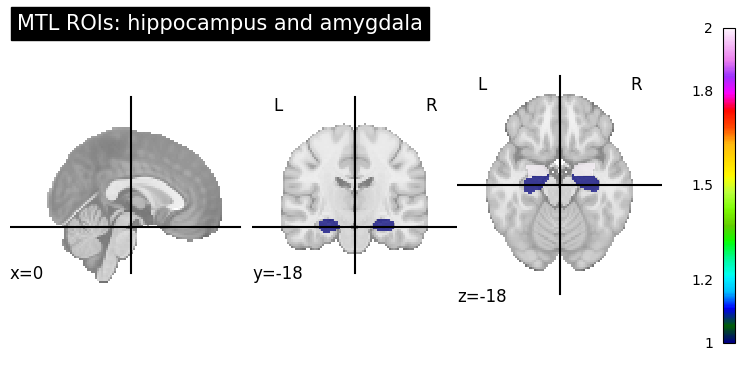

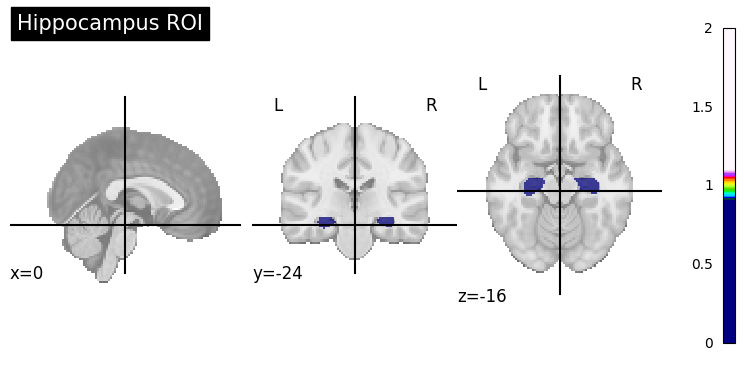

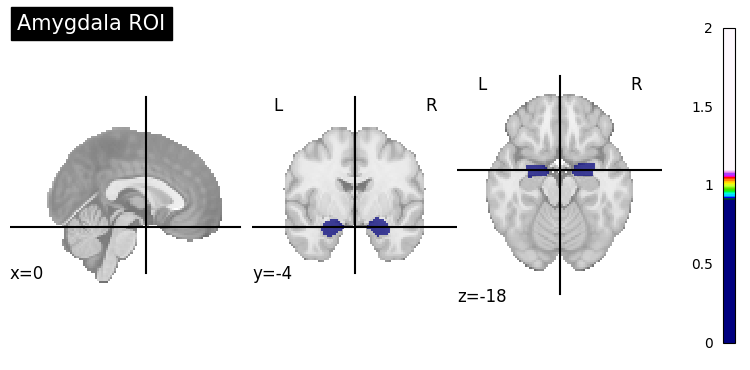

In [11]:
# --------------------------------------------------
# Plot hippocampus and amygdala masks
# --------------------------------------------------

combined_mtl_mask = image.math_img(
    "hipp + 2 * amyg",
    hipp=hippocampus_mask,
    amyg=amygdala_mask,
)

plotting.plot_roi(
    combined_mtl_mask,
    title="MTL ROIs: hippocampus and amygdala",
    display_mode="ortho",
    cut_coords=[0, -18, -18],
)
plt.show()

plotting.plot_roi(
    hippocampus_mask,
    title="Hippocampus ROI",
    display_mode="ortho",
    cut_coords=[0, -24, -16],
)
plt.show()

plotting.plot_roi(
    amygdala_mask,
    title="Amygdala ROI",
    display_mode="ortho",
    cut_coords=[0, -4, -18],
)
plt.show()

In [12]:
def run_subject_spatial_precision_glm(
    sub,
    smooth_fwhm=5.0,
    fmriprep_dir=FMRIPREP_DIR,
    events_dir=EVENTS_OUT_DIR,
):
    ses = "ses-05"
    
    bold_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*space-MNI152NLin2009cAsym*desc-preproc_bold.nii.gz"
        )
    )
    
    confound_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*desc-confounds_timeseries.tsv"
        )
    )
    
    events_path = events_dir / f"{sub}_{ses}_task-viewing_run-01_events_spatial_precision.tsv"
    
    if len(bold_candidates) == 0 or len(confound_candidates) == 0 or not events_path.exists():
        print("Missing files for", sub)
        return None
    
    bold_path = bold_candidates[0]
    confounds_path = confound_candidates[0]
    
    bold_img = nib.load(str(bold_path))
    events = pd.read_csv(events_path, sep="\t")
    confounds = pd.read_csv(confounds_path, sep="\t")
    
    print("\n" + "="*70)
    print(sub)
    print("="*70)
    print("BOLD:", bold_img.shape)
    print(events["trial_type"].value_counts())
    
    confound_cols = [
        "trans_x", "trans_y", "trans_z",
        "rot_x", "rot_y", "rot_z",
        "global_signal", "csf", "white_matter",
    ]
    
    available_confound_cols = [c for c in confound_cols if c in confounds.columns]
    selected_confounds = confounds[available_confound_cols].copy()
    selected_confounds = selected_confounds.replace([np.inf, -np.inf], np.nan)
    selected_confounds = selected_confounds.fillna(0)
    
    gm_mask = datasets.load_mni152_gm_mask(threshold=0.2)
    gm_mask_resampled = image.resample_to_img(
        gm_mask,
        bold_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    fmri_glm = FirstLevelModel(
        t_r=1.0,
        slice_time_ref=0.5,
        hrf_model="spm + derivative + dispersion",
        drift_model="cosine",
        high_pass=0.01,
        mask_img=gm_mask_resampled,
        smoothing_fwhm=smooth_fwhm,
        standardize=False,
        signal_scaling=0,
        noise_model="ar1",
        minimize_memory=False,
        n_jobs=-1,
    )
    
    fmri_glm = fmri_glm.fit(
        run_imgs=bold_img,
        events=events,
        confounds=selected_confounds,
    )
    
    design_matrix = fmri_glm.design_matrices_[0]
    
    print("Spatial precision regressors:")
    print([c for c in design_matrix.columns if "spatial_precision" in c])
    
    contrast_vec = np.zeros(len(design_matrix.columns))
    
    if "high_spatial_precision" in design_matrix.columns:
        contrast_vec[design_matrix.columns.get_loc("high_spatial_precision")] = 1.0
    else:
        print("Missing high_spatial_precision regressor.")
        return None
    
    if "low_spatial_precision" in design_matrix.columns:
        contrast_vec[design_matrix.columns.get_loc("low_spatial_precision")] = -1.0
    else:
        print("Missing low_spatial_precision regressor.")
        return None
    
    z_map = fmri_glm.compute_contrast(
        contrast_vec,
        output_type="z_score",
    )
    
    effect_map = fmri_glm.compute_contrast(
        contrast_vec,
        output_type="effect_size",
    )
    
    return {
        "sub": sub,
        "glm": fmri_glm,
        "z_map": z_map,
        "effect_map": effect_map,
        "design_matrix": design_matrix,
    }

In [13]:
spatial_glm_p10 = run_subject_spatial_precision_glm("sub-P10")


sub-P10
BOLD: (62, 77, 66, 1994)
trial_type
other                     312
high_spatial_precision     36
low_spatial_precision      36
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']


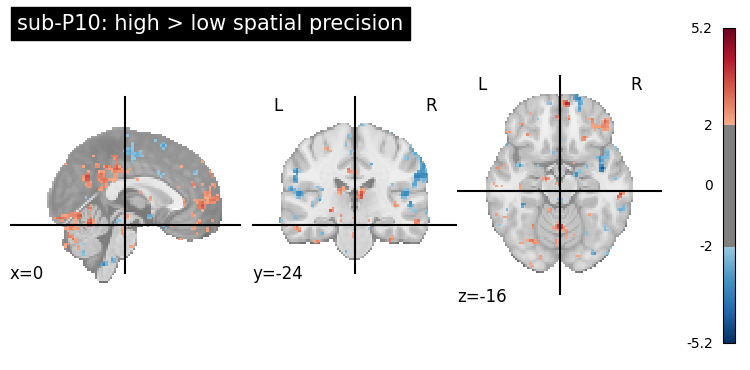

In [14]:
plotting.plot_stat_map(
    spatial_glm_p10["z_map"],
    threshold=2.0,
    display_mode="ortho",
    cut_coords=[0, -24, -16],
    title="sub-P10: high > low spatial precision",
)
plt.show()

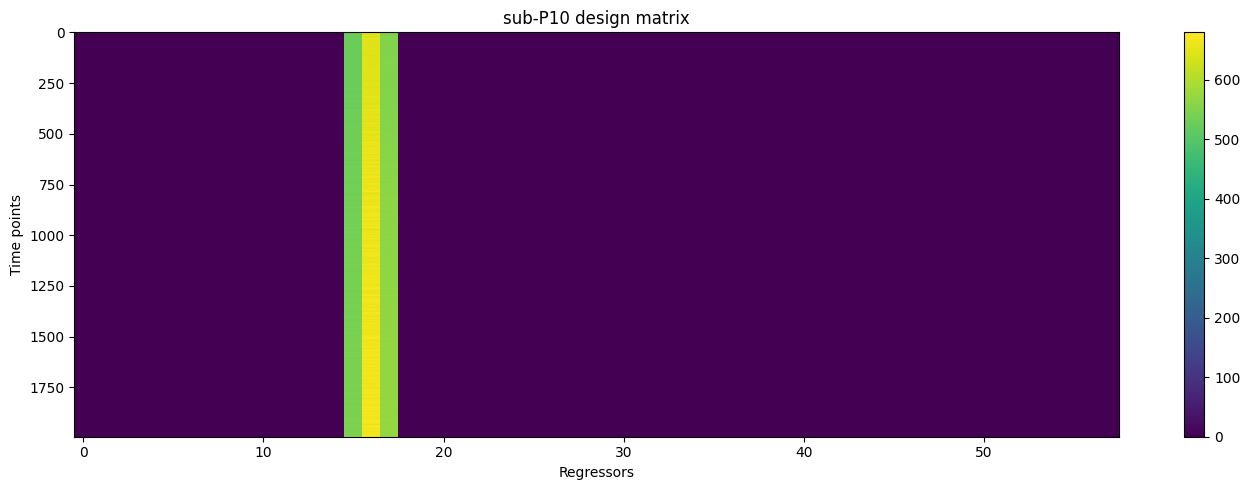

['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion', 'other', 'other_derivative', 'other_dispersion', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'global_signal', 'csf', 'white_matter', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'drift_7', 'drift_8', 'drift_9', 'drift_10', 'drift_11', 'drift_12', 'drift_13', 'drift_14', 'drift_15', 'drift_16', 'drift_17', 'drift_18', 'drift_19', 'drift_20', 'drift_21', 'drift_22', 'drift_23', 'drift_24', 'drift_25', 'drift_26', 'drift_27', 'drift_28', 'drift_29', 'drift_30', 'drift_31', 'drift_32', 'drift_33', 'drift_34', 'drift_35', 'drift_36', 'drift_37', 'drift_38', 'drift_39', 'constant']


In [15]:
plt.figure(figsize=(14, 5))
plt.imshow(spatial_glm_p10["design_matrix"], aspect="auto", interpolation="nearest")
plt.colorbar()
plt.title("sub-P10 design matrix")
plt.xlabel("Regressors")
plt.ylabel("Time points")
plt.tight_layout()
plt.show()

print(spatial_glm_p10["design_matrix"].columns.tolist())

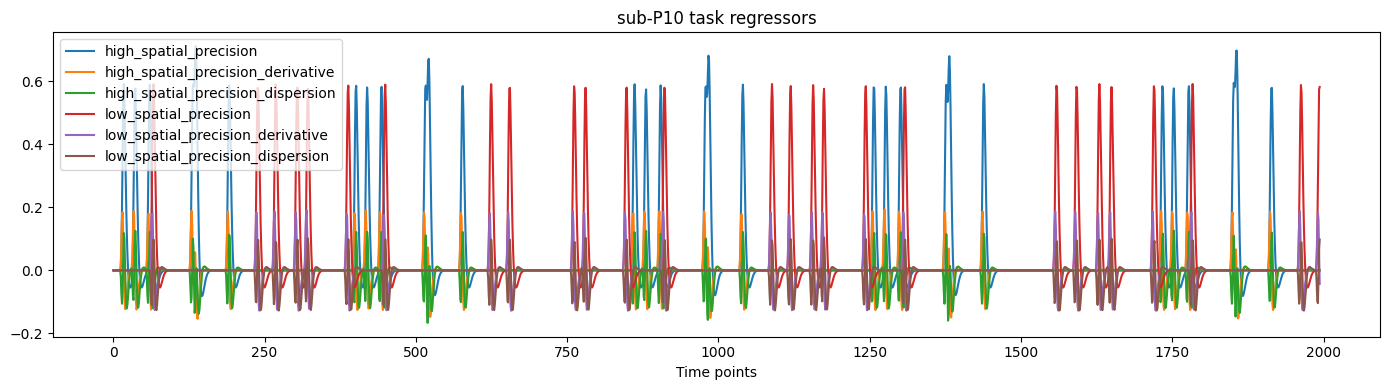

In [16]:
dm = spatial_glm_p10["design_matrix"]

task_cols = [
    "high_spatial_precision",
    "high_spatial_precision_derivative",
    "high_spatial_precision_dispersion",
    "low_spatial_precision",
    "low_spatial_precision_derivative",
    "low_spatial_precision_dispersion",
]

dm[task_cols].plot(figsize=(14, 4))
plt.title("sub-P10 task regressors")
plt.xlabel("Time points")
plt.tight_layout()
plt.show()

In [17]:
spatial_subject_results = []
spatial_subject_maps = []

for sub in sorted(item_memory["sub"].unique()):
    res = run_subject_spatial_precision_glm(sub)
    
    if res is None:
        continue
    
    sub_dir = OUT_DIR / sub
    sub_dir.mkdir(parents=True, exist_ok=True)
    
    z_path = sub_dir / f"{sub}_post_high_vs_low_spatial_precision_z.nii.gz"
    effect_path = sub_dir / f"{sub}_post_high_vs_low_spatial_precision_effect.nii.gz"
    
    res["z_map"].to_filename(z_path)
    res["effect_map"].to_filename(effect_path)
    
    spatial_subject_results.append(res)
    spatial_subject_maps.append(effect_path)

print("Saved subject effect maps:", len(spatial_subject_maps))
print("Subjects:")
print([r["sub"] for r in spatial_subject_results])


sub-P10
BOLD: (62, 77, 66, 1994)
trial_type
other                     312
high_spatial_precision     36
low_spatial_precision      36
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P12
BOLD: (62, 77, 66, 1954)
trial_type
other                     312
high_spatial_precision     36
low_spatial_precision      36
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P13
BOLD: (62, 77, 66, 1957)
trial_type
other                     258
high_spatial_precision     66
low_spatial_precision      60
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'hig

/tmp/ipykernel_2877896/145117486.py:75: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P34
BOLD: (62, 77, 66, 1649)
trial_type
other                     300
low_spatial_precision      42
high_spatial_precision     42
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P35
BOLD: (62, 77, 66, 1886)
trial_type
other                     264
high_spatial_precision     60
low_spatial_precision      60
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispers

/tmp/ipykernel_2877896/145117486.py:75: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P44
BOLD: (62, 77, 66, 1668)
trial_type
other                     246
high_spatial_precision     72
low_spatial_precision      66
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P45
BOLD: (62, 77, 66, 1658)
trial_type
other                     246
high_spatial_precision     72
low_spatial_precision      66
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispers

In [18]:
# --------------------------------------------------
# Group-level GLM
# --------------------------------------------------

spatial_subject_maps = sorted(
    OUT_DIR.glob("sub-*/*_post_high_vs_low_spatial_precision_effect.nii.gz")
)

print("N maps:", len(spatial_subject_maps))

design_matrix_group = pd.DataFrame(
    np.ones(len(spatial_subject_maps)),
    columns=["intercept"],
)

second_level_model = SecondLevelModel(
    smoothing_fwhm=None,
    n_jobs=-1,
)

second_level_model = second_level_model.fit(
    spatial_subject_maps,
    design_matrix=design_matrix_group,
)

group_z_spatial = second_level_model.compute_contrast(
    "intercept",
    output_type="z_score",
)

group_z_path = OUT_DIR / "group_post_high_vs_low_spatial_precision_z.nii.gz"
group_z_spatial.to_filename(group_z_path)

print("Saved:", group_z_path)

N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_precision_post_viewing/group_post_high_vs_low_spatial_precision_z.nii.gz


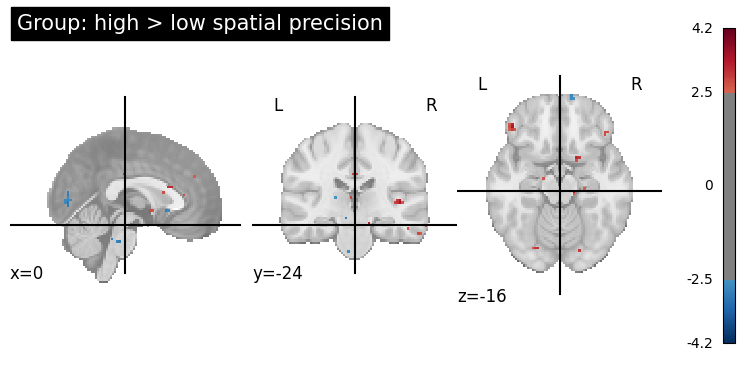

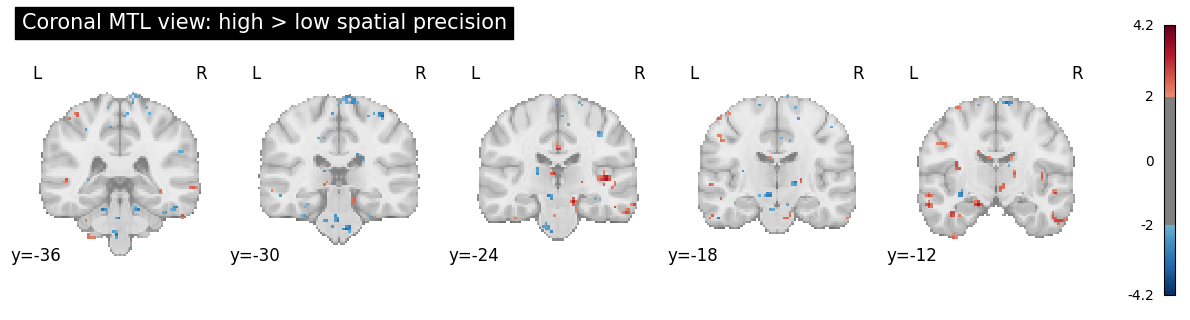

In [19]:
# --------------------------------------------------
# Plot group map
# --------------------------------------------------

plotting.plot_stat_map(
    group_z_spatial,
    threshold=2.5,
    display_mode="ortho",
    cut_coords=[0, -24, -16],
    title="Group: high > low spatial precision",
)
plt.show()

plotting.plot_stat_map(
    group_z_spatial,
    threshold=2.0,
    display_mode="y",
    cut_coords=[-36, -30, -24, -18, -12],
    title="Coronal MTL view: high > low spatial precision",
)
plt.show()

In [20]:
# --------------------------------------------------
# Cluster tables
# --------------------------------------------------

clusters_spatial = get_clusters_table(
    group_z_spatial,
    stat_threshold=2.5,
    cluster_threshold=5,
)

display(clusters_spatial)

clusters_spatial_liberal = get_clusters_table(
    group_z_spatial,
    stat_threshold=2.0,
    cluster_threshold=5,
)

display(clusters_spatial_liberal)

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,21.5,-2.0,-38.0,3.896367,453
1,2,-26.0,-7.0,-28.0,3.642300,187
2,3,41.5,-27.0,7.0,3.566474,171
3,4,54.0,-4.5,-10.5,3.502053,296
4,5,-16.0,-12.0,-18.0,3.399723,93
5,6,-46.0,38.0,-15.5,3.382704,281
6,7,59.0,-4.5,-28.0,3.339106,109
7,8,56.5,-9.5,-33.0,3.299669,390
8,8a,46.5,-4.5,-33.0,3.274616,
9,9,-51.0,-4.5,-30.5,3.208514,109


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,21.5,-2.0,-38.0,3.896367,1046
1,2,-26.0,-7.0,-28.0,3.642300,406
2,3,41.5,-27.0,7.0,3.566474,500
3,3a,41.5,-19.5,-3.0,2.249578,
4,4,54.0,-4.5,-10.5,3.502053,546
...,...,...,...,...,...,...
81,70,26.5,0.5,54.5,2.356453,78
82,71,-53.5,-4.5,-15.5,2.356449,203
83,72,41.5,43.0,-18.0,2.335879,93
84,73,-48.5,-12.0,37.0,2.327309,203


In [22]:
# --------------------------------------------------
# Atlas labeling for spatial precision clusters
# --------------------------------------------------

from nilearn.datasets import fetch_atlas_harvard_oxford

def label_peak_with_atlas(x, y, z, atlas_img, atlas_labels):
    coords = np.array([[x, y, z]])
    ijk = np.round(
        nib.affines.apply_affine(np.linalg.inv(atlas_img.affine), coords)
    ).astype(int)[0]
    
    data = atlas_img.get_fdata()
    
    if np.any(ijk < 0) or np.any(ijk >= data.shape):
        return "Outside atlas"
    
    idx = int(data[tuple(ijk)])
    
    if idx < len(atlas_labels):
        return atlas_labels[idx]
    else:
        return f"Unknown index {idx}"

# Use already loaded atlases from previous cells
clusters_to_label = clusters_spatial.copy()

labels_sub = []
labels_cort = []

for _, row in clusters_to_label.iterrows():
    if isinstance(row["Cluster ID"], str) and row["Cluster ID"].endswith(("a", "b", "c")):
        pass
    
    x, y, z = row["X"], row["Y"], row["Z"]
    
    labels_sub.append(
        label_peak_with_atlas(x, y, z, subcort_img, subcort_labels)
    )
    
    labels_cort.append(
        label_peak_with_atlas(x, y, z, cort_img, cort_labels)
    )

clusters_to_label["subcortical_label"] = labels_sub
clusters_to_label["cortical_label"] = labels_cort

display(clusters_to_label)

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),subcortical_label,cortical_label
0,1,21.5,-2.0,-38.0,3.896367,453,Right Cerebral Cortex,"Parahippocampal Gyrus, anterior division"
1,2,-26.0,-7.0,-28.0,3.642300,187,Left Hippocampus,Background
2,3,41.5,-27.0,7.0,3.566474,171,Right Cerebral White Matter,Background
3,4,54.0,-4.5,-10.5,3.502053,296,Right Cerebral Cortex,"Superior Temporal Gyrus, anterior division"
4,5,-16.0,-12.0,-18.0,3.399723,93,Left Hippocampus,Background
5,6,-46.0,38.0,-15.5,3.382704,281,Left Cerebral Cortex,Frontal Pole
6,7,59.0,-4.5,-28.0,3.339106,109,Right Cerebral Cortex,"Middle Temporal Gyrus, anterior division"
7,8,56.5,-9.5,-33.0,3.299669,390,Right Cerebral Cortex,"Inferior Temporal Gyrus, posterior division"
8,8a,46.5,-4.5,-33.0,3.274616,,Right Cerebral White Matter,Background
9,9,-51.0,-4.5,-30.5,3.208514,109,Left Cerebral Cortex,"Middle Temporal Gyrus, anterior division"


In [23]:
roi_effect_rows = []

for effect_path in spatial_subject_maps:
    sub = effect_path.parts[-2]
    effect_img = nib.load(str(effect_path))
    
    for roi_name, roi_mask in roi_dict.items():
        roi_mask_resampled = image.resample_to_img(
            roi_mask,
            effect_img,
            interpolation="nearest",
            force_resample=True,
            copy_header=True,
        )
        
        masker = NiftiMasker(mask_img=roi_mask_resampled, standardize=False)
        values = masker.fit_transform(effect_img).ravel()
        
        roi_effect_rows.append({
            "sub": sub,
            "roi": roi_name,
            "mean_effect": np.nanmean(values),
        })

roi_effect_df = pd.DataFrame(roi_effect_rows)

roi_stats_rows = []

for roi, df in roi_effect_df.groupby("roi"):
    values = df["mean_effect"].dropna()
    
    t_res = ttest_1samp(values, 0)
    w_res = wilcoxon(values)
    
    roi_stats_rows.append({
        "roi": roi,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_res.pvalue,
    })

roi_stats_df = pd.DataFrame(roi_stats_rows).sort_values("p")
display(roi_stats_df)

/tmp/ipykernel_2877896/2971415635.py:17: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykernel_2877896/2971415635.py:17: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykernel_2877896/2971415635.py:17: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykernel_2877896/2971415635.py:17: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykern

,roi,n,mean_effect,std,t,p,wilcoxon_p
2,parahippocampal,20,0.032780,0.072709,2.016184,0.058142,0.044054
0,amygdala,20,0.021561,0.107598,0.896136,0.381394,0.311794
1,hippocampus,20,0.014500,0.076797,0.844406,0.408949,0.498009
3,visual_ventral,20,-0.001122,0.060758,-0.082560,0.935065,0.956329


In [24]:
clusters_to_label.to_csv(
    OUT_DIR / "group_post_high_vs_low_spatial_precision_clusters_labeled_z25.csv",
    index=False,
)

roi_effect_df.to_csv(
    OUT_DIR / "post_high_vs_low_spatial_precision_roi_effects.csv",
    index=False,
)

roi_stats_df.to_csv(
    OUT_DIR / "post_high_vs_low_spatial_precision_roi_stats.csv",
    index=False,
)

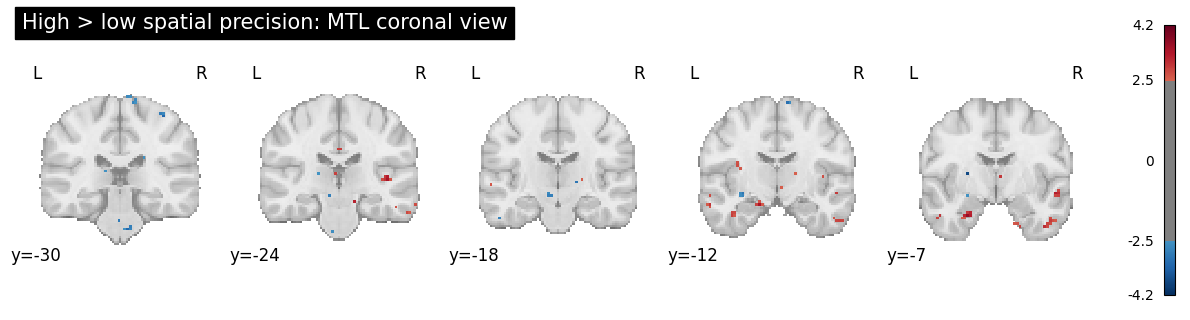

In [25]:
# --------------------------------------------------
# MTL-focused figure: high > low spatial precision
# with hippocampus/parahippocampal ROI context
# --------------------------------------------------

plotting.plot_stat_map(
    group_z_spatial,
    threshold=2.5,
    display_mode="y",
    cut_coords=[-30, -24, -18, -12, -7],
    title="High > low spatial precision: MTL coronal view",
    colorbar=True,
)
plt.show()

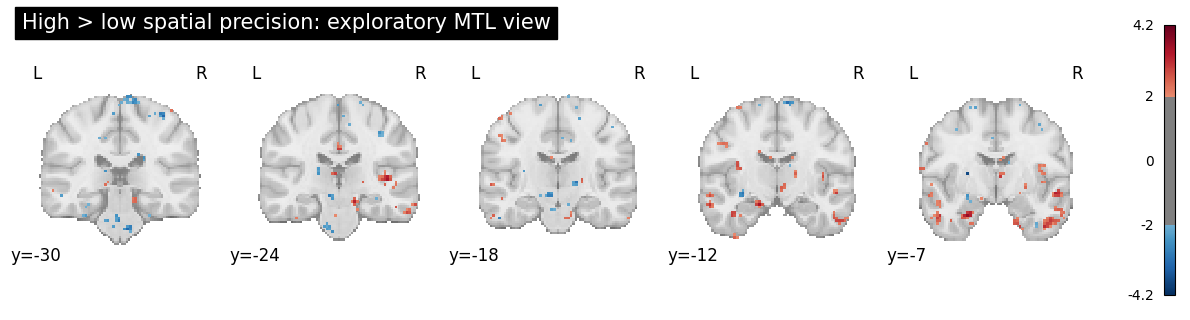

In [26]:
plotting.plot_stat_map(
    group_z_spatial,
    threshold=2.0,
    display_mode="y",
    cut_coords=[-30, -24, -18, -12, -7],
    title="High > low spatial precision: exploratory MTL view",
    colorbar=True,
)
plt.show()

In [27]:
display = plotting.plot_stat_map(
    group_z_spatial,
    threshold=2.5,
    display_mode="y",
    cut_coords=[-30, -24, -18, -12, -7],
    title="High > low spatial precision: MTL coronal view",
    colorbar=True,
)

fig_path = OUT_DIR / "group_high_vs_low_spatial_precision_MTL_coronal_z25.png"
display.savefig(fig_path, dpi=300)
display.close()

print("Saved:", fig_path)

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_precision_post_viewing/group_high_vs_low_spatial_precision_MTL_coronal_z25.png


In [30]:
from nilearn.maskers import NiftiSpheresMasker
# Restore notebook display function
from IPython.display import display

peak_coords = {
    "right_anterior_parahippocampal_peak": [21.5, -2.0, -38.0],
    "left_hippocampus_peak_1": [-26.0, -7.0, -28.0],
    "left_hippocampus_peak_2": [-16.0, -12.0, -18.0],
}

sphere_rows = []

for effect_path in spatial_subject_maps:
    sub = effect_path.parts[-2]
    effect_img = nib.load(str(effect_path))
    
    for peak_name, coord in peak_coords.items():
        masker = NiftiSpheresMasker(
            seeds=[coord],
            radius=5,
            standardize=False,
        )
        
        value = masker.fit_transform(effect_img).ravel()[0]
        
        sphere_rows.append({
            "sub": sub,
            "peak": peak_name,
            "mean_effect": value,
        })

sphere_effect_df = pd.DataFrame(sphere_rows)

display(sphere_effect_df.head())

,sub,peak,mean_effect
0,sub-P10,right_anterior_parahippocampal_peak,0.585986
1,sub-P10,left_hippocampus_peak_1,0.082678
2,sub-P10,left_hippocampus_peak_2,0.293152
3,sub-P12,right_anterior_parahippocampal_peak,-0.104367
4,sub-P12,left_hippocampus_peak_1,-0.061784


In [31]:
sphere_stats_rows = []

for peak, df in sphere_effect_df.groupby("peak"):
    values = df["mean_effect"].dropna()
    
    t_res = ttest_1samp(values, 0)
    w_res = wilcoxon(values)
    
    sphere_stats_rows.append({
        "peak": peak,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_res.pvalue,
    })

sphere_stats_df = pd.DataFrame(sphere_stats_rows).sort_values("p")
display(sphere_stats_df)

,peak,n,mean_effect,std,t,p,wilcoxon_p
2,right_anterior_parahippocampal_peak,20,0.210118,0.182182,5.157898,0.000056,0.000168
0,left_hippocampus_peak_1,20,0.096055,0.102413,4.194482,0.000491,0.000586
1,left_hippocampus_peak_2,20,0.108918,0.158615,3.070929,0.006289,0.006390


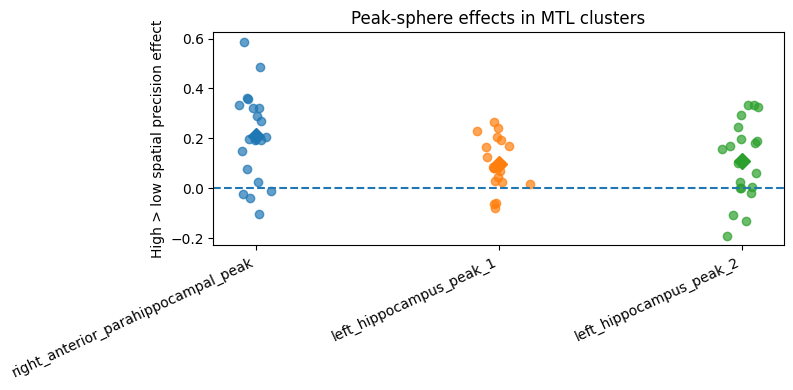

In [32]:
plt.figure(figsize=(8, 4))

peaks = sphere_stats_df["peak"].tolist()

for i, peak in enumerate(peaks):
    vals = sphere_effect_df.query("peak == @peak")["mean_effect"].dropna().values
    x = np.repeat(i, len(vals)) + np.random.normal(0, 0.04, len(vals))
    
    plt.scatter(x, vals, alpha=0.7)
    plt.plot(i, vals.mean(), marker="D", markersize=8)

plt.axhline(0, linestyle="--")
plt.xticks(range(len(peaks)), peaks, rotation=25, ha="right")
plt.ylabel("High > low spatial precision effect")
plt.title("Peak-sphere effects in MTL clusters")
plt.tight_layout()
plt.show()

In [33]:
mtl_clusters.to_csv(
    OUT_DIR / "group_post_high_vs_low_spatial_precision_MTL_clusters.csv",
    index=False,
)

sphere_effect_df.to_csv(
    OUT_DIR / "post_high_vs_low_spatial_precision_peak_sphere_effects.csv",
    index=False,
)

sphere_stats_df.to_csv(
    OUT_DIR / "post_high_vs_low_spatial_precision_peak_sphere_stats.csv",
    index=False,
)

In [34]:
# --------------------------------------------------
# Locate possible behavioral / memory files
# --------------------------------------------------

candidate_files = []

search_roots = [
    PROJECT_ROOT / "data",
    PROJECT_ROOT / "notebooks",
]

patterns = [
    "*memory*.csv",
    "*memory*.tsv",
    "*behav*.csv",
    "*behav*.tsv",
    "*response*.csv",
    "*response*.tsv",
    "*label*.csv",
    "*label*.tsv",
]

for root in search_roots:
    for pattern in patterns:
        candidate_files.extend(root.rglob(pattern))

candidate_files = sorted(set(candidate_files))

print("Candidate files:", len(candidate_files))

for p in candidate_files:
    print(p.relative_to(PROJECT_ROOT))

Candidate files: 46
data/preprocessed/irrelevant_old_memory_labels.csv
data/preprocessed/irrelevant_seen_old_memory_labels.csv
data/preprocessed/irrelevant_seen_old_memory_labels_clean_fmri.csv
data/preprocessed/irrelevant_seen_old_memory_labels_valid_subjects.csv
data/preprocessed/relabeled_events/sub-P10_ses-01_task-viewing_run-01_events_memory_labels.tsv
data/preprocessed/relabeled_events/sub-P10_ses-05_task-viewing_run-01_events_memory_labels.tsv
data/preprocessed/relabeled_events/sub-P12_ses-01_task-viewing_run-01_events_memory_labels.tsv
data/preprocessed/relabeled_events/sub-P12_ses-05_task-viewing_run-01_events_memory_labels.tsv
data/preprocessed/relabeled_events/sub-P13_ses-01_task-viewing_run-01_events_memory_labels.tsv
data/preprocessed/relabeled_events/sub-P13_ses-05_task-viewing_run-01_events_memory_labels.tsv
data/preprocessed/relabeled_events/sub-P14_ses-01_task-viewing_run-01_events_memory_labels.tsv
data/preprocessed/relabeled_events/sub-P14_ses-05_task-viewing_run-01_

In [35]:
# --------------------------------------------------
# Inspect candidate files for columns related to memory/spatial placement
# --------------------------------------------------

interesting_files = []

keywords = [
    "placement_distance",
    "placement_confidence",
    "temporal_confidence",
    "recognition_response",
    "recognized_seen",
    "encoding_session",
    "is_relevant",
    "relevance",
    "event_filename",
    "stimulus",
]

for p in candidate_files:
    try:
        if p.suffix == ".csv":
            df_tmp = pd.read_csv(p, nrows=5)
        elif p.suffix == ".tsv":
            df_tmp = pd.read_csv(p, sep="\t", nrows=5)
        else:
            continue
        
        cols = df_tmp.columns.tolist()
        matched = [c for c in cols if c in keywords]
        
        if len(matched) > 0:
            interesting_files.append(p)
            print("\n" + "="*80)
            print(p.relative_to(PROJECT_ROOT))
            print("Matched columns:", matched)
            print("All columns:", cols)
            display(df_tmp.head())
            
    except Exception as e:
        pass

print("\nInteresting files:", len(interesting_files))


data/preprocessed/irrelevant_old_memory_labels.csv
Matched columns: ['stimulus', 'event_filename', 'encoding_session', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'placement_distance', 'placement_confidence', 'temporal_confidence']
All columns: ['sub', 'participant_id', 'stimulus', 'event_filename', 'version', 'stim_cat', 'encoding_session', 'checkpoint', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label', 'placement_distance', 'placement_confidence', 'temporal_confidence']


,sub,participant_id,stimulus,event_filename,version,stim_cat,encoding_session,checkpoint,relevance,is_relevant,...,recognized_seen,temporal_response,expected_temporal_response,schema_predicted_temporal_response,true_temporal_correct,followed_schema_response,memory_label,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,10,food_2_e1_11_nr_o_v1_old,food_2_e1_11_nr_o_v1_old.jpg,v1,food,e1,11,nr,False,...,True,two_weeks,two_weeks,yesterday,True,False,true_week,222.283100,23,37
1,sub-P10,10,pirate_2_e3_11_nr_h_v1_old,pirate_2_e3_11_nr_h_v1_old.jpg,v1,pirate,e3,11,nr,False,...,False,never,yesterday,one_week,False,False,forgotten,754.491100,78,78
2,sub-P10,10,viking_8_e3_16_nr_h_v1_old,viking_8_e3_16_nr_h_v1_old.jpg,v1,viking,e3,16,nr,False,...,False,never,yesterday,two_weeks,False,False,forgotten,745.093800,32,21
3,sub-P10,10,pirate_7_e3_1_nr_h_v1_old,pirate_7_e3_1_nr_h_v1_old.jpg,v1,pirate,e3,1,nr,False,...,True,two_weeks,yesterday,one_week,False,False,other_wrong_week,0.952219,78,82
4,sub-P10,10,pirate_5_e1_7_nr_h_v1_old,pirate_5_e1_7_nr_h_v1_old.jpg,v1,pirate,e1,7,nr,False,...,True,one_week,two_weeks,one_week,False,True,schema_week,348.247200,18,35



data/preprocessed/irrelevant_seen_old_memory_labels.csv
Matched columns: ['stimulus', 'event_filename', 'encoding_session', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'placement_distance', 'placement_confidence', 'temporal_confidence']
All columns: ['sub', 'participant_id', 'stimulus', 'event_filename', 'version', 'stim_cat', 'encoding_session', 'checkpoint', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label', 'placement_distance', 'placement_confidence', 'temporal_confidence']


,sub,participant_id,stimulus,event_filename,version,stim_cat,encoding_session,checkpoint,relevance,is_relevant,...,recognized_seen,temporal_response,expected_temporal_response,schema_predicted_temporal_response,true_temporal_correct,followed_schema_response,memory_label,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,10,food_2_e1_11_nr_o_v1_old,food_2_e1_11_nr_o_v1_old.jpg,v1,food,e1,11,nr,False,...,True,two_weeks,two_weeks,yesterday,True,False,true_week,222.283100,23,37
1,sub-P10,10,pirate_7_e3_1_nr_h_v1_old,pirate_7_e3_1_nr_h_v1_old.jpg,v1,pirate,e3,1,nr,False,...,True,two_weeks,yesterday,one_week,False,False,other_wrong_week,0.952219,78,82
2,sub-P10,10,pirate_5_e1_7_nr_h_v1_old,pirate_5_e1_7_nr_h_v1_old.jpg,v1,pirate,e1,7,nr,False,...,True,one_week,two_weeks,one_week,False,True,schema_week,348.247200,18,35
3,sub-P10,10,wealth_7_e1_12_nr_o_v1_old,wealth_7_e1_12_nr_o_v1_old.jpg,v1,wealth,e1,12,nr,False,...,True,yesterday,two_weeks,one_week,False,False,other_wrong_week,822.677200,35,53
4,sub-P10,10,viking_3_e2_1_nr_h_v1_old,viking_3_e2_1_nr_h_v1_old.jpg,v1,viking,e2,1,nr,False,...,True,two_weeks,one_week,two_weeks,False,True,schema_week,112.915500,34,18



data/preprocessed/irrelevant_seen_old_memory_labels_clean_fmri.csv
Matched columns: ['stimulus', 'event_filename', 'encoding_session', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'placement_distance', 'placement_confidence', 'temporal_confidence']
All columns: ['sub', 'participant_id', 'stimulus', 'event_filename', 'version', 'stim_cat', 'encoding_session', 'checkpoint', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label', 'placement_distance', 'placement_confidence', 'temporal_confidence']


,sub,participant_id,stimulus,event_filename,version,stim_cat,encoding_session,checkpoint,relevance,is_relevant,...,recognized_seen,temporal_response,expected_temporal_response,schema_predicted_temporal_response,true_temporal_correct,followed_schema_response,memory_label,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,10,food_2_e1_11_nr_o_v1_old,food_2_e1_11_nr_o_v1_old.jpg,v1,food,e1,11,nr,False,...,True,two_weeks,two_weeks,yesterday,True,False,true_week,222.283100,23,37
1,sub-P10,10,pirate_7_e3_1_nr_h_v1_old,pirate_7_e3_1_nr_h_v1_old.jpg,v1,pirate,e3,1,nr,False,...,True,two_weeks,yesterday,one_week,False,False,other_wrong_week,0.952219,78,82
2,sub-P10,10,pirate_5_e1_7_nr_h_v1_old,pirate_5_e1_7_nr_h_v1_old.jpg,v1,pirate,e1,7,nr,False,...,True,one_week,two_weeks,one_week,False,True,schema_week,348.247200,18,35
3,sub-P10,10,wealth_7_e1_12_nr_o_v1_old,wealth_7_e1_12_nr_o_v1_old.jpg,v1,wealth,e1,12,nr,False,...,True,yesterday,two_weeks,one_week,False,False,other_wrong_week,822.677200,35,53
4,sub-P10,10,viking_3_e2_1_nr_h_v1_old,viking_3_e2_1_nr_h_v1_old.jpg,v1,viking,e2,1,nr,False,...,True,two_weeks,one_week,two_weeks,False,True,schema_week,112.915500,34,18



data/preprocessed/irrelevant_seen_old_memory_labels_valid_subjects.csv
Matched columns: ['stimulus', 'event_filename', 'encoding_session', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'placement_distance', 'placement_confidence', 'temporal_confidence']
All columns: ['sub', 'participant_id', 'stimulus', 'event_filename', 'version', 'stim_cat', 'encoding_session', 'checkpoint', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label', 'placement_distance', 'placement_confidence', 'temporal_confidence']


,sub,participant_id,stimulus,event_filename,version,stim_cat,encoding_session,checkpoint,relevance,is_relevant,...,recognized_seen,temporal_response,expected_temporal_response,schema_predicted_temporal_response,true_temporal_correct,followed_schema_response,memory_label,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,10,food_2_e1_11_nr_o_v1_old,food_2_e1_11_nr_o_v1_old.jpg,v1,food,e1,11,nr,False,...,True,two_weeks,two_weeks,yesterday,True,False,true_week,222.283100,23,37
1,sub-P10,10,pirate_7_e3_1_nr_h_v1_old,pirate_7_e3_1_nr_h_v1_old.jpg,v1,pirate,e3,1,nr,False,...,True,two_weeks,yesterday,one_week,False,False,other_wrong_week,0.952219,78,82
2,sub-P10,10,pirate_5_e1_7_nr_h_v1_old,pirate_5_e1_7_nr_h_v1_old.jpg,v1,pirate,e1,7,nr,False,...,True,one_week,two_weeks,one_week,False,True,schema_week,348.247200,18,35
3,sub-P10,10,wealth_7_e1_12_nr_o_v1_old,wealth_7_e1_12_nr_o_v1_old.jpg,v1,wealth,e1,12,nr,False,...,True,yesterday,two_weeks,one_week,False,False,other_wrong_week,822.677200,35,53
4,sub-P10,10,viking_3_e2_1_nr_h_v1_old,viking_3_e2_1_nr_h_v1_old.jpg,v1,viking,e2,1,nr,False,...,True,two_weeks,one_week,two_weeks,False,True,schema_week,112.915500,34,18



Interesting files: 4


In [36]:
# --------------------------------------------------
# Search full project for files containing placement/confidence variables
# --------------------------------------------------

import subprocess
from pathlib import Path

search_terms = [
    "placement_distance",
    "placement_confidence",
    "temporal_confidence",
    "recognition_response",
    "recognized_seen",
]

for term in search_terms:
    print("\n" + "="*80)
    print("Searching for:", term)
    print("="*80)
    
    cmd = [
        "grep",
        "-R",
        "-n",
        "--exclude-dir=.git",
        "--exclude-dir=__pycache__",
        "--exclude=*.nii",
        "--exclude=*.nii.gz",
        term,
        str(PROJECT_ROOT),
    ]
    
    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=60,
        )
        
        lines = result.stdout.splitlines()
        print("Matches:", len(lines))
        
        for line in lines[:50]:
            print(line)
            
        if len(lines) > 50:
            print("... truncated")
            
    except Exception as e:
        print("Error:", e)


Searching for: placement_distance
Error: Command '['grep', '-R', '-n', '--exclude-dir=.git', '--exclude-dir=__pycache__', '--exclude=*.nii', '--exclude=*.nii.gz', 'placement_distance', '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project']' timed out after 60 seconds

Searching for: placement_confidence
Error: Command '['grep', '-R', '-n', '--exclude-dir=.git', '--exclude-dir=__pycache__', '--exclude=*.nii', '--exclude=*.nii.gz', 'placement_confidence', '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project']' timed out after 60 seconds

Searching for: temporal_confidence
Error: Command '['grep', '-R', '-n', '--exclude-dir=.git', '--exclude-dir=__pycache__', '--exclude=*.nii', '--exclude=*.nii.gz', 'temporal_confidence', '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project']' timed out after 60 seconds

Searching for: recognition_response
Error: Command '['grep', '-R', '-n', '--exclude-dir=.git', '--exclude-dir=__pycache__', '--exclude=*.nii', '

In [37]:
# --------------------------------------------------
# Inspect all tabular files under data/
# --------------------------------------------------

all_tabular_files = []

for ext in ["*.csv", "*.tsv", "*.xlsx", "*.xls"]:
    all_tabular_files.extend((PROJECT_ROOT / "data").rglob(ext))

all_tabular_files = sorted(set(all_tabular_files))

print("Total tabular files:", len(all_tabular_files))

hits = []

for p in all_tabular_files:
    try:
        if p.suffix == ".csv":
            df_tmp = pd.read_csv(p, nrows=5)
        elif p.suffix == ".tsv":
            df_tmp = pd.read_csv(p, sep="\t", nrows=5)
        elif p.suffix in [".xlsx", ".xls"]:
            df_tmp = pd.read_excel(p, nrows=5)
        else:
            continue
        
        cols = df_tmp.columns.astype(str).tolist()
        
        useful = [
            c for c in cols
            if any(k in c.lower() for k in [
                "placement",
                "confidence",
                "recognition",
                "temporal",
                "relevance",
                "stim",
                "memory",
                "response",
            ])
        ]
        
        if len(useful) > 0:
            hits.append(p)
            print("\n" + "="*80)
            print(p.relative_to(PROJECT_ROOT))
            print("Shape preview:", df_tmp.shape)
            print("Useful cols:", useful)
            print("All cols:", cols)
            display(df_tmp.head())
            
    except Exception as e:
        pass

print("\nFiles with useful columns:", len(hits))

Total tabular files: 99

data/preprocessed/irrelevant_old_memory_labels.csv
Shape preview: (5, 21)
Useful cols: ['stimulus', 'stim_cat', 'relevance', 'recognition_response', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label', 'placement_distance', 'placement_confidence', 'temporal_confidence']
All cols: ['sub', 'participant_id', 'stimulus', 'event_filename', 'version', 'stim_cat', 'encoding_session', 'checkpoint', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label', 'placement_distance', 'placement_confidence', 'temporal_confidence']


,sub,participant_id,stimulus,event_filename,version,stim_cat,encoding_session,checkpoint,relevance,is_relevant,...,recognized_seen,temporal_response,expected_temporal_response,schema_predicted_temporal_response,true_temporal_correct,followed_schema_response,memory_label,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,10,food_2_e1_11_nr_o_v1_old,food_2_e1_11_nr_o_v1_old.jpg,v1,food,e1,11,nr,False,...,True,two_weeks,two_weeks,yesterday,True,False,true_week,222.283100,23,37
1,sub-P10,10,pirate_2_e3_11_nr_h_v1_old,pirate_2_e3_11_nr_h_v1_old.jpg,v1,pirate,e3,11,nr,False,...,False,never,yesterday,one_week,False,False,forgotten,754.491100,78,78
2,sub-P10,10,viking_8_e3_16_nr_h_v1_old,viking_8_e3_16_nr_h_v1_old.jpg,v1,viking,e3,16,nr,False,...,False,never,yesterday,two_weeks,False,False,forgotten,745.093800,32,21
3,sub-P10,10,pirate_7_e3_1_nr_h_v1_old,pirate_7_e3_1_nr_h_v1_old.jpg,v1,pirate,e3,1,nr,False,...,True,two_weeks,yesterday,one_week,False,False,other_wrong_week,0.952219,78,82
4,sub-P10,10,pirate_5_e1_7_nr_h_v1_old,pirate_5_e1_7_nr_h_v1_old.jpg,v1,pirate,e1,7,nr,False,...,True,one_week,two_weeks,one_week,False,True,schema_week,348.247200,18,35



data/preprocessed/irrelevant_seen_old_memory_labels.csv
Shape preview: (5, 21)
Useful cols: ['stimulus', 'stim_cat', 'relevance', 'recognition_response', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label', 'placement_distance', 'placement_confidence', 'temporal_confidence']
All cols: ['sub', 'participant_id', 'stimulus', 'event_filename', 'version', 'stim_cat', 'encoding_session', 'checkpoint', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label', 'placement_distance', 'placement_confidence', 'temporal_confidence']


,sub,participant_id,stimulus,event_filename,version,stim_cat,encoding_session,checkpoint,relevance,is_relevant,...,recognized_seen,temporal_response,expected_temporal_response,schema_predicted_temporal_response,true_temporal_correct,followed_schema_response,memory_label,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,10,food_2_e1_11_nr_o_v1_old,food_2_e1_11_nr_o_v1_old.jpg,v1,food,e1,11,nr,False,...,True,two_weeks,two_weeks,yesterday,True,False,true_week,222.283100,23,37
1,sub-P10,10,pirate_7_e3_1_nr_h_v1_old,pirate_7_e3_1_nr_h_v1_old.jpg,v1,pirate,e3,1,nr,False,...,True,two_weeks,yesterday,one_week,False,False,other_wrong_week,0.952219,78,82
2,sub-P10,10,pirate_5_e1_7_nr_h_v1_old,pirate_5_e1_7_nr_h_v1_old.jpg,v1,pirate,e1,7,nr,False,...,True,one_week,two_weeks,one_week,False,True,schema_week,348.247200,18,35
3,sub-P10,10,wealth_7_e1_12_nr_o_v1_old,wealth_7_e1_12_nr_o_v1_old.jpg,v1,wealth,e1,12,nr,False,...,True,yesterday,two_weeks,one_week,False,False,other_wrong_week,822.677200,35,53
4,sub-P10,10,viking_3_e2_1_nr_h_v1_old,viking_3_e2_1_nr_h_v1_old.jpg,v1,viking,e2,1,nr,False,...,True,two_weeks,one_week,two_weeks,False,True,schema_week,112.915500,34,18



data/preprocessed/irrelevant_seen_old_memory_labels_clean_fmri.csv
Shape preview: (5, 21)
Useful cols: ['stimulus', 'stim_cat', 'relevance', 'recognition_response', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label', 'placement_distance', 'placement_confidence', 'temporal_confidence']
All cols: ['sub', 'participant_id', 'stimulus', 'event_filename', 'version', 'stim_cat', 'encoding_session', 'checkpoint', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label', 'placement_distance', 'placement_confidence', 'temporal_confidence']


...


data/processed/rsa/irrelevant_memory/encoding_post_same_item_roi_rsa_item_level.csv
Shape preview: (5, 12)
Useful cols: ['memory_label', 'stim_cat', 'placement_distance', 'placement_confidence', 'temporal_confidence']
All cols: ['sub', 'roi', 'encoding_session', 'event', 'enc_item_id', 'post_item_id', 'memory_label', 'stim_cat', 'encoding_post_similarity', 'placement_distance', 'placement_confidence', 'temporal_confidence']


,sub,roi,encoding_session,event,enc_item_id,post_item_id,memory_label,stim_cat,encoding_post_similarity,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,hippocampus,e1,food_2_e1_11_nr_o_v1_old.jpg,enc_item_000,item_002,true_week,food,0.131472,222.2831,23,37
1,sub-P10,hippocampus,e1,pirate_3_e1_16_nr_h_v1_old.jpg,enc_item_001,item_005,true_week,pirate,-0.020967,947.1715,38,59
2,sub-P10,hippocampus,e1,pirate_5_e1_7_nr_h_v1_old.jpg,enc_item_002,item_006,schema_week,pirate,-0.120586,348.2472,18,35
3,sub-P10,hippocampus,e1,wealth_7_e1_12_nr_o_v1_old.jpg,enc_item_003,item_011,other_wrong_week,wealth,0.169080,822.6772,35,53
4,sub-P10,amygdala,e1,food_2_e1_11_nr_o_v1_old.jpg,enc_item_000,item_002,true_week,food,-0.403617,222.2831,23,37



data/processed/rsa/irrelevant_memory/prepost_same_item_roi_rsa_item_level.csv
Shape preview: (5, 12)
Useful cols: ['memory_label', 'stim_cat', 'placement_distance', 'placement_confidence', 'temporal_confidence']
All cols: ['sub', 'roi', 'event', 'pre_item_id', 'post_item_id', 'memory_label', 'encoding_session', 'stim_cat', 'prepost_similarity', 'placement_distance', 'placement_confidence', 'temporal_confidence']


,sub,roi,event,pre_item_id,post_item_id,memory_label,encoding_session,stim_cat,prepost_similarity,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,hippocampus,drink_2_e2_8_nr_o_v1_old.jpg,item_000,item_000,schema_week,e2,drink,-0.143384,680.8145,61.0,63.0
1,sub-P10,hippocampus,drink_7_e2_5_nr_o_v1_old.jpg,item_001,item_001,schema_week,e2,drink,0.074347,483.1828,31.0,41.0
2,sub-P10,hippocampus,food_2_e1_11_nr_o_v1_old.jpg,item_002,item_002,true_week,e1,food,0.103967,222.2831,23.0,37.0
3,sub-P10,hippocampus,food_6_e2_2_nr_o_v1_old.jpg,item_003,item_003,true_week,e2,food,-0.237886,498.8047,54.0,62.0
4,sub-P10,hippocampus,maya_4_e2_11_nr_h_v1_old.jpg,item_004,item_004,schema_week,e2,maya,0.299582,283.9316,60.0,68.0



Files with useful columns: 46


In [38]:
# --------------------------------------------------
# Search notebooks and source code for where irrelevant labels were created
# --------------------------------------------------

import json
from pathlib import Path

search_dirs = [
    PROJECT_ROOT / "notebooks",
    PROJECT_ROOT / "src",
]

terms = [
    "irrelevant_old_memory_labels",
    "irrelevant_seen_old_memory_labels",
    "placement_distance",
    "recognized_seen",
    "memory_label",
]

matches = []

for search_dir in search_dirs:
    if not search_dir.exists():
        continue
    
    for p in search_dir.rglob("*"):
        if p.suffix not in [".py", ".ipynb"]:
            continue
        
        try:
            if p.suffix == ".ipynb":
                nb = json.loads(p.read_text())
                text = "\n".join(
                    "".join(cell.get("source", []))
                    for cell in nb.get("cells", [])
                )
            else:
                text = p.read_text()
            
            found_terms = [term for term in terms if term in text]
            
            if found_terms:
                matches.append((p, found_terms))
                print("\n" + "="*80)
                print(p.relative_to(PROJECT_ROOT))
                print("Found:", found_terms)
                
                # Print short snippets around key terms
                for term in found_terms[:3]:
                    idx = text.find(term)
                    start = max(0, idx - 300)
                    end = min(len(text), idx + 500)
                    print("\n--- snippet:", term, "---")
                    print(text[start:end])
        
        except Exception as e:
            pass

print("\nFiles with matches:", len(matches))


notebooks/kroczak_02_behavioral_memory_explore.ipynb
Found: ['placement_distance', 'memory_label']

--- snippet: placement_distance ---
" in event:
        current_trial["recognition_response"] = row["V4"]

    elif "Stimuli Placed" in event:
        try:
            dist_str = str(row["V10"])
            distance = float(dist_str.split(":")[1].strip())
        except Exception:
            distance = np.nan

        current_trial["placement_distance"] = distance
        current_trial["placement_raw_V4"] = row["V4"]
        current_trial["placement_raw_V6"] = row["V6"]
        current_trial["placement_raw_V10"] = row["V10"]

    elif "Memory Placement confidence" in event:
        current_trial["placement_confidence"] = row["V4"]

    elif "Memory Quiz2 Response" in event:
        current_trial["temporal_response"] = row["V4"]

    elif "Memory Quiz2 confidence" in event:
        current_trial["temporal_confidence"] = row[

--- snippet: memory_label ---
al_error=("placement_distance",

In [39]:
# --------------------------------------------------
# Inspect likely raw behavioral/log folders
# --------------------------------------------------

likely_roots = [
    PROJECT_ROOT / "data" / "raw",
    PROJECT_ROOT / "data" / "bids_ackbar",
    PROJECT_ROOT / "data" / "processed",
    PROJECT_ROOT / "data" / "preprocessed",
]

for root in likely_roots:
    print("\n" + "="*80)
    print(root)
    print("exists:", root.exists())
    
    if root.exists():
        files = []
        for ext in ["*.csv", "*.tsv", "*.xlsx", "*.json", "*.txt"]:
            files.extend(root.rglob(ext))
        
        print("n files:", len(files))
        for p in sorted(files)[:50]:
            print(p.relative_to(PROJECT_ROOT))
        
        if len(files) > 50:
            print("... truncated")


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/raw
exists: True
n files: 1
data/raw/final_merged_data.csv

/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/bids_ackbar
exists: True
n files: 5003
data/bids_ackbar/derivatives/fmriprep_01022024/sub-P10/log/20240123-181436_f6224394-6a24-4ae1-b941-fd80d68056fb/crash-20240123-200754-ferat-autorecon1-0be97ee7-b7c9-4e39-a641-a05d3f57c4cf.txt
data/bids_ackbar/derivatives/fmriprep_01022024/sub-P10/ses-01/anat/sub-P10_ses-01_desc-brain_mask.json
data/bids_ackbar/derivatives/fmriprep_01022024/sub-P10/ses-01/anat/sub-P10_ses-01_desc-preproc_T1w.json
data/bids_ackbar/derivatives/fmriprep_01022024/sub-P10/ses-01/anat/sub-P10_ses-01_desc-ribbon_mask.json
data/bids_ackbar/derivatives/fmriprep_01022024/sub-P10/ses-01/anat/sub-P10_ses-01_from-T1w_to-fsnative_mode-image_xfm.txt
data/bids_ackbar/derivatives/fmriprep_01022024/sub-P10/ses-01/anat/sub-P10_ses-01_from-fsnative_to-T1w_mode-image_xfm.txt
data/bids_a

In [37]:
# --------------------------------------------------
# Load raw merged memory/task data
# --------------------------------------------------

RAW_MEMORY_PATH = PROJECT_ROOT / "data" / "raw" / "final_merged_data.csv"

raw = pd.read_csv(RAW_MEMORY_PATH)

print("Loaded:", RAW_MEMORY_PATH)
print("Shape:", raw.shape)
print("Columns:")
print(raw.columns.tolist())

display(raw.head())

Loaded: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/raw/final_merged_data.csv
Shape: (24085, 20)
Columns:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'Participant']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,Participant
0,1.613036e+12,NaN,[LogManager] Application Started,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
1,1.613036e+12,NaN,[UnityRecordSection@10Hz],Recorder added : TransformRecorder:Player,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
2,1.613036e+12,NaN,[UnityRecordSection@10Hz],Recorder added : LogEventIDRecorder,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
3,1.613036e+12,NaN,[ExperimentManager] Session changed to: S0_Exp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
4,1.613036e+12,1.0,[ S0_Exploration ] Pause ON,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10


In [38]:
# --------------------------------------------------
# Inspect raw columns and basic content
# --------------------------------------------------

for col in raw.columns:
    print(col)

print("\nFirst rows:")
display(raw.head(20))

V1
V2
V3
V4
V5
V6
V7
V8
V9
V10
V11
V12
V13
V14
V15
V16
V17
V18
V19
Participant

First rows:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,Participant
0,1.613036e+12,NaN,[LogManager] Application Started,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
1,1.613036e+12,NaN,[UnityRecordSection@10Hz],Recorder added : TransformRecorder:Player,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
2,1.613036e+12,NaN,[UnityRecordSection@10Hz],Recorder added : LogEventIDRecorder,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
3,1.613036e+12,NaN,[ExperimentManager] Session changed to: S0_Exp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
4,1.613036e+12,1.0,[ S0_Exploration ] Pause ON,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
5,1.613036e+12,NaN,[ExperimentManager] SubjectID set: P10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
6,1.613036e+12,NaN,[ExperimentManager] Session changed to: S1_Sprint,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
7,1.613036e+12,2.0,[ S1_Sprint ] Pause ON,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
8,1.613036e+12,NaN,[ExperimentManager] Session changed to: S2_Exp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10
9,1.613036e+12,3.0,[ S2_Experiment ] Pause ON,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P10


In [39]:
# --------------------------------------------------
# Reconstruct memory trials from raw event log
# --------------------------------------------------

trials = []
current_trial = {}

for _, row in raw.iterrows():
    event = str(row.get("V3", ""))
    
    if "Stimuli Presentation" in event and "S3_Memory" in event:
        if current_trial:
            trials.append(current_trial)
        
        current_trial = {
            "participant_id": row.get("Participant", np.nan),  # e.g. P10
            "event": event,
            "stimulus": row.get("V4", np.nan),
            "stim_type": row.get("V5", np.nan),
            "relevance_raw": row.get("V6", np.nan),
        }
        
    elif "Memory Quiz Response" in event:
        current_trial["recognition_response"] = row.get("V4", np.nan)
    
    elif "Stimuli Placed" in event:
        try:
            dist_str = str(row.get("V10", ""))
            distance = float(dist_str.split(":")[1].strip())
        except Exception:
            distance = np.nan
        
        current_trial["placement_distance"] = distance
        current_trial["placement_raw_V10"] = row.get("V10", np.nan)
    
    elif "Memory Placement confidence" in event:
        current_trial["placement_confidence"] = row.get("V4", np.nan)
    
    elif "Memory Quiz2 Response" in event:
        current_trial["temporal_response"] = row.get("V4", np.nan)
    
    elif "Memory Quiz2 confidence" in event:
        current_trial["temporal_confidence"] = row.get("V4", np.nan)

if current_trial:
    trials.append(current_trial)

mem = pd.DataFrame(trials)

print("Memory trial df:", mem.shape)
print("Columns:", mem.columns.tolist())

display(mem.head())

print("\nRecognition responses:")
print(mem["recognition_response"].value_counts(dropna=False))

print("\nParticipant examples:")
print(mem["participant_id"].value_counts().head())

Memory trial df: (2240, 11)
Columns: ['participant_id', 'event', 'stimulus', 'stim_type', 'relevance_raw', 'recognition_response', 'placement_distance', 'placement_raw_V10', 'placement_confidence', 'temporal_response', 'temporal_confidence']


,participant_id,event,stimulus,stim_type,relevance_raw,recognition_response,placement_distance,placement_raw_V10,placement_confidence,temporal_response,temporal_confidence
0,P10,[ S3_Memory ] Stimuli Presentation,food_2_e1_11_nr_o_v1_old,object,nr,seen,222.2831,Distance : 222.2831,23,two_weeks,37
1,P10,[ S3_Memory ] Stimuli Presentation,drink_11_memo,object,ne,not_seen,1118.3110,Distance : 1118.311,100,never,100
2,P10,[ S3_Memory ] Stimuli Presentation,wealth_6_e2_15_r_o_v1_old,object,re,seen,543.8705,Distance : 543.8705,4,yesterday,46
3,P10,[ S3_Memory ] Stimuli Presentation,pirate_2_e3_11_nr_h_v1_old,human,nr,not_seen,754.4911,Distance : 754.4911,78,never,78
4,P10,[ S3_Memory ] Stimuli Presentation,viking_8_e3_16_nr_h_v1_old,human,nr,not_seen,745.0938,Distance : 745.0938,32,never,21



Recognition responses:
recognition_response
seen        1465
not_seen     775
Name: count, dtype: int64

Participant examples:
participant_id
P10    64
P11    64
P12    64
P13    64
P14    64
Name: count, dtype: int64


In [40]:
# --------------------------------------------------
# Parse stimulus filename structure
# Example: food_2_e1_11_nr_o_v1_old
# --------------------------------------------------

mem = mem.dropna(subset=["stimulus"]).copy()

# Remove extension if present
mem["stimulus"] = (
    mem["stimulus"]
    .astype(str)
    .str.replace(".jpg", "", regex=False)
)

parts = mem["stimulus"].str.split("_", expand=True)

display(parts.head())

mem["stim_cat"] = parts[0]
mem["stim_num"] = parts[1]
mem["encoding_session"] = parts[2]
mem["checkpoint"] = parts[3]
mem["relevance"] = parts[4]
mem["stim_type_from_name"] = parts[5]
mem["version"] = parts[6]
mem["old_new"] = parts[7]

mem["event_filename"] = mem["stimulus"] + ".jpg"
mem["is_relevant"] = mem["relevance"].eq("r")
mem["recognized_seen"] = mem["recognition_response"].eq("seen")
mem["sub"] = "sub-" + mem["participant_id"].astype(str)

# Convert confidences to numeric
for col in ["placement_distance", "placement_confidence", "temporal_confidence"]:
    mem[col] = pd.to_numeric(mem[col], errors="coerce")

print("Parsed memory table:", mem.shape)

print("\nOld/new counts:")
print(mem["old_new"].value_counts(dropna=False))

print("\nRelevance counts:")
print(mem["is_relevant"].value_counts(dropna=False))

print("\nRecognized seen:")
print(mem["recognized_seen"].value_counts(dropna=False))

print("\nSubjects:")
print(mem["sub"].nunique())
print(sorted(mem["sub"].unique())[:10])

display(mem.head())

,0,1,2,3,4,5,6,7
0,food,2,e1,11,nr,o,v1,old
1,drink,11,memo,None,None,None,None,None
2,wealth,6,e2,15,r,o,v1,old
3,pirate,2,e3,11,nr,h,v1,old
4,viking,8,e3,16,nr,h,v1,old


Parsed memory table: (2240, 23)

Old/new counts:
old_new
old     1680
None     560
Name: count, dtype: int64

Relevance counts:
is_relevant
False    1400
True      840
Name: count, dtype: int64

Recognized seen:
recognized_seen
True     1465
False     775
Name: count, dtype: int64

Subjects:
35
['sub-P10', 'sub-P11', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19']


,participant_id,event,stimulus,stim_type,relevance_raw,recognition_response,placement_distance,placement_raw_V10,placement_confidence,temporal_response,...,encoding_session,checkpoint,relevance,stim_type_from_name,version,old_new,event_filename,is_relevant,recognized_seen,sub
0,P10,[ S3_Memory ] Stimuli Presentation,food_2_e1_11_nr_o_v1_old,object,nr,seen,222.2831,Distance : 222.2831,23,two_weeks,...,e1,11,nr,o,v1,old,food_2_e1_11_nr_o_v1_old.jpg,False,True,sub-P10
1,P10,[ S3_Memory ] Stimuli Presentation,drink_11_memo,object,ne,not_seen,1118.3110,Distance : 1118.311,100,never,...,memo,None,None,None,None,None,drink_11_memo.jpg,False,False,sub-P10
2,P10,[ S3_Memory ] Stimuli Presentation,wealth_6_e2_15_r_o_v1_old,object,re,seen,543.8705,Distance : 543.8705,4,yesterday,...,e2,15,r,o,v1,old,wealth_6_e2_15_r_o_v1_old.jpg,True,True,sub-P10
3,P10,[ S3_Memory ] Stimuli Presentation,pirate_2_e3_11_nr_h_v1_old,human,nr,not_seen,754.4911,Distance : 754.4911,78,never,...,e3,11,nr,h,v1,old,pirate_2_e3_11_nr_h_v1_old.jpg,False,False,sub-P10
4,P10,[ S3_Memory ] Stimuli Presentation,viking_8_e3_16_nr_h_v1_old,human,nr,not_seen,745.0938,Distance : 745.0938,32,never,...,e3,16,nr,h,v1,old,viking_8_e3_16_nr_h_v1_old.jpg,False,False,sub-P10


In [41]:
# --------------------------------------------------
# Full old-item memory table
# --------------------------------------------------

old = mem.query("old_new == 'old'").copy()

print("Old items:", old.shape)

print("\nRelevance in old items:")
print(old["is_relevant"].value_counts(dropna=False))

print("\nRecognized seen in old items:")
print(old["recognized_seen"].value_counts(dropna=False))

all_seen_old = old.query("recognized_seen == True").copy()

print("\nRecognized old items:", all_seen_old.shape)

print("\nRelevance in recognized old:")
print(all_seen_old["is_relevant"].value_counts(dropna=False))

print("\nEncoding sessions in recognized old:")
print(all_seen_old["encoding_session"].value_counts())

print("\nPlacement distance:")
display(all_seen_old["placement_distance"].describe())

display(all_seen_old.head())

Old items: (1680, 23)

Relevance in old items:
is_relevant
False    840
True     840
Name: count, dtype: int64

Recognized seen in old items:
recognized_seen
True     1422
False     258
Name: count, dtype: int64

Recognized old items: (1422, 23)

Relevance in recognized old:
is_relevant
True     726
False    696
Name: count, dtype: int64

Encoding sessions in recognized old:
encoding_session
e1    484
e2    475
e3    463
Name: count, dtype: int64

Placement distance:


count    1422.000000
mean      488.089184
std       335.636640
min         0.656116
25%       266.406400
50%       420.001050
75%       639.183225
max      1987.496000
Name: placement_distance, dtype: float64

,participant_id,event,stimulus,stim_type,relevance_raw,recognition_response,placement_distance,placement_raw_V10,placement_confidence,temporal_response,...,encoding_session,checkpoint,relevance,stim_type_from_name,version,old_new,event_filename,is_relevant,recognized_seen,sub
0,P10,[ S3_Memory ] Stimuli Presentation,food_2_e1_11_nr_o_v1_old,object,nr,seen,222.283100,Distance : 222.2831,23,two_weeks,...,e1,11,nr,o,v1,old,food_2_e1_11_nr_o_v1_old.jpg,False,True,sub-P10
2,P10,[ S3_Memory ] Stimuli Presentation,wealth_6_e2_15_r_o_v1_old,object,re,seen,543.870500,Distance : 543.8705,4,yesterday,...,e2,15,r,o,v1,old,wealth_6_e2_15_r_o_v1_old.jpg,True,True,sub-P10
6,P10,[ S3_Memory ] Stimuli Presentation,pirate_7_e3_1_nr_h_v1_old,human,nr,seen,0.952219,Distance : 0.9522193,78,two_weeks,...,e3,1,nr,h,v1,old,pirate_7_e3_1_nr_h_v1_old.jpg,False,True,sub-P10
8,P10,[ S3_Memory ] Stimuli Presentation,pirate_5_e1_7_nr_h_v1_old,human,nr,seen,348.247200,Distance : 348.2472,18,one_week,...,e1,7,nr,h,v1,old,pirate_5_e1_7_nr_h_v1_old.jpg,False,True,sub-P10
10,P10,[ S3_Memory ] Stimuli Presentation,wealth_7_e1_12_nr_o_v1_old,object,nr,seen,822.677200,Distance : 822.6772,35,yesterday,...,e1,12,nr,o,v1,old,wealth_7_e1_12_nr_o_v1_old.jpg,False,True,sub-P10


In [42]:
# --------------------------------------------------
# Restrict to clean fMRI subjects used in previous analyses
# --------------------------------------------------

clean_subjects = sorted(item_memory["sub"].unique())

all_seen_old_clean = all_seen_old[
    all_seen_old["sub"].isin(clean_subjects)
].copy()

print("Clean all recognized old:", all_seen_old_clean.shape)
print("Subjects:", all_seen_old_clean["sub"].nunique())
print(sorted(all_seen_old_clean["sub"].unique()))

print("\nRelevance:")
print(all_seen_old_clean["is_relevant"].value_counts(dropna=False))

print("\nEncoding sessions:")
print(all_seen_old_clean["encoding_session"].value_counts())

print("\nPer subject item counts:")
display(
    all_seen_old_clean
    .groupby("sub")
    .size()
    .reset_index(name="n_items")
)

Clean all recognized old: (846, 23)
Subjects: 20
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P18', 'sub-P19', 'sub-P20', 'sub-P21', 'sub-P23', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P41', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P49', 'sub-P50']

Relevance:
is_relevant
True     430
False    416
Name: count, dtype: int64

Encoding sessions:
encoding_session
e1    290
e2    284
e3    272
Name: count, dtype: int64

Per subject item counts:


,sub,n_items
0,sub-P10,28
1,sub-P12,30
2,sub-P13,42
3,sub-P14,47
4,sub-P15,48
5,sub-P18,44
6,sub-P19,37
7,sub-P20,46
8,sub-P21,35
9,sub-P23,45


In [43]:
# --------------------------------------------------
# Save all recognized old labels
# --------------------------------------------------

ALL_SEEN_OLD_PATH = PROJECT_ROOT / "data" / "preprocessed" / "all_seen_old_memory_labels_clean_fmri.csv"

cols_to_save = [
    "sub",
    "participant_id",
    "stimulus",
    "event_filename",
    "version",
    "stim_cat",
    "encoding_session",
    "checkpoint",
    "relevance",
    "is_relevant",
    "recognition_response",
    "recognized_seen",
    "temporal_response",
    "placement_distance",
    "placement_confidence",
    "temporal_confidence",
]

all_seen_old_clean[cols_to_save].to_csv(ALL_SEEN_OLD_PATH, index=False)

print("Saved:", ALL_SEEN_OLD_PATH)
print("Shape:", all_seen_old_clean[cols_to_save].shape)

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/all_seen_old_memory_labels_clean_fmri.csv
Shape: (846, 16)


In [44]:
# --------------------------------------------------
# New folders for all recognized old spatial precision analysis
# --------------------------------------------------

OUT_DIR_ALL = PROJECT_ROOT / "data" / "processed" / "glm" / "spatial_precision_post_viewing_all_old"
OUT_DIR_ALL.mkdir(parents=True, exist_ok=True)

EVENTS_OUT_DIR_ALL = PROJECT_ROOT / "data" / "preprocessed" / "relabeled_events_spatial_precision_all_old"
EVENTS_OUT_DIR_ALL.mkdir(parents=True, exist_ok=True)

print("OUT_DIR_ALL:", OUT_DIR_ALL)
print("EVENTS_OUT_DIR_ALL:", EVENTS_OUT_DIR_ALL)

OUT_DIR_ALL: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_precision_post_viewing_all_old
EVENTS_OUT_DIR_ALL: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_spatial_precision_all_old


In [45]:
# --------------------------------------------------
# Define high vs low spatial precision within subject, all recognized old items
# --------------------------------------------------

item_memory_all = all_seen_old_clean.dropna(subset=["placement_distance"]).copy()

item_memory_all["spatial_precision_group"] = None

for sub, sub_df in item_memory_all.groupby("sub"):
    median_dist = sub_df["placement_distance"].median()
    
    item_memory_all.loc[
        item_memory_all["sub"] == sub,
        "spatial_precision_group"
    ] = np.where(
        item_memory_all.loc[item_memory_all["sub"] == sub, "placement_distance"] <= median_dist,
        "high_spatial_precision",
        "low_spatial_precision",
    )

print("All recognized old item table:", item_memory_all.shape)

print("\nSpatial precision groups:")
print(item_memory_all["spatial_precision_group"].value_counts())

print("\nRelevance by spatial precision:")
display(pd.crosstab(item_memory_all["is_relevant"], item_memory_all["spatial_precision_group"]))

print("\nEncoding session by spatial precision:")
display(pd.crosstab(item_memory_all["encoding_session"], item_memory_all["spatial_precision_group"]))

print("\nDistance by group:")
display(
    item_memory_all
    .groupby("spatial_precision_group")["placement_distance"]
    .describe()
)

print("\nSubject counts:")
display(
    pd.crosstab(item_memory_all["sub"], item_memory_all["spatial_precision_group"])
)

All recognized old item table: (846, 24)

Spatial precision groups:
spatial_precision_group
high_spatial_precision    427
low_spatial_precision     419
Name: count, dtype: int64

Relevance by spatial precision:


spatial_precision_group,high_spatial_precision,low_spatial_precision
is_relevant,,
False,198,218
True,229,201



Encoding session by spatial precision:


spatial_precision_group,high_spatial_precision,low_spatial_precision
encoding_session,,
e1,146,144
e2,138,146
e3,143,129



Distance by group:


,count,mean,std,min,25%,50%,75%,max
spatial_precision_group,,,,,,,,
high_spatial_precision,427.0,259.227490,129.354990,0.656116,161.0460,274.6350,349.48095,599.5083
low_spatial_precision,419.0,746.858845,320.634291,348.247200,521.5141,655.4841,866.63425,1987.4960



Subject counts:


spatial_precision_group,high_spatial_precision,low_spatial_precision
sub,,
sub-P10,14,14
sub-P12,15,15
sub-P13,21,21
sub-P14,24,23
sub-P15,24,24
sub-P18,22,22
sub-P19,19,18
sub-P20,23,23
sub-P21,18,17


In [46]:
# --------------------------------------------------
# Create post-viewing events relabeled by spatial precision, all recognized old items
# --------------------------------------------------

for sub, sub_df in item_memory_all.groupby("sub"):
    
    ses = "ses-05"
    
    events_path = (
        BIDS_DIR
        / sub
        / ses
        / "func"
        / f"{sub}_{ses}_task-viewing_run-01_events.tsv"
    )
    
    if not events_path.exists():
        print("Missing events:", events_path)
        continue
    
    events = pd.read_csv(events_path, sep="\t")
    
    label_map = sub_df[[
        "event_filename",
        "spatial_precision_group",
        "placement_distance",
        "placement_confidence",
        "temporal_confidence",
        "is_relevant",
        "encoding_session",
    ]].copy()
    
    events_labeled = events.merge(
        label_map,
        left_on="event",
        right_on="event_filename",
        how="left",
    )
    
    events_labeled["trial_type"] = "other"
    
    mask = events_labeled["spatial_precision_group"].notna()
    events_labeled.loc[mask, "trial_type"] = events_labeled.loc[mask, "spatial_precision_group"]
    
    glm_events = events_labeled[["onset", "duration", "trial_type"]].copy()
    
    out_path = EVENTS_OUT_DIR_ALL / f"{sub}_{ses}_task-viewing_run-01_events_spatial_precision_all_old.tsv"
    glm_events.to_csv(out_path, sep="\t", index=False)
    
    print("\n", sub)
    print("Original events:", events.shape)
    print(glm_events["trial_type"].value_counts())
    print("Saved:", out_path)


 sub-P10
Original events: (384, 7)
trial_type
other                     216
low_spatial_precision      84
high_spatial_precision     84
Name: count, dtype: int64
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_spatial_precision_all_old/sub-P10_ses-05_task-viewing_run-01_events_spatial_precision_all_old.tsv

 sub-P12
Original events: (384, 7)
trial_type
other                     204
low_spatial_precision      90
high_spatial_precision     90
Name: count, dtype: int64
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_spatial_precision_all_old/sub-P12_ses-05_task-viewing_run-01_events_spatial_precision_all_old.tsv

 sub-P13
Original events: (384, 7)
trial_type
other                     132
low_spatial_precision     126
high_spatial_precision    126
Name: count, dtype: int64
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabele

In [51]:
def run_subject_spatial_precision_glm_all_old(
    sub,
    smooth_fwhm=5.0,
    fmriprep_dir=FMRIPREP_DIR,
    events_dir=EVENTS_OUT_DIR_ALL,
):
    ses = "ses-05"
    
    bold_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*space-MNI152NLin2009cAsym*desc-preproc_bold.nii.gz"
        )
    )
    
    confound_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*desc-confounds_timeseries.tsv"
        )
    )
    
    events_path = events_dir / f"{sub}_{ses}_task-viewing_run-01_events_spatial_precision_all_old.tsv"
    
    if len(bold_candidates) == 0 or len(confound_candidates) == 0 or not events_path.exists():
        print("Missing files for", sub)
        return None
    
    bold_path = bold_candidates[0]
    confounds_path = confound_candidates[0]
    
    bold_img = nib.load(str(bold_path))
    events = pd.read_csv(events_path, sep="\t")
    confounds = pd.read_csv(confounds_path, sep="\t")
    
    print("\n" + "="*70)
    print(sub)
    print("="*70)
    print("BOLD:", bold_img.shape)
    print(events["trial_type"].value_counts())
    
    confound_cols = [
        "trans_x", "trans_y", "trans_z",
        "rot_x", "rot_y", "rot_z",
        "global_signal", "csf", "white_matter",
    ]
    
    available_confound_cols = [c for c in confound_cols if c in confounds.columns]
    selected_confounds = confounds[available_confound_cols].copy()
    selected_confounds = selected_confounds.replace([np.inf, -np.inf], np.nan)
    selected_confounds = selected_confounds.fillna(0)
    
    gm_mask = datasets.load_mni152_gm_mask(threshold=0.2)
    gm_mask_resampled = image.resample_to_img(
        gm_mask,
        bold_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    fmri_glm = FirstLevelModel(
        t_r=1.0,
        slice_time_ref=0.5,
        hrf_model="spm + derivative + dispersion",
        drift_model="cosine",
        high_pass=0.01,
        mask_img=gm_mask_resampled,
        smoothing_fwhm=smooth_fwhm,
        standardize=False,
        signal_scaling=0,
        noise_model="ar1",
        minimize_memory=False,
        n_jobs=-1,
    )
    
    fmri_glm = fmri_glm.fit(
        run_imgs=bold_img,
        events=events,
        confounds=selected_confounds,
    )
    
    design_matrix = fmri_glm.design_matrices_[0]
    
    print("Spatial precision regressors:")
    print([c for c in design_matrix.columns if "spatial_precision" in c])
    
    contrast_vec = np.zeros(len(design_matrix.columns))
    
    if "high_spatial_precision" in design_matrix.columns:
        contrast_vec[design_matrix.columns.get_loc("high_spatial_precision")] = 1.0
    else:
        print("Missing high_spatial_precision regressor.")
        return None
    
    if "low_spatial_precision" in design_matrix.columns:
        contrast_vec[design_matrix.columns.get_loc("low_spatial_precision")] = -1.0
    else:
        print("Missing low_spatial_precision regressor.")
        return None
    
    z_map = fmri_glm.compute_contrast(
        contrast_vec,
        output_type="z_score",
    )
    
    effect_map = fmri_glm.compute_contrast(
        contrast_vec,
        output_type="effect_size",
    )
    
    return {
        "sub": sub,
        "glm": fmri_glm,
        "z_map": z_map,
        "effect_map": effect_map,
        "design_matrix": design_matrix,
    }

In [52]:
spatial_all_results = []
spatial_all_maps = []

for sub in sorted(item_memory_all["sub"].unique()):
    res = run_subject_spatial_precision_glm_all_old(sub)
    
    if res is None:
        continue
    
    sub_dir = OUT_DIR_ALL / sub
    sub_dir.mkdir(parents=True, exist_ok=True)
    
    z_path = sub_dir / f"{sub}_post_high_vs_low_spatial_precision_all_old_z.nii.gz"
    effect_path = sub_dir / f"{sub}_post_high_vs_low_spatial_precision_all_old_effect.nii.gz"
    
    res["z_map"].to_filename(z_path)
    res["effect_map"].to_filename(effect_path)
    
    spatial_all_results.append(res)
    spatial_all_maps.append(effect_path)

print("Saved subject effect maps:", len(spatial_all_maps))
print("Subjects:")
print([r["sub"] for r in spatial_all_results])


sub-P10
BOLD: (62, 77, 66, 1994)
trial_type
other                     216
low_spatial_precision      84
high_spatial_precision     84
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P12
BOLD: (62, 77, 66, 1954)
trial_type
other                     204
low_spatial_precision      90
high_spatial_precision     90
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P13
BOLD: (62, 77, 66, 1957)
trial_type
other                     132
low_spatial_precision     126
high_spatial_precision    126
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'hig

/tmp/ipykernel_2877896/3293698051.py:75: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P34
BOLD: (62, 77, 66, 1649)
trial_type
high_spatial_precision    132
low_spatial_precision     126
other                     126
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P35
BOLD: (62, 77, 66, 1886)
trial_type
other                     132
high_spatial_precision    126
low_spatial_precision     126
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispers

/tmp/ipykernel_2877896/3293698051.py:75: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P44
BOLD: (62, 77, 66, 1668)
trial_type
high_spatial_precision    144
low_spatial_precision     138
other                     102
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispersion']

sub-P45
BOLD: (62, 77, 66, 1658)
trial_type
high_spatial_precision    132
low_spatial_precision     132
other                     120
Name: count, dtype: int64
Spatial precision regressors:
['high_spatial_precision', 'high_spatial_precision_derivative', 'high_spatial_precision_dispersion', 'low_spatial_precision', 'low_spatial_precision_derivative', 'low_spatial_precision_dispers

In [53]:
# --------------------------------------------------
# Group-level GLM: all recognized old items
# high spatial precision > low spatial precision
# --------------------------------------------------

spatial_all_maps = sorted(
    OUT_DIR_ALL.glob("sub-*/*_post_high_vs_low_spatial_precision_all_old_effect.nii.gz")
)

print("N maps:", len(spatial_all_maps))

design_matrix_group = pd.DataFrame(
    np.ones(len(spatial_all_maps)),
    columns=["intercept"],
)

second_level_model_all = SecondLevelModel(
    smoothing_fwhm=None,
    n_jobs=-1,
)

second_level_model_all = second_level_model_all.fit(
    spatial_all_maps,
    design_matrix=design_matrix_group,
)

group_z_spatial_all = second_level_model_all.compute_contrast(
    "intercept",
    output_type="z_score",
)

group_z_path_all = OUT_DIR_ALL / "group_post_high_vs_low_spatial_precision_all_old_z.nii.gz"
group_z_spatial_all.to_filename(group_z_path_all)

print("Saved:", group_z_path_all)

N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_precision_post_viewing_all_old/group_post_high_vs_low_spatial_precision_all_old_z.nii.gz


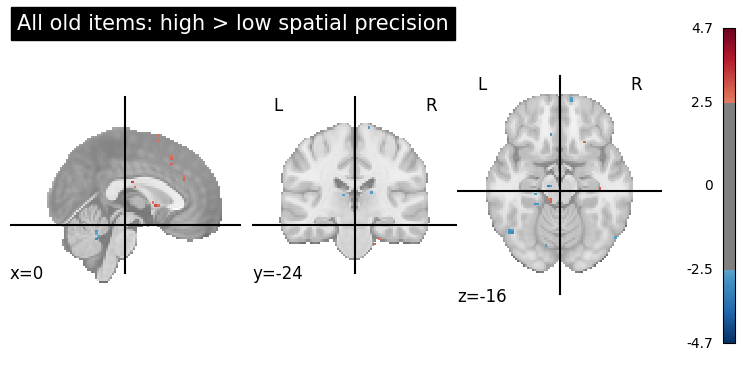

In [54]:
# --------------------------------------------------
# Whole-brain view
# --------------------------------------------------

plotting.plot_stat_map(
    group_z_spatial_all,
    threshold=2.5,
    display_mode="ortho",
    cut_coords=[0, -24, -16],
    title="All old items: high > low spatial precision",
    colorbar=True,
)
plt.show()

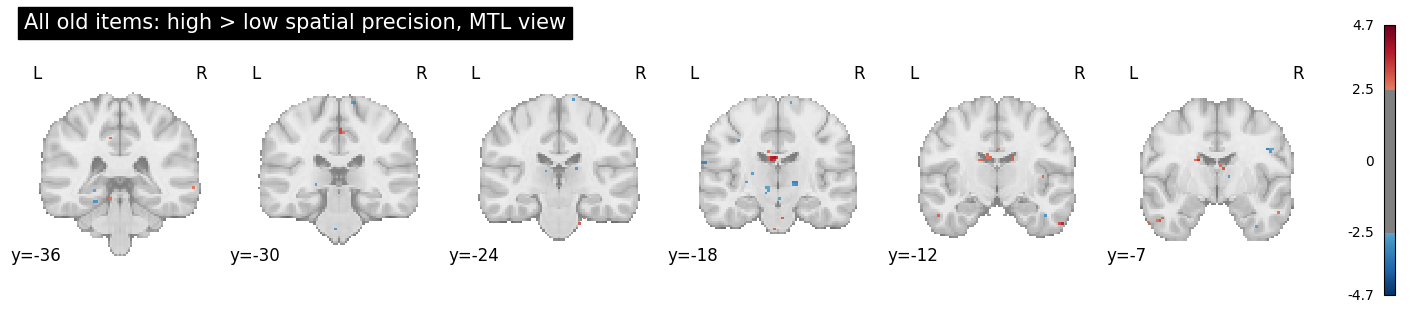

In [55]:
# --------------------------------------------------
# MTL coronal view
# --------------------------------------------------

plotting.plot_stat_map(
    group_z_spatial_all,
    threshold=2.5,
    display_mode="y",
    cut_coords=[-36, -30, -24, -18, -12, -7],
    title="All old items: high > low spatial precision, MTL view",
    colorbar=True,
)
plt.show()

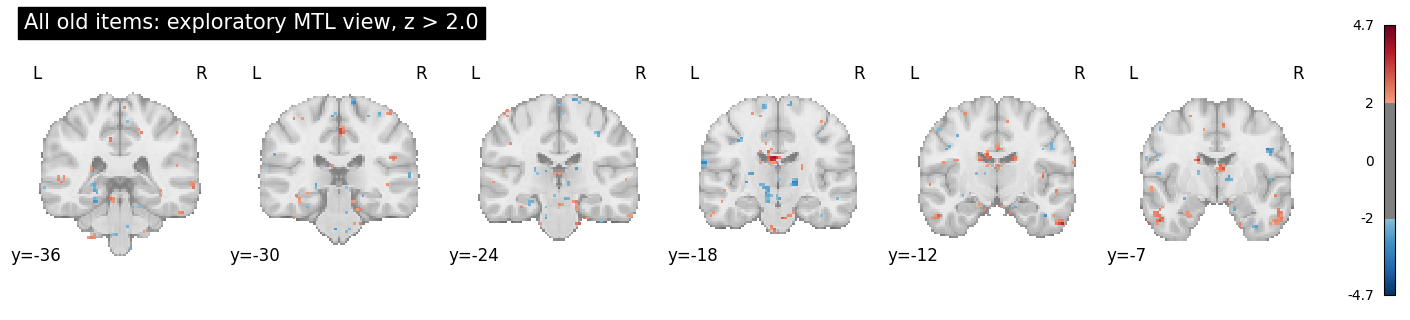

In [56]:
plotting.plot_stat_map(
    group_z_spatial_all,
    threshold=2.0,
    display_mode="y",
    cut_coords=[-36, -30, -24, -18, -12, -7],
    title="All old items: exploratory MTL view, z > 2.0",
    colorbar=True,
)
plt.show()

In [57]:
# --------------------------------------------------
# Cluster table
# --------------------------------------------------

clusters_spatial_all = get_clusters_table(
    group_z_spatial_all,
    stat_threshold=2.5,
    cluster_threshold=5,
)

display(clusters_spatial_all)

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,21.5,-2.0,7.0,4.743882,109
1,2,16.5,18.0,59.5,3.918109,375
2,2a,9.0,23.0,67.0,3.185077,
3,3,-3.5,-17.0,24.5,3.867272,281
4,4,-8.5,-34.5,-13.0,3.718602,125
5,5,59.0,-12.0,-35.5,3.585253,109
6,6,-16.0,-9.5,22.0,3.548262,187
7,7,21.5,-74.5,-25.5,3.457017,187
8,8,34.0,25.5,-13.0,3.356598,93
9,9,-31.0,10.5,4.5,3.289488,109


In [58]:
# --------------------------------------------------
# Atlas labeling for all-old spatial precision clusters
# --------------------------------------------------

clusters_to_label_all = clusters_spatial_all.copy()

labels_sub = []
labels_cort = []

for _, row in clusters_to_label_all.iterrows():
    x, y, z = row["X"], row["Y"], row["Z"]
    
    labels_sub.append(
        label_peak_with_atlas(x, y, z, subcort_img, subcort_labels)
    )
    
    labels_cort.append(
        label_peak_with_atlas(x, y, z, cort_img, cort_labels)
    )

clusters_to_label_all["subcortical_label"] = labels_sub
clusters_to_label_all["cortical_label"] = labels_cort

display(clusters_to_label_all)

clusters_to_label_all.to_csv(
    OUT_DIR_ALL / "group_post_high_vs_low_spatial_precision_all_old_clusters_labeled_z25.csv",
    index=False,
)

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),subcortical_label,cortical_label
0,1,21.5,-2.0,7.0,4.743882,109,Right Putamen,Background
1,2,16.5,18.0,59.5,3.918109,375,Right Cerebral Cortex,Superior Frontal Gyrus
2,2a,9.0,23.0,67.0,3.185077,,Right Cerebral Cortex,Background
3,3,-3.5,-17.0,24.5,3.867272,281,Left Cerebral White Matter,Background
4,4,-8.5,-34.5,-13.0,3.718602,125,Brain-Stem,Background
5,5,59.0,-12.0,-35.5,3.585253,109,Right Cerebral Cortex,"Inferior Temporal Gyrus, posterior division"
6,6,-16.0,-9.5,22.0,3.548262,187,Left Caudate,Background
7,7,21.5,-74.5,-25.5,3.457017,187,Background,Background
8,8,34.0,25.5,-13.0,3.356598,93,Right Cerebral Cortex,Frontal Orbital Cortex
9,9,-31.0,10.5,4.5,3.289488,109,Left Cerebral White Matter,Background


In [59]:
# --------------------------------------------------
# ROI extraction: all recognized old items
# --------------------------------------------------

roi_effect_rows_all = []

for effect_path in spatial_all_maps:
    sub = effect_path.parts[-2]
    effect_img = nib.load(str(effect_path))
    
    for roi_name, roi_mask in roi_dict.items():
        roi_mask_resampled = image.resample_to_img(
            roi_mask,
            effect_img,
            interpolation="nearest",
            force_resample=True,
            copy_header=True,
        )
        
        masker = NiftiMasker(mask_img=roi_mask_resampled, standardize=False)
        values = masker.fit_transform(effect_img).ravel()
        
        roi_effect_rows_all.append({
            "sub": sub,
            "roi": roi_name,
            "mean_effect": np.nanmean(values),
        })

roi_effect_df_all = pd.DataFrame(roi_effect_rows_all)

roi_stats_rows_all = []

for roi, df in roi_effect_df_all.groupby("roi"):
    values = df["mean_effect"].dropna()
    
    t_res = ttest_1samp(values, 0)
    w_res = wilcoxon(values)
    
    roi_stats_rows_all.append({
        "roi": roi,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_res.pvalue,
    })

roi_stats_df_all = pd.DataFrame(roi_stats_rows_all).sort_values("p")

display(roi_stats_df_all)

roi_effect_df_all.to_csv(
    OUT_DIR_ALL / "post_high_vs_low_spatial_precision_all_old_roi_effects.csv",
    index=False,
)

roi_stats_df_all.to_csv(
    OUT_DIR_ALL / "post_high_vs_low_spatial_precision_all_old_roi_stats.csv",
    index=False,
)

/tmp/ipykernel_2877896/574923264.py:21: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykernel_2877896/574923264.py:21: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykernel_2877896/574923264.py:21: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykernel_2877896/574923264.py:21: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykernel_2

,roi,n,mean_effect,std,t,p,wilcoxon_p
3,visual_ventral,20,-0.014097,0.053552,-1.177262,0.253628,0.277355
2,parahippocampal,20,0.014904,0.069588,0.957814,0.350187,0.388376
0,amygdala,20,0.009619,0.063799,0.674261,0.508267,0.452375
1,hippocampus,20,-0.002850,0.049710,-0.256413,0.800388,0.728506


In [60]:
# --------------------------------------------------
# Extract hippocampus/parahippocampal clusters
# --------------------------------------------------

mtl_clusters_all = clusters_to_label_all[
    clusters_to_label_all["subcortical_label"].str.contains("Hippocampus", na=False)
    | clusters_to_label_all["cortical_label"].str.contains("Parahippocampal", na=False)
].copy()

display(mtl_clusters_all)

mtl_clusters_all.to_csv(
    OUT_DIR_ALL / "group_post_high_vs_low_spatial_precision_all_old_MTL_clusters.csv",
    index=False,
)

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),subcortical_label,cortical_label


In [13]:
# --------------------------------------------------
# New folders for relevance x spatial precision interaction
# --------------------------------------------------

OUT_DIR_INTERACTION = PROJECT_ROOT / "data" / "processed" / "glm" / "spatial_precision_relevance_interaction"
OUT_DIR_INTERACTION.mkdir(parents=True, exist_ok=True)

EVENTS_OUT_DIR_INTERACTION = PROJECT_ROOT / "data" / "preprocessed" / "relabeled_events_spatial_precision_relevance_interaction"
EVENTS_OUT_DIR_INTERACTION.mkdir(parents=True, exist_ok=True)

print("OUT_DIR_INTERACTION:", OUT_DIR_INTERACTION)
print("EVENTS_OUT_DIR_INTERACTION:", EVENTS_OUT_DIR_INTERACTION)

OUT_DIR_INTERACTION: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_precision_relevance_interaction
EVENTS_OUT_DIR_INTERACTION: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_spatial_precision_relevance_interaction


In [62]:
# --------------------------------------------------
# Create relevance x spatial precision labels
# --------------------------------------------------

item_memory_interaction = item_memory_all.copy()

item_memory_interaction["relevance_label"] = np.where(
    item_memory_interaction["is_relevant"],
    "relevant",
    "irrelevant",
)

item_memory_interaction["interaction_trial_type"] = (
    item_memory_interaction["relevance_label"]
    + "_"
    + item_memory_interaction["spatial_precision_group"]
)

print("Interaction item table:", item_memory_interaction.shape)

print("\nTrial type counts:")
print(item_memory_interaction["interaction_trial_type"].value_counts())

print("\nBy subject:")
display(
    pd.crosstab(
        item_memory_interaction["sub"],
        item_memory_interaction["interaction_trial_type"],
    )
)

print("\nBy encoding session:")
display(
    pd.crosstab(
        item_memory_interaction["encoding_session"],
        item_memory_interaction["interaction_trial_type"],
    )
)

Interaction item table: (846, 26)

Trial type counts:
interaction_trial_type
relevant_high_spatial_precision      229
irrelevant_low_spatial_precision     218
relevant_low_spatial_precision       201
irrelevant_high_spatial_precision    198
Name: count, dtype: int64

By subject:


interaction_trial_type,irrelevant_high_spatial_precision,irrelevant_low_spatial_precision,relevant_high_spatial_precision,relevant_low_spatial_precision
sub,,,,
sub-P10,4,8,10,6
sub-P12,6,6,9,9
sub-P13,10,11,11,10
sub-P14,12,12,12,11
sub-P15,10,14,14,10
sub-P18,11,11,11,11
sub-P19,9,10,10,8
sub-P20,9,14,14,9
sub-P21,10,7,8,10



By encoding session:


interaction_trial_type,irrelevant_high_spatial_precision,irrelevant_low_spatial_precision,relevant_high_spatial_precision,relevant_low_spatial_precision
encoding_session,,,,
e1,68,75,78,69
e2,69,71,69,75
e3,61,72,82,57


In [63]:
# --------------------------------------------------
# Create post-viewing events with four relevance x precision regressors
# --------------------------------------------------

for sub, sub_df in item_memory_interaction.groupby("sub"):
    
    ses = "ses-05"
    
    events_path = (
        BIDS_DIR
        / sub
        / ses
        / "func"
        / f"{sub}_{ses}_task-viewing_run-01_events.tsv"
    )
    
    if not events_path.exists():
        print("Missing events:", events_path)
        continue
    
    events = pd.read_csv(events_path, sep="\t")
    
    label_map = sub_df[[
        "event_filename",
        "interaction_trial_type",
        "spatial_precision_group",
        "placement_distance",
        "placement_confidence",
        "temporal_confidence",
        "is_relevant",
        "encoding_session",
    ]].copy()
    
    events_labeled = events.merge(
        label_map,
        left_on="event",
        right_on="event_filename",
        how="left",
    )
    
    events_labeled["trial_type"] = "other"
    
    mask = events_labeled["interaction_trial_type"].notna()
    events_labeled.loc[mask, "trial_type"] = events_labeled.loc[mask, "interaction_trial_type"]
    
    glm_events = events_labeled[["onset", "duration", "trial_type"]].copy()
    
    out_path = EVENTS_OUT_DIR_INTERACTION / f"{sub}_{ses}_task-viewing_run-01_events_spatial_precision_relevance_interaction.tsv"
    glm_events.to_csv(out_path, sep="\t", index=False)
    
    print("\n", sub)
    print(glm_events["trial_type"].value_counts())
    print("Saved:", out_path)


 sub-P10
trial_type
other                                216
relevant_high_spatial_precision       60
irrelevant_low_spatial_precision      48
relevant_low_spatial_precision        36
irrelevant_high_spatial_precision     24
Name: count, dtype: int64
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_spatial_precision_relevance_interaction/sub-P10_ses-05_task-viewing_run-01_events_spatial_precision_relevance_interaction.tsv

 sub-P12
trial_type
other                                204
relevant_low_spatial_precision        54
relevant_high_spatial_precision       54
irrelevant_high_spatial_precision     36
irrelevant_low_spatial_precision      36
Name: count, dtype: int64
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_spatial_precision_relevance_interaction/sub-P12_ses-05_task-viewing_run-01_events_spatial_precision_relevance_interaction.tsv

 sub-P13
trial_type
other  

In [64]:
def run_subject_spatial_precision_relevance_interaction_glm(
    sub,
    smooth_fwhm=5.0,
    fmriprep_dir=FMRIPREP_DIR,
    events_dir=EVENTS_OUT_DIR_INTERACTION,
):
    ses = "ses-05"
    
    bold_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*space-MNI152NLin2009cAsym*desc-preproc_bold.nii.gz"
        )
    )
    
    confound_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*desc-confounds_timeseries.tsv"
        )
    )
    
    events_path = events_dir / f"{sub}_{ses}_task-viewing_run-01_events_spatial_precision_relevance_interaction.tsv"
    
    if len(bold_candidates) == 0 or len(confound_candidates) == 0 or not events_path.exists():
        print("Missing files for", sub)
        return None
    
    bold_path = bold_candidates[0]
    confounds_path = confound_candidates[0]
    
    bold_img = nib.load(str(bold_path))
    events = pd.read_csv(events_path, sep="\t")
    confounds = pd.read_csv(confounds_path, sep="\t")
    
    print("\n" + "="*70)
    print(sub)
    print("="*70)
    print(events["trial_type"].value_counts())
    
    confound_cols = [
        "trans_x", "trans_y", "trans_z",
        "rot_x", "rot_y", "rot_z",
        "global_signal", "csf", "white_matter",
    ]
    
    available_confound_cols = [c for c in confound_cols if c in confounds.columns]
    selected_confounds = confounds[available_confound_cols].copy()
    selected_confounds = selected_confounds.replace([np.inf, -np.inf], np.nan)
    selected_confounds = selected_confounds.fillna(0)
    
    gm_mask = datasets.load_mni152_gm_mask(threshold=0.2)
    gm_mask_resampled = image.resample_to_img(
        gm_mask,
        bold_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    fmri_glm = FirstLevelModel(
        t_r=1.0,
        slice_time_ref=0.5,
        hrf_model="spm + derivative + dispersion",
        drift_model="cosine",
        high_pass=0.01,
        mask_img=gm_mask_resampled,
        smoothing_fwhm=smooth_fwhm,
        standardize=False,
        signal_scaling=0,
        noise_model="ar1",
        minimize_memory=False,
        n_jobs=-1,
    )
    
    fmri_glm = fmri_glm.fit(
        run_imgs=bold_img,
        events=events,
        confounds=selected_confounds,
    )
    
    design_matrix = fmri_glm.design_matrices_[0]
    
    condition_names = [
        "irrelevant_high_spatial_precision",
        "irrelevant_low_spatial_precision",
        "relevant_high_spatial_precision",
        "relevant_low_spatial_precision",
    ]
    
    print("Condition regressors:")
    print([c for c in design_matrix.columns if c in condition_names])
    
    for c in condition_names:
        if c not in design_matrix.columns:
            print("Missing condition:", c)
            return None
    
    def make_contrast(weights):
        contrast_vec = np.zeros(len(design_matrix.columns))
        for name, weight in weights.items():
            contrast_vec[design_matrix.columns.get_loc(name)] = weight
        return contrast_vec
    
    contrasts = {
        "irrelevant_high_vs_low": make_contrast({
            "irrelevant_high_spatial_precision": 1.0,
            "irrelevant_low_spatial_precision": -1.0,
        }),
        "relevant_high_vs_low": make_contrast({
            "relevant_high_spatial_precision": 1.0,
            "relevant_low_spatial_precision": -1.0,
        }),
        "interaction_irrelevant_minus_relevant": make_contrast({
            "irrelevant_high_spatial_precision": 1.0,
            "irrelevant_low_spatial_precision": -1.0,
            "relevant_high_spatial_precision": -1.0,
            "relevant_low_spatial_precision": 1.0,
        }),
        "main_high_vs_low": make_contrast({
            "irrelevant_high_spatial_precision": 0.5,
            "relevant_high_spatial_precision": 0.5,
            "irrelevant_low_spatial_precision": -0.5,
            "relevant_low_spatial_precision": -0.5,
        }),
    }
    
    z_maps = {}
    effect_maps = {}
    
    for contrast_name, contrast_vec in contrasts.items():
        z_maps[contrast_name] = fmri_glm.compute_contrast(
            contrast_vec,
            output_type="z_score",
        )
        effect_maps[contrast_name] = fmri_glm.compute_contrast(
            contrast_vec,
            output_type="effect_size",
        )
    
    return {
        "sub": sub,
        "glm": fmri_glm,
        "design_matrix": design_matrix,
        "z_maps": z_maps,
        "effect_maps": effect_maps,
    }

In [65]:
interaction_results = []
interaction_maps = {
    "irrelevant_high_vs_low": [],
    "relevant_high_vs_low": [],
    "interaction_irrelevant_minus_relevant": [],
    "main_high_vs_low": [],
}

for sub in sorted(item_memory_interaction["sub"].unique()):
    res = run_subject_spatial_precision_relevance_interaction_glm(sub)
    
    if res is None:
        continue
    
    sub_dir = OUT_DIR_INTERACTION / sub
    sub_dir.mkdir(parents=True, exist_ok=True)
    
    for contrast_name in interaction_maps.keys():
        z_path = sub_dir / f"{sub}_{contrast_name}_z.nii.gz"
        effect_path = sub_dir / f"{sub}_{contrast_name}_effect.nii.gz"
        
        res["z_maps"][contrast_name].to_filename(z_path)
        res["effect_maps"][contrast_name].to_filename(effect_path)
        
        interaction_maps[contrast_name].append(effect_path)
    
    interaction_results.append(res)

print("Processed subjects:", len(interaction_results))
print([r["sub"] for r in interaction_results])

for contrast_name, paths in interaction_maps.items():
    print(contrast_name, len(paths))


sub-P10
trial_type
other                                216
relevant_high_spatial_precision       60
irrelevant_low_spatial_precision      48
relevant_low_spatial_precision        36
irrelevant_high_spatial_precision     24
Name: count, dtype: int64
Condition regressors:
['irrelevant_high_spatial_precision', 'irrelevant_low_spatial_precision', 'relevant_high_spatial_precision', 'relevant_low_spatial_precision']

sub-P12
trial_type
other                                204
relevant_low_spatial_precision        54
relevant_high_spatial_precision       54
irrelevant_high_spatial_precision     36
irrelevant_low_spatial_precision      36
Name: count, dtype: int64
Condition regressors:
['irrelevant_high_spatial_precision', 'irrelevant_low_spatial_precision', 'relevant_high_spatial_precision', 'relevant_low_spatial_precision']

sub-P13
trial_type
other                                132
irrelevant_low_spatial_precision      66
relevant_high_spatial_precision       66
relevant_low_spatial_prec

/tmp/ipykernel_2877896/1150635865.py:74: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


Condition regressors:
['irrelevant_high_spatial_precision', 'irrelevant_low_spatial_precision', 'relevant_high_spatial_precision', 'relevant_low_spatial_precision']

sub-P34
trial_type
other                                126
irrelevant_high_spatial_precision     78
relevant_low_spatial_precision        72
relevant_high_spatial_precision       54
irrelevant_low_spatial_precision      54
Name: count, dtype: int64
Condition regressors:
['irrelevant_high_spatial_precision', 'irrelevant_low_spatial_precision', 'relevant_high_spatial_precision', 'relevant_low_spatial_precision']

sub-P35
trial_type
other                                132
relevant_high_spatial_precision       90
irrelevant_low_spatial_precision      84
relevant_low_spatial_precision        42
irrelevant_high_spatial_precision     36
Name: count, dtype: int64
Condition regressors:
['irrelevant_high_spatial_precision', 'irrelevant_low_spatial_precision', 'relevant_high_spatial_precision', 'relevant_low_spatial_precision']

su

/tmp/ipykernel_2877896/1150635865.py:74: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


Condition regressors:
['irrelevant_high_spatial_precision', 'irrelevant_low_spatial_precision', 'relevant_high_spatial_precision', 'relevant_low_spatial_precision']

sub-P44
trial_type
other                                102
relevant_high_spatial_precision       78
irrelevant_low_spatial_precision      72
relevant_low_spatial_precision        66
irrelevant_high_spatial_precision     66
Name: count, dtype: int64
Condition regressors:
['irrelevant_high_spatial_precision', 'irrelevant_low_spatial_precision', 'relevant_high_spatial_precision', 'relevant_low_spatial_precision']

sub-P45
trial_type
other                                120
irrelevant_low_spatial_precision      72
relevant_high_spatial_precision       66
irrelevant_high_spatial_precision     66
relevant_low_spatial_precision        60
Name: count, dtype: int64
Condition regressors:
['irrelevant_high_spatial_precision', 'irrelevant_low_spatial_precision', 'relevant_high_spatial_precision', 'relevant_low_spatial_precision']

su

In [54]:
def run_second_level_from_maps(map_paths, contrast_name, out_dir):
    map_paths = sorted(map_paths)
    
    print("\n" + "="*80)
    print("Second level:", contrast_name)
    print("N maps:", len(map_paths))
    
    design_matrix_group = pd.DataFrame(
        np.ones(len(map_paths)),
        columns=["intercept"],
    )
    
    second_level_model = SecondLevelModel(
        smoothing_fwhm=None,
        n_jobs=-1,
    )
    
    second_level_model = second_level_model.fit(
        map_paths,
        design_matrix=design_matrix_group,
    )
    
    group_z = second_level_model.compute_contrast(
        "intercept",
        output_type="z_score",
    )
    
    out_path = out_dir / f"group_{contrast_name}_z.nii.gz"
    group_z.to_filename(out_path)
    
    print("Saved:", out_path)
    
    return group_z

In [67]:
group_z_interaction_results = {}

for contrast_name, paths in interaction_maps.items():
    group_z_interaction_results[contrast_name] = run_second_level_from_maps(
        paths,
        contrast_name,
        OUT_DIR_INTERACTION,
    )


Second level: irrelevant_high_vs_low
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_precision_relevance_interaction/group_irrelevant_high_vs_low_z.nii.gz

Second level: relevant_high_vs_low
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_precision_relevance_interaction/group_relevant_high_vs_low_z.nii.gz

Second level: interaction_irrelevant_minus_relevant
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_precision_relevance_interaction/group_interaction_irrelevant_minus_relevant_z.nii.gz

Second level: main_high_vs_low
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_precision_relevance_interaction/group_main_high_vs_low_z.nii.gz


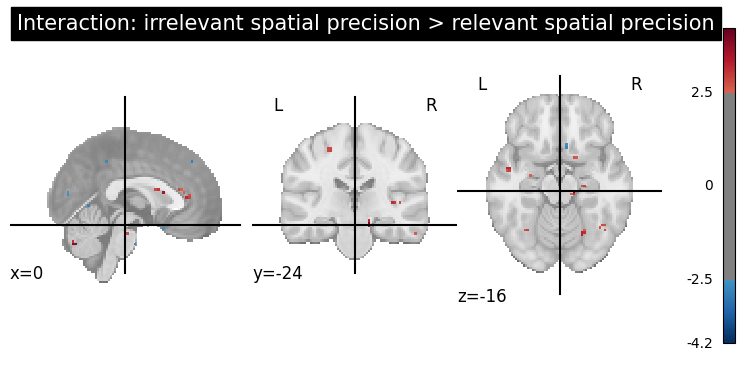

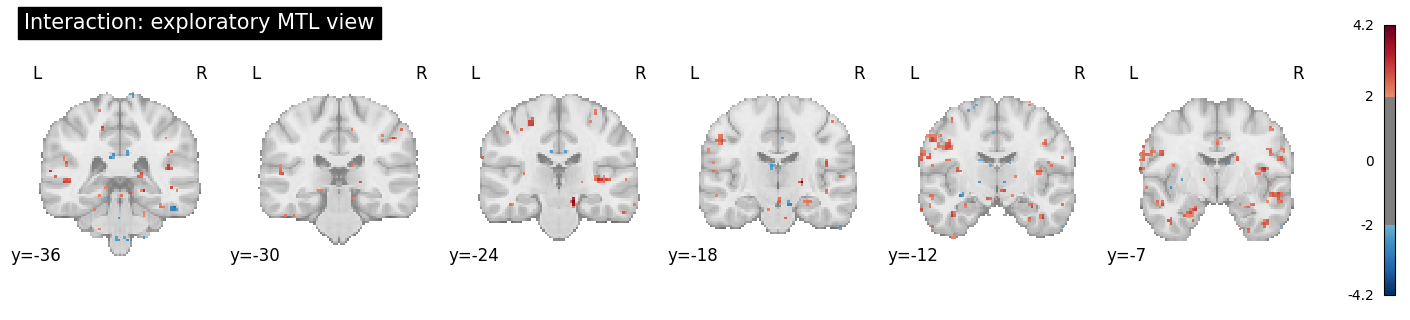

In [68]:
# --------------------------------------------------
# Key interaction map
# (irrelevant high-low) - (relevant high-low)
# --------------------------------------------------

group_z_interaction = group_z_interaction_results["interaction_irrelevant_minus_relevant"]

plotting.plot_stat_map(
    group_z_interaction,
    threshold=2.5,
    display_mode="ortho",
    cut_coords=[0, -24, -16],
    title="Interaction: irrelevant spatial precision > relevant spatial precision",
    colorbar=True,
)
plt.show()

plotting.plot_stat_map(
    group_z_interaction,
    threshold=2.0,
    display_mode="y",
    cut_coords=[-36, -30, -24, -18, -12, -7],
    title="Interaction: exploratory MTL view",
    colorbar=True,
)
plt.show()

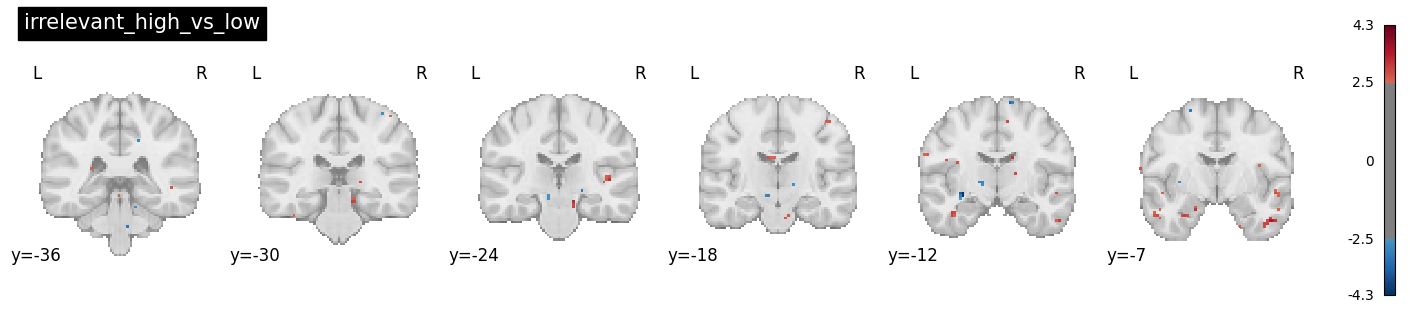

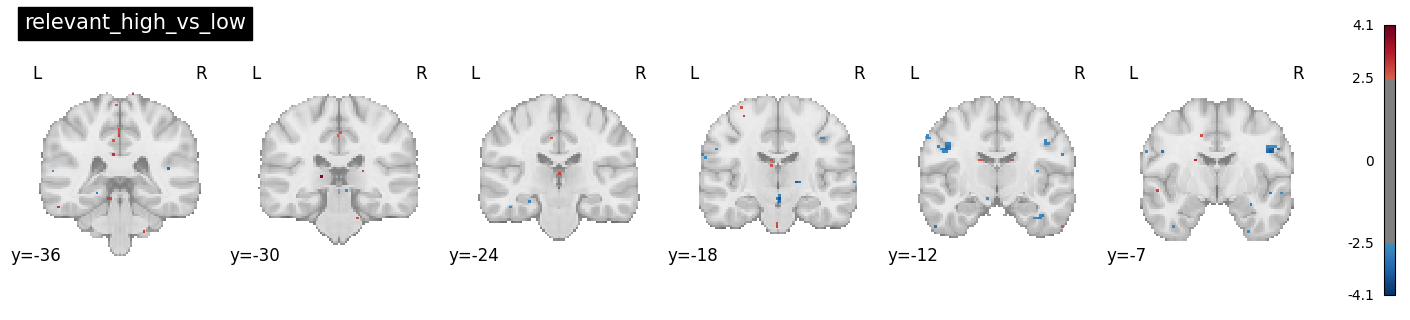

In [69]:
for contrast_name in ["irrelevant_high_vs_low", "relevant_high_vs_low"]:
    group_z = group_z_interaction_results[contrast_name]
    
    plotting.plot_stat_map(
        group_z,
        threshold=2.5,
        display_mode="y",
        cut_coords=[-36, -30, -24, -18, -12, -7],
        title=contrast_name,
        colorbar=True,
    )
    plt.show()

In [70]:
interaction_cluster_tables = {}

for contrast_name, group_z in group_z_interaction_results.items():
    print("\n" + "="*80)
    print(contrast_name)
    
    clusters = get_clusters_table(
        group_z,
        stat_threshold=2.5,
        cluster_threshold=5,
    )
    
    clusters_labeled = clusters.copy()
    
    labels_sub = []
    labels_cort = []
    
    for _, row in clusters_labeled.iterrows():
        x, y, z = row["X"], row["Y"], row["Z"]
        
        labels_sub.append(
            label_peak_with_atlas(x, y, z, subcort_img, subcort_labels)
        )
        
        labels_cort.append(
            label_peak_with_atlas(x, y, z, cort_img, cort_labels)
        )
    
    clusters_labeled["subcortical_label"] = labels_sub
    clusters_labeled["cortical_label"] = labels_cort
    
    display(clusters_labeled)
    
    clusters_labeled.to_csv(
        OUT_DIR_INTERACTION / f"group_{contrast_name}_clusters_labeled_z25.csv",
        index=False,
    )
    
    interaction_cluster_tables[contrast_name] = clusters_labeled


irrelevant_high_vs_low


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),subcortical_label,cortical_label
0,1,14.0,10.5,59.5,4.029249,187,Right Cerebral White Matter,Superior Frontal Gyrus
1,2,19.0,0.5,-38.0,3.503030,234,Right Cerebral Cortex,"Parahippocampal Gyrus, anterior division"
2,3,21.5,3.0,-48.0,3.440849,203,Right Cerebral Cortex,Background
3,4,49.0,-7.0,-33.0,3.439251,343,Right Cerebral Cortex,"Inferior Temporal Gyrus, anterior division"
4,5,14.0,-27.0,-15.5,3.247678,125,Brain-Stem,Background
5,6,-23.5,-4.5,-28.0,3.178411,93,Left Amygdala,Background
6,7,46.5,-24.5,4.5,3.162309,93,Right Cerebral White Matter,Background
7,8,-16.0,25.5,62.0,3.033754,203,Left Cerebral Cortex,Superior Frontal Gyrus
8,9,19.0,10.5,19.5,3.010201,93,Right Caudate,Background
9,10,-53.5,-9.5,-28.0,3.008406,109,Left Cerebral Cortex,Background



relevant_high_vs_low


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),subcortical_label,cortical_label
0,1,9.0,18.0,64.5,4.049611,312,Right Cerebral Cortex,Superior Frontal Gyrus
1,2,44.0,-44.5,-43.0,3.627381,250,Background,Background
2,3,16.5,23.0,52.0,3.482398,78,Right Cerebral White Matter,Background
3,4,-11.0,-39.5,-13.0,3.438519,78,Background,Background
4,5,-1.0,-14.5,-35.5,3.398290,78,Brain-Stem,Background
5,6,4.0,-42.0,42.0,3.336420,78,Right Cerebral Cortex,"Cingulate Gyrus, posterior division"
6,7,1.5,23.0,59.5,3.334185,125,Right Cerebral Cortex,Superior Frontal Gyrus
7,8,-26.0,-72.0,-40.5,3.306602,78,Background,Background
8,9,54.0,-52.0,32.0,3.298160,93,Right Cerebral Cortex,Angular Gyrus
9,10,36.5,-47.0,34.5,3.259000,78,Right Cerebral White Matter,Background



interaction_irrelevant_minus_relevant


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),subcortical_label,cortical_label
0,1,-38.5,-74.5,14.5,4.180268,156,Left Cerebral White Matter,"Lateral Occipital Cortex, inferior division"
1,2,56.5,-2.0,-10.5,3.835361,343,Right Cerebral Cortex,"Superior Temporal Gyrus, anterior division"
2,3,14.0,-24.5,-15.5,3.833800,125,Brain-Stem,Background
3,4,-1.0,-74.5,-35.5,3.774322,140,Background,Background
4,5,21.5,-79.5,34.5,3.634630,125,Right Cerebral White Matter,"Lateral Occipital Cortex, superior division"
5,6,36.5,-27.0,4.5,3.541927,78,Right Cerebral White Matter,Background
6,7,24.0,5.5,-45.5,3.536090,296,Right Cerebral Cortex,Temporal Pole
7,8,-8.5,-19.5,-25.5,3.535441,78,Brain-Stem,Background
8,9,-43.5,40.5,-20.5,3.534889,93,Left Cerebral Cortex,Frontal Pole
9,10,26.5,-54.5,57.0,3.413634,156,Right Cerebral Cortex,Superior Parietal Lobule



main_high_vs_low


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),subcortical_label,cortical_label
0,1,21.5,-2.0,7.0,4.967395,109,Right Putamen,Background
1,2,-3.5,-17.0,24.5,3.646461,203,Left Cerebral White Matter,Background
2,3,1.5,-29.5,49.5,3.541825,93,Right Cerebral Cortex,Precentral Gyrus
3,4,-18.5,-72.0,-30.5,3.446279,156,Background,Background
4,5,-43.5,15.5,57.0,3.413255,250,Background,Background
5,5a,-36.0,20.5,49.5,2.784737,,Left Cerebral Cortex,Middle Frontal Gyrus
6,6,56.5,-9.5,-35.5,3.324140,140,Right Cerebral Cortex,"Inferior Temporal Gyrus, posterior division"
7,7,-16.0,-2.0,19.5,3.250564,93,Left Caudate,Background
8,8,14.0,20.5,64.5,3.240027,296,Right Cerebral Cortex,Superior Frontal Gyrus
9,9,-8.5,-34.5,-13.0,3.192078,78,Brain-Stem,Background


In [71]:
interaction_roi_rows = []

for contrast_name, paths in interaction_maps.items():
    for effect_path in paths:
        sub = effect_path.parts[-2]
        effect_img = nib.load(str(effect_path))
        
        for roi_name, roi_mask in roi_dict.items():
            roi_mask_resampled = image.resample_to_img(
                roi_mask,
                effect_img,
                interpolation="nearest",
                force_resample=True,
                copy_header=True,
            )
            
            masker = NiftiMasker(mask_img=roi_mask_resampled, standardize=False)
            values = masker.fit_transform(effect_img).ravel()
            
            interaction_roi_rows.append({
                "contrast": contrast_name,
                "sub": sub,
                "roi": roi_name,
                "mean_effect": np.nanmean(values),
            })

interaction_roi_df = pd.DataFrame(interaction_roi_rows)

interaction_roi_stats_rows = []

for (contrast_name, roi), df in interaction_roi_df.groupby(["contrast", "roi"]):
    values = df["mean_effect"].dropna()
    
    t_res = ttest_1samp(values, 0)
    w_res = wilcoxon(values)
    
    interaction_roi_stats_rows.append({
        "contrast": contrast_name,
        "roi": roi,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_res.pvalue,
    })

interaction_roi_stats_df = pd.DataFrame(interaction_roi_stats_rows).sort_values(
    ["contrast", "p"]
)

display(interaction_roi_stats_df)

interaction_roi_df.to_csv(
    OUT_DIR_INTERACTION / "relevance_spatial_precision_roi_effects.csv",
    index=False,
)

interaction_roi_stats_df.to_csv(
    OUT_DIR_INTERACTION / "relevance_spatial_precision_roi_stats.csv",
    index=False,
)

/tmp/ipykernel_2877896/3682186409.py:18: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykernel_2877896/3682186409.py:18: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykernel_2877896/3682186409.py:18: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykernel_2877896/3682186409.py:18: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  values = masker.fit_transform(effect_img).ravel()
/tmp/ipykern

,contrast,roi,n,mean_effect,std,t,p,wilcoxon_p
2,interaction_irrelevant_minus_relevant,parahippocampal,20,0.034465,0.102065,1.510125,0.147463,0.176853
0,interaction_irrelevant_minus_relevant,amygdala,20,0.041896,0.155932,1.201573,0.244293,0.430433
3,interaction_irrelevant_minus_relevant,visual_ventral,20,0.023260,0.087455,1.189448,0.248916,0.348810
1,interaction_irrelevant_minus_relevant,hippocampus,20,0.021075,0.099042,0.951610,0.353244,0.277355
6,irrelevant_high_vs_low,parahippocampal,20,0.026465,0.085783,1.379728,0.183693,0.294252
4,irrelevant_high_vs_low,amygdala,20,0.026578,0.106481,1.116248,0.278235,0.311794
7,irrelevant_high_vs_low,visual_ventral,20,-0.004412,0.067481,-0.292393,0.773155,0.570597
5,irrelevant_high_vs_low,hippocampus,20,0.003259,0.079945,0.182302,0.857277,0.756166
11,main_high_vs_low,visual_ventral,20,-0.012865,0.053662,-1.072165,0.297076,0.230513
10,main_high_vs_low,parahippocampal,20,0.010508,0.072307,0.649929,0.523519,0.595819


In [12]:
# --------------------------------------------------
# Peak-sphere extraction for irrelevant high > low MTL peaks
# from the four-regressor relevance interaction model
# --------------------------------------------------

peak_coords_interaction_model = {
    "right_anterior_parahippocampal_irrelevant": [19.0, 0.5, -38.0],
    "left_amygdala_irrelevant": [-23.5, -4.5, -28.0],
}

irrelevant_effect_paths = sorted(
    OUT_DIR_INTERACTION.glob("sub-*/*irrelevant_high_vs_low_effect.nii.gz")
)

sphere_rows_irrelevant = []

for effect_path in irrelevant_effect_paths:
    sub = effect_path.parts[-2]
    effect_img = nib.load(str(effect_path))
    
    for peak_name, coord in peak_coords_interaction_model.items():
        masker = NiftiSpheresMasker(
            seeds=[coord],
            radius=5,
            standardize=False,
        )
        
        value = masker.fit_transform(effect_img).ravel()[0]
        
        sphere_rows_irrelevant.append({
            "sub": sub,
            "peak": peak_name,
            "mean_effect": value,
        })

sphere_effect_irrelevant_df = pd.DataFrame(sphere_rows_irrelevant)

display(sphere_effect_irrelevant_df.head())

NameError: name 'OUT_DIR_INTERACTION' is not defined

In [73]:
sphere_stats_irrelevant_rows = []

for peak, df in sphere_effect_irrelevant_df.groupby("peak"):
    values = df["mean_effect"].dropna()
    
    t_res = ttest_1samp(values, 0)
    w_res = wilcoxon(values)
    
    sphere_stats_irrelevant_rows.append({
        "peak": peak,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_res.pvalue,
    })

sphere_stats_irrelevant_df = pd.DataFrame(sphere_stats_irrelevant_rows).sort_values("p")
display(sphere_stats_irrelevant_df)

,peak,n,mean_effect,std,t,p,wilcoxon_p
1,right_anterior_parahippocampal_irrelevant,20,0.216097,0.288455,3.350303,0.003362,0.002325
0,left_amygdala_irrelevant,20,0.079647,0.139927,2.545557,0.019744,0.026642


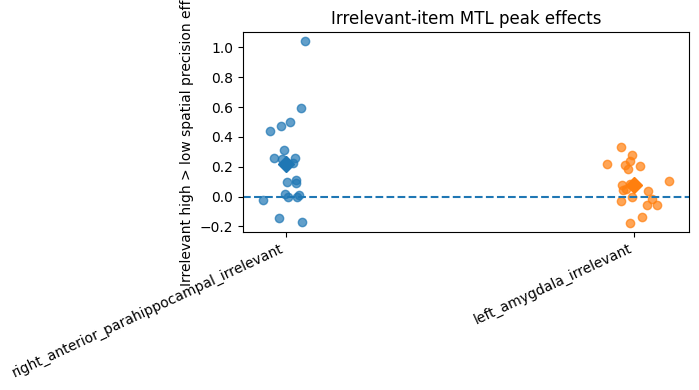

In [74]:
plt.figure(figsize=(7, 4))

peaks = sphere_stats_irrelevant_df["peak"].tolist()

for i, peak in enumerate(peaks):
    vals = sphere_effect_irrelevant_df.query("peak == @peak")["mean_effect"].dropna().values
    x = np.repeat(i, len(vals)) + np.random.normal(0, 0.04, len(vals))
    
    plt.scatter(x, vals, alpha=0.7)
    plt.plot(i, vals.mean(), marker="D", markersize=8)

plt.axhline(0, linestyle="--")
plt.xticks(range(len(peaks)), peaks, rotation=25, ha="right")
plt.ylabel("Irrelevant high > low spatial precision effect")
plt.title("Irrelevant-item MTL peak effects")
plt.tight_layout()
plt.show()

In [11]:
sphere_effect_irrelevant_df.to_csv(
    OUT_DIR_INTERACTION / "irrelevant_high_vs_low_MTL_peak_sphere_effects.csv",
    index=False,
)

sphere_stats_irrelevant_df.to_csv(
    OUT_DIR_INTERACTION / "irrelevant_high_vs_low_MTL_peak_sphere_stats.csv",
    index=False,
)

NameError: name 'sphere_effect_irrelevant_df' is not defined

In [76]:
# --------------------------------------------------
# Output folders for irrelevant spatial precision x encoding session
# --------------------------------------------------

OUT_DIR_TEMPORAL = PROJECT_ROOT / "data" / "processed" / "glm" / "irrelevant_spatial_precision_by_encoding_session"
OUT_DIR_TEMPORAL.mkdir(parents=True, exist_ok=True)

EVENTS_OUT_DIR_TEMPORAL = PROJECT_ROOT / "data" / "preprocessed" / "relabeled_events_irrelevant_spatial_precision_by_encoding_session"
EVENTS_OUT_DIR_TEMPORAL.mkdir(parents=True, exist_ok=True)

print("OUT_DIR_TEMPORAL:", OUT_DIR_TEMPORAL)
print("EVENTS_OUT_DIR_TEMPORAL:", EVENTS_OUT_DIR_TEMPORAL)

OUT_DIR_TEMPORAL: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/irrelevant_spatial_precision_by_encoding_session
EVENTS_OUT_DIR_TEMPORAL: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_irrelevant_spatial_precision_by_encoding_session


In [77]:
# --------------------------------------------------
# Create labels: e1/e2/e3 x high/low, irrelevant items only
# --------------------------------------------------

item_memory_temporal = item_memory_all.query("is_relevant == False").copy()

item_memory_temporal["temporal_trial_type"] = (
    item_memory_temporal["encoding_session"]
    + "_"
    + item_memory_temporal["spatial_precision_group"]
)

print("Irrelevant recognized old items:", item_memory_temporal.shape)

print("\nTrial type counts:")
print(item_memory_temporal["temporal_trial_type"].value_counts())

print("\nBy subject:")
temporal_counts_by_subject = pd.crosstab(
    item_memory_temporal["sub"],
    item_memory_temporal["temporal_trial_type"],
)

display(temporal_counts_by_subject)

print("\nNumber of subjects with at least 1 item per cell:")
print((temporal_counts_by_subject > 0).sum())

Irrelevant recognized old items: (416, 25)

Trial type counts:
temporal_trial_type
e1_low_spatial_precision     75
e3_low_spatial_precision     72
e2_low_spatial_precision     71
e2_high_spatial_precision    69
e1_high_spatial_precision    68
e3_high_spatial_precision    61
Name: count, dtype: int64

By subject:


temporal_trial_type,e1_high_spatial_precision,e1_low_spatial_precision,e2_high_spatial_precision,e2_low_spatial_precision,e3_high_spatial_precision,e3_low_spatial_precision
sub,,,,,,
sub-P10,1,3,2,3,1,2
sub-P12,3,4,3,2,0,0
sub-P13,5,3,3,4,2,4
sub-P14,3,5,5,3,4,4
sub-P15,4,4,3,5,3,5
sub-P18,3,5,4,3,4,3
sub-P19,2,4,2,3,5,3
sub-P20,2,6,4,4,3,4
sub-P21,3,2,4,3,3,2



Number of subjects with at least 1 item per cell:
temporal_trial_type
e1_high_spatial_precision    20
e1_low_spatial_precision     20
e2_high_spatial_precision    20
e2_low_spatial_precision     20
e3_high_spatial_precision    19
e3_low_spatial_precision     19
dtype: int64


In [78]:
# --------------------------------------------------
# Create post-viewing events with e1/e2/e3 x high/low regressors
# --------------------------------------------------

for sub, sub_df in item_memory_temporal.groupby("sub"):
    
    ses = "ses-05"
    
    events_path = (
        BIDS_DIR
        / sub
        / ses
        / "func"
        / f"{sub}_{ses}_task-viewing_run-01_events.tsv"
    )
    
    if not events_path.exists():
        print("Missing events:", events_path)
        continue
    
    events = pd.read_csv(events_path, sep="\t")
    
    label_map = sub_df[[
        "event_filename",
        "temporal_trial_type",
        "spatial_precision_group",
        "placement_distance",
        "placement_confidence",
        "temporal_confidence",
        "encoding_session",
    ]].copy()
    
    events_labeled = events.merge(
        label_map,
        left_on="event",
        right_on="event_filename",
        how="left",
    )
    
    events_labeled["trial_type"] = "other"
    
    mask = events_labeled["temporal_trial_type"].notna()
    events_labeled.loc[mask, "trial_type"] = events_labeled.loc[mask, "temporal_trial_type"]
    
    glm_events = events_labeled[["onset", "duration", "trial_type"]].copy()
    
    out_path = EVENTS_OUT_DIR_TEMPORAL / f"{sub}_{ses}_task-viewing_run-01_events_irrelevant_spatial_precision_by_encoding_session.tsv"
    glm_events.to_csv(out_path, sep="\t", index=False)
    
    print("\n", sub)
    print(glm_events["trial_type"].value_counts())
    print("Saved:", out_path)


 sub-P10
trial_type
other                        312
e1_low_spatial_precision      18
e2_low_spatial_precision      18
e2_high_spatial_precision     12
e3_low_spatial_precision      12
e3_high_spatial_precision      6
e1_high_spatial_precision      6
Name: count, dtype: int64
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_irrelevant_spatial_precision_by_encoding_session/sub-P10_ses-05_task-viewing_run-01_events_irrelevant_spatial_precision_by_encoding_session.tsv

 sub-P12
trial_type
other                        312
e1_low_spatial_precision      24
e1_high_spatial_precision     18
e2_high_spatial_precision     18
e2_low_spatial_precision      12
Name: count, dtype: int64
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_irrelevant_spatial_precision_by_encoding_session/sub-P12_ses-05_task-viewing_run-01_events_irrelevant_spatial_precision_by_encoding_session.tsv

 sub-

In [79]:
def run_subject_irrelevant_temporal_precision_glm(
    sub,
    smooth_fwhm=5.0,
    fmriprep_dir=FMRIPREP_DIR,
    events_dir=EVENTS_OUT_DIR_TEMPORAL,
):
    ses = "ses-05"
    
    bold_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*space-MNI152NLin2009cAsym*desc-preproc_bold.nii.gz"
        )
    )
    
    confound_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*desc-confounds_timeseries.tsv"
        )
    )
    
    events_path = events_dir / f"{sub}_{ses}_task-viewing_run-01_events_irrelevant_spatial_precision_by_encoding_session.tsv"
    
    if len(bold_candidates) == 0 or len(confound_candidates) == 0 or not events_path.exists():
        print("Missing files for", sub)
        return None
    
    bold_img = nib.load(str(bold_candidates[0]))
    events = pd.read_csv(events_path, sep="\t")
    confounds = pd.read_csv(confound_candidates[0], sep="\t")
    
    print("\n" + "="*70)
    print(sub)
    print("="*70)
    print(events["trial_type"].value_counts())
    
    confound_cols = [
        "trans_x", "trans_y", "trans_z",
        "rot_x", "rot_y", "rot_z",
        "global_signal", "csf", "white_matter",
    ]
    
    available_confound_cols = [c for c in confound_cols if c in confounds.columns]
    selected_confounds = confounds[available_confound_cols].copy()
    selected_confounds = selected_confounds.replace([np.inf, -np.inf], np.nan)
    selected_confounds = selected_confounds.fillna(0)
    
    gm_mask = datasets.load_mni152_gm_mask(threshold=0.2)
    gm_mask_resampled = image.resample_to_img(
        gm_mask,
        bold_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    fmri_glm = FirstLevelModel(
        t_r=1.0,
        slice_time_ref=0.5,
        hrf_model="spm + derivative + dispersion",
        drift_model="cosine",
        high_pass=0.01,
        mask_img=gm_mask_resampled,
        smoothing_fwhm=smooth_fwhm,
        standardize=False,
        signal_scaling=0,
        noise_model="ar1",
        minimize_memory=False,
        n_jobs=-1,
    )
    
    fmri_glm = fmri_glm.fit(
        run_imgs=bold_img,
        events=events,
        confounds=selected_confounds,
    )
    
    design_matrix = fmri_glm.design_matrices_[0]
    
    condition_names = [
        "e1_high_spatial_precision",
        "e1_low_spatial_precision",
        "e2_high_spatial_precision",
        "e2_low_spatial_precision",
        "e3_high_spatial_precision",
        "e3_low_spatial_precision",
    ]
    
    present_conditions = [c for c in condition_names if c in design_matrix.columns]
    print("Present condition regressors:")
    print(present_conditions)
    
    def make_contrast(weights):
        contrast_vec = np.zeros(len(design_matrix.columns))
        valid = True
        
        for name, weight in weights.items():
            if name in design_matrix.columns:
                contrast_vec[design_matrix.columns.get_loc(name)] = weight
            else:
                valid = False
        
        if not valid:
            return None
        
        return contrast_vec
    
    contrast_specs = {
        "e1_high_vs_low": {
            "e1_high_spatial_precision": 1.0,
            "e1_low_spatial_precision": -1.0,
        },
        "e2_high_vs_low": {
            "e2_high_spatial_precision": 1.0,
            "e2_low_spatial_precision": -1.0,
        },
        "e3_high_vs_low": {
            "e3_high_spatial_precision": 1.0,
            "e3_low_spatial_precision": -1.0,
        },
        "e1_precision_minus_e3_precision": {
            "e1_high_spatial_precision": 1.0,
            "e1_low_spatial_precision": -1.0,
            "e3_high_spatial_precision": -1.0,
            "e3_low_spatial_precision": 1.0,
        },
        "e3_precision_minus_e1_precision": {
            "e3_high_spatial_precision": 1.0,
            "e3_low_spatial_precision": -1.0,
            "e1_high_spatial_precision": -1.0,
            "e1_low_spatial_precision": 1.0,
        },
    }
    
    z_maps = {}
    effect_maps = {}
    
    for contrast_name, weights in contrast_specs.items():
        contrast_vec = make_contrast(weights)
        
        if contrast_vec is None:
            print("Skipping contrast because of missing regressor:", contrast_name)
            continue
        
        z_maps[contrast_name] = fmri_glm.compute_contrast(
            contrast_vec,
            output_type="z_score",
        )
        effect_maps[contrast_name] = fmri_glm.compute_contrast(
            contrast_vec,
            output_type="effect_size",
        )
    
    return {
        "sub": sub,
        "glm": fmri_glm,
        "design_matrix": design_matrix,
        "z_maps": z_maps,
        "effect_maps": effect_maps,
    }

In [80]:
temporal_results = []

temporal_maps = {
    "e1_high_vs_low": [],
    "e2_high_vs_low": [],
    "e3_high_vs_low": [],
    "e1_precision_minus_e3_precision": [],
    "e3_precision_minus_e1_precision": [],
}

for sub in sorted(item_memory_temporal["sub"].unique()):
    res = run_subject_irrelevant_temporal_precision_glm(sub)
    
    if res is None:
        continue
    
    sub_dir = OUT_DIR_TEMPORAL / sub
    sub_dir.mkdir(parents=True, exist_ok=True)
    
    for contrast_name in temporal_maps.keys():
        if contrast_name not in res["effect_maps"]:
            continue
        
        z_path = sub_dir / f"{sub}_{contrast_name}_z.nii.gz"
        effect_path = sub_dir / f"{sub}_{contrast_name}_effect.nii.gz"
        
        res["z_maps"][contrast_name].to_filename(z_path)
        res["effect_maps"][contrast_name].to_filename(effect_path)
        
        temporal_maps[contrast_name].append(effect_path)
    
    temporal_results.append(res)

print("Processed subjects:", len(temporal_results))
print([r["sub"] for r in temporal_results])

for contrast_name, paths in temporal_maps.items():
    print(contrast_name, len(paths))


sub-P10
trial_type
other                        312
e1_low_spatial_precision      18
e2_low_spatial_precision      18
e2_high_spatial_precision     12
e3_low_spatial_precision      12
e3_high_spatial_precision      6
e1_high_spatial_precision      6
Name: count, dtype: int64
Present condition regressors:
['e1_high_spatial_precision', 'e1_low_spatial_precision', 'e2_high_spatial_precision', 'e2_low_spatial_precision', 'e3_high_spatial_precision', 'e3_low_spatial_precision']

sub-P12
trial_type
other                        312
e1_low_spatial_precision      24
e1_high_spatial_precision     18
e2_high_spatial_precision     18
e2_low_spatial_precision      12
Name: count, dtype: int64
Present condition regressors:
['e1_high_spatial_precision', 'e1_low_spatial_precision', 'e2_high_spatial_precision', 'e2_low_spatial_precision']
Skipping contrast because of missing regressor: e3_high_vs_low
Skipping contrast because of missing regressor: e1_precision_minus_e3_precision
Skipping contrast beca

/tmp/ipykernel_2877896/2737189756.py:71: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


Present condition regressors:
['e1_high_spatial_precision', 'e1_low_spatial_precision', 'e2_high_spatial_precision', 'e2_low_spatial_precision', 'e3_high_spatial_precision', 'e3_low_spatial_precision']

sub-P34
trial_type
other                        252
e1_high_spatial_precision     36
e3_low_spatial_precision      30
e2_high_spatial_precision     30
e2_low_spatial_precision      12
e1_low_spatial_precision      12
e3_high_spatial_precision     12
Name: count, dtype: int64
Present condition regressors:
['e1_high_spatial_precision', 'e1_low_spatial_precision', 'e2_high_spatial_precision', 'e2_low_spatial_precision', 'e3_high_spatial_precision', 'e3_low_spatial_precision']

sub-P35
trial_type
other                        264
e2_low_spatial_precision      36
e1_low_spatial_precision      24
e3_low_spatial_precision      24
e1_high_spatial_precision     18
e3_high_spatial_precision     12
e2_high_spatial_precision      6
Name: count, dtype: int64
Present condition regressors:
['e1_high_sp

/tmp/ipykernel_2877896/2737189756.py:71: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


Present condition regressors:
['e1_high_spatial_precision', 'e1_low_spatial_precision', 'e2_high_spatial_precision', 'e2_low_spatial_precision', 'e3_high_spatial_precision', 'e3_low_spatial_precision']

sub-P44
trial_type
other                        246
e2_low_spatial_precision      30
e1_high_spatial_precision     30
e3_low_spatial_precision      30
e3_high_spatial_precision     18
e2_high_spatial_precision     18
e1_low_spatial_precision      12
Name: count, dtype: int64
Present condition regressors:
['e1_high_spatial_precision', 'e1_low_spatial_precision', 'e2_high_spatial_precision', 'e2_low_spatial_precision', 'e3_high_spatial_precision', 'e3_low_spatial_precision']

sub-P45
trial_type
other                        246
e2_high_spatial_precision     30
e3_low_spatial_precision      30
e1_low_spatial_precision      30
e1_high_spatial_precision     18
e3_high_spatial_precision     18
e2_low_spatial_precision      12
Name: count, dtype: int64
Present condition regressors:
['e1_high_sp

In [81]:
# --------------------------------------------------
# Peak-level effects by encoding session
# --------------------------------------------------

temporal_peak_coords = {
    "right_anterior_parahippocampal": [19.0, 0.5, -38.0],
    "left_amygdala": [-23.5, -4.5, -28.0],
}

temporal_peak_rows = []

for contrast_name in ["e1_high_vs_low", "e2_high_vs_low", "e3_high_vs_low"]:
    for effect_path in temporal_maps[contrast_name]:
        sub = effect_path.parts[-2]
        effect_img = nib.load(str(effect_path))
        
        encoding_session = contrast_name.split("_")[0]
        
        for peak_name, coord in temporal_peak_coords.items():
            masker = NiftiSpheresMasker(
                seeds=[coord],
                radius=5,
                standardize=False,
            )
            
            value = masker.fit_transform(effect_img).ravel()[0]
            
            temporal_peak_rows.append({
                "sub": sub,
                "encoding_session": encoding_session,
                "peak": peak_name,
                "contrast": contrast_name,
                "mean_effect": value,
            })

temporal_peak_df = pd.DataFrame(temporal_peak_rows)

display(temporal_peak_df.head())
print(temporal_peak_df.groupby(["encoding_session", "peak"])["sub"].nunique())

,sub,encoding_session,peak,contrast,mean_effect
0,sub-P10,e1,right_anterior_parahippocampal,e1_high_vs_low,0.520860
1,sub-P10,e1,left_amygdala,e1_high_vs_low,-0.105058
2,sub-P12,e1,right_anterior_parahippocampal,e1_high_vs_low,-0.060299
3,sub-P12,e1,left_amygdala,e1_high_vs_low,-0.106035
4,sub-P13,e1,right_anterior_parahippocampal,e1_high_vs_low,0.511554


encoding_session  peak                          
e1                left_amygdala                     20
                  right_anterior_parahippocampal    20
e2                left_amygdala                     20
                  right_anterior_parahippocampal    20
e3                left_amygdala                     19
                  right_anterior_parahippocampal    19
Name: sub, dtype: int64


In [82]:
# --------------------------------------------------
# One-sample stats by encoding session and peak
# --------------------------------------------------

temporal_peak_stats_rows = []

for (encoding_session, peak), df in temporal_peak_df.groupby(["encoding_session", "peak"]):
    values = df["mean_effect"].dropna()
    
    if len(values) < 3:
        continue
    
    t_res = ttest_1samp(values, 0)
    
    try:
        w_res = wilcoxon(values)
        w_p = w_res.pvalue
    except Exception:
        w_p = np.nan
    
    temporal_peak_stats_rows.append({
        "encoding_session": encoding_session,
        "peak": peak,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_p,
    })

temporal_peak_stats_df = pd.DataFrame(temporal_peak_stats_rows).sort_values(
    ["peak", "encoding_session"]
)

display(temporal_peak_stats_df)

,encoding_session,peak,n,mean_effect,std,t,p,wilcoxon_p
0,e1,left_amygdala,20,0.103170,0.286816,1.608665,0.124180,0.132727
2,e2,left_amygdala,20,0.095572,0.241326,1.771093,0.092586,0.097307
4,e3,left_amygdala,19,0.062367,0.311606,0.872427,0.394465,0.293499
1,e1,right_anterior_parahippocampal,20,0.108545,0.456396,1.063612,0.300836,0.164957
3,e2,right_anterior_parahippocampal,20,0.300590,0.472380,2.845761,0.010338,0.012079
5,e3,right_anterior_parahippocampal,19,0.204208,0.663385,1.341790,0.196347,0.395462


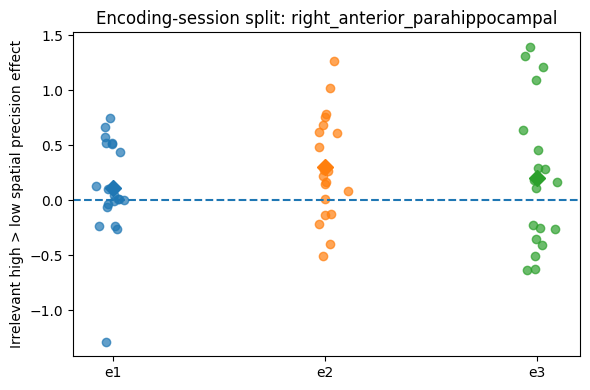

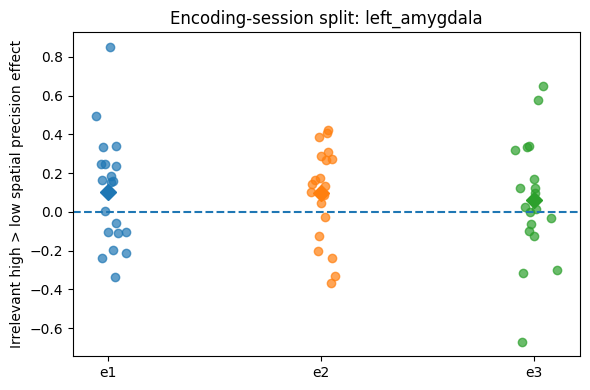

In [83]:
# --------------------------------------------------
# Plot temporal profile of peak effects
# --------------------------------------------------

session_order = ["e1", "e2", "e3"]

for peak in temporal_peak_df["peak"].unique():
    plt.figure(figsize=(6, 4))
    
    for i, ses in enumerate(session_order):
        vals = temporal_peak_df.query(
            "peak == @peak and encoding_session == @ses"
        )["mean_effect"].dropna().values
        
        x = np.repeat(i, len(vals)) + np.random.normal(0, 0.04, len(vals))
        plt.scatter(x, vals, alpha=0.7)
        
        if len(vals) > 0:
            plt.plot(i, vals.mean(), marker="D", markersize=8)
    
    plt.axhline(0, linestyle="--")
    plt.xticks(range(len(session_order)), session_order)
    plt.ylabel("Irrelevant high > low spatial precision effect")
    plt.title(f"Encoding-session split: {peak}")
    plt.tight_layout()
    plt.show()

In [84]:
# --------------------------------------------------
# Wide table for within-subject temporal comparisons
# --------------------------------------------------

temporal_wide = temporal_peak_df.pivot_table(
    index=["sub", "peak"],
    columns="encoding_session",
    values="mean_effect",
).reset_index()

display(temporal_wide.head())

temporal_comparison_rows = []

for peak, df in temporal_wide.groupby("peak"):
    for contrast_name, a, b in [
        ("e1_minus_e3", "e1", "e3"),
        ("e1_minus_e2", "e1", "e2"),
        ("e2_minus_e3", "e2", "e3"),
    ]:
        tmp = df.dropna(subset=[a, b]).copy()
        
        if len(tmp) < 3:
            continue
        
        diff = tmp[a] - tmp[b]
        t_res = ttest_1samp(diff, 0)
        
        try:
            w_res = wilcoxon(diff)
            w_p = w_res.pvalue
        except Exception:
            w_p = np.nan
        
        temporal_comparison_rows.append({
            "peak": peak,
            "contrast": contrast_name,
            "n": len(diff),
            "mean_diff": diff.mean(),
            "std_diff": diff.std(),
            "t": t_res.statistic,
            "p": t_res.pvalue,
            "wilcoxon_p": w_p,
        })

temporal_comparison_df = pd.DataFrame(temporal_comparison_rows)
display(temporal_comparison_df)

encoding_session,sub,peak,e1,e2,e3
0,sub-P10,left_amygdala,-0.105058,-0.202599,0.651820
1,sub-P10,right_anterior_parahippocampal,0.520860,0.780169,1.393360
2,sub-P12,left_amygdala,-0.106035,0.132576,NaN
3,sub-P12,right_anterior_parahippocampal,-0.060299,0.143770,NaN
4,sub-P13,left_amygdala,0.247101,0.384166,0.000284


,peak,contrast,n,mean_diff,std_diff,t,p,wilcoxon_p
0,left_amygdala,e1_minus_e3,19,0.051813,0.502353,0.449584,0.658377,0.622562
1,left_amygdala,e1_minus_e2,20,0.007598,0.418276,0.081236,0.936104,0.647655
2,left_amygdala,e2_minus_e3,19,0.031257,0.408507,0.333524,0.742593,0.679428
3,right_anterior_parahippocampal,e1_minus_e3,19,-0.086777,0.877701,-0.430956,0.671617,0.952984
4,right_anterior_parahippocampal,e1_minus_e2,20,-0.192045,0.805667,-1.066015,0.299776,0.311794
5,right_anterior_parahippocampal,e2_minus_e3,19,0.104636,0.636481,0.716593,0.482820,0.594887


In [85]:
temporal_peak_df.to_csv(
    OUT_DIR_TEMPORAL / "irrelevant_spatial_precision_temporal_peak_effects.csv",
    index=False,
)

temporal_peak_stats_df.to_csv(
    OUT_DIR_TEMPORAL / "irrelevant_spatial_precision_temporal_peak_stats.csv",
    index=False,
)

temporal_wide.to_csv(
    OUT_DIR_TEMPORAL / "irrelevant_spatial_precision_temporal_peak_effects_wide.csv",
    index=False,
)

temporal_comparison_df.to_csv(
    OUT_DIR_TEMPORAL / "irrelevant_spatial_precision_temporal_peak_comparisons.csv",
    index=False,
)

print("Saved temporal peak-level outputs.")

Saved temporal peak-level outputs.


In [86]:
# --------------------------------------------------
# Locate session-specific MTL peaks for e1/e2/e3
# --------------------------------------------------

from nilearn.image import math_img

# Combined MTL mask: hippocampus + amygdala + parahippocampal
mtl_mask = math_img(
    "((hipp > 0) | (amyg > 0) | (phg > 0)).astype(int)",
    hipp=hippocampus_mask,
    amyg=amygdala_mask,
    phg=parahippocampal_mask,
)

session_peak_rows = []

for contrast_name in ["e1_high_vs_low", "e2_high_vs_low", "e3_high_vs_low"]:
    
    group_z = run_second_level_from_maps(
        temporal_maps[contrast_name],
        contrast_name,
        OUT_DIR_TEMPORAL,
    )
    
    # Resample MTL mask to group z-map
    mtl_mask_resampled = image.resample_to_img(
        mtl_mask,
        group_z,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    z_data = group_z.get_fdata()
    mask_data = mtl_mask_resampled.get_fdata().astype(bool)
    
    z_mtl = np.where(mask_data, z_data, np.nan)
    
    # Positive peak: high > low
    max_idx = np.nanargmax(z_mtl)
    max_ijk = np.unravel_index(max_idx, z_mtl.shape)
    max_xyz = nib.affines.apply_affine(group_z.affine, max_ijk)
    max_z = z_mtl[max_ijk]
    
    # Negative peak: low > high
    min_idx = np.nanargmin(z_mtl)
    min_ijk = np.unravel_index(min_idx, z_mtl.shape)
    min_xyz = nib.affines.apply_affine(group_z.affine, min_ijk)
    min_z = z_mtl[min_ijk]
    
    session_peak_rows.append({
        "contrast": contrast_name,
        "encoding_session": contrast_name.split("_")[0],
        "direction": "positive_high_gt_low",
        "x": max_xyz[0],
        "y": max_xyz[1],
        "z": max_xyz[2],
        "peak_z": max_z,
    })
    
    session_peak_rows.append({
        "contrast": contrast_name,
        "encoding_session": contrast_name.split("_")[0],
        "direction": "negative_low_gt_high",
        "x": min_xyz[0],
        "y": min_xyz[1],
        "z": min_xyz[2],
        "peak_z": min_z,
    })

session_mtl_peaks_df = pd.DataFrame(session_peak_rows)

display(session_mtl_peaks_df)

/tmp/ipykernel_2877896/3405859993.py:8: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  mtl_mask = math_img(



Second level: e1_high_vs_low
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/irrelevant_spatial_precision_by_encoding_session/group_e1_high_vs_low_z.nii.gz

Second level: e2_high_vs_low
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/irrelevant_spatial_precision_by_encoding_session/group_e2_high_vs_low_z.nii.gz

Second level: e3_high_vs_low
N maps: 19
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/irrelevant_spatial_precision_by_encoding_session/group_e3_high_vs_low_z.nii.gz


,contrast,encoding_session,direction,x,y,z,peak_z
0,e1_high_vs_low,e1,positive_high_gt_low,-28.5,-7.0,-28.0,3.126695
1,e1_high_vs_low,e1,negative_low_gt_high,-23.5,-34.5,-15.5,-3.615850
2,e2_high_vs_low,e2,positive_high_gt_low,21.5,0.5,-38.0,3.374900
3,e2_high_vs_low,e2,negative_low_gt_high,36.5,-29.5,-13.0,-2.201834
4,e3_high_vs_low,e3,positive_high_gt_low,-28.5,-7.0,-28.0,2.629215
5,e3_high_vs_low,e3,negative_low_gt_high,26.5,-14.5,-33.0,-4.079689


In [87]:
# --------------------------------------------------
# Label session-specific MTL peaks
# --------------------------------------------------

labels_sub = []
labels_cort = []

for _, row in session_mtl_peaks_df.iterrows():
    x, y, z = row["x"], row["y"], row["z"]
    
    labels_sub.append(
        label_peak_with_atlas(x, y, z, subcort_img, subcort_labels)
    )
    
    labels_cort.append(
        label_peak_with_atlas(x, y, z, cort_img, cort_labels)
    )

session_mtl_peaks_df["subcortical_label"] = labels_sub
session_mtl_peaks_df["cortical_label"] = labels_cort

display(session_mtl_peaks_df)

,contrast,encoding_session,direction,x,y,z,peak_z,subcortical_label,cortical_label
0,e1_high_vs_low,e1,positive_high_gt_low,-28.5,-7.0,-28.0,3.126695,Left Hippocampus,Background
1,e1_high_vs_low,e1,negative_low_gt_high,-23.5,-34.5,-15.5,-3.615850,Left Cerebral Cortex,"Parahippocampal Gyrus, posterior division"
2,e2_high_vs_low,e2,positive_high_gt_low,21.5,0.5,-38.0,3.374900,Right Cerebral Cortex,"Parahippocampal Gyrus, anterior division"
3,e2_high_vs_low,e2,negative_low_gt_high,36.5,-29.5,-13.0,-2.201834,Right Hippocampus,Background
4,e3_high_vs_low,e3,positive_high_gt_low,-28.5,-7.0,-28.0,2.629215,Left Hippocampus,Background
5,e3_high_vs_low,e3,negative_low_gt_high,26.5,-14.5,-33.0,-4.079689,Right Cerebral Cortex,"Parahippocampal Gyrus, anterior division"


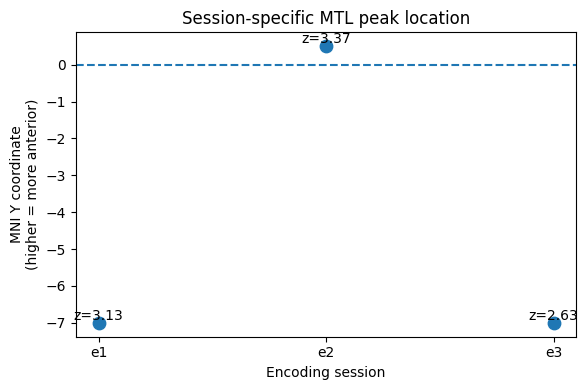

,encoding_session,x,y,z,peak_z,subcortical_label,cortical_label
0,e1,-28.5,-7.0,-28.0,3.126695,Left Hippocampus,Background
2,e2,21.5,0.5,-38.0,3.374900,Right Cerebral Cortex,"Parahippocampal Gyrus, anterior division"
4,e3,-28.5,-7.0,-28.0,2.629215,Left Hippocampus,Background


In [88]:
# --------------------------------------------------
# Plot anterior-posterior coordinate of MTL peaks
# --------------------------------------------------

positive_peaks = session_mtl_peaks_df.query(
    "direction == 'positive_high_gt_low'"
).copy()

plt.figure(figsize=(6, 4))

plt.scatter(
    positive_peaks["encoding_session"],
    positive_peaks["y"],
    s=80,
)

for _, row in positive_peaks.iterrows():
    plt.text(
        row["encoding_session"],
        row["y"],
        f"z={row['peak_z']:.2f}",
        ha="center",
        va="bottom",
    )

plt.axhline(0, linestyle="--")
plt.ylabel("MNI Y coordinate\n(higher = more anterior)")
plt.xlabel("Encoding session")
plt.title("Session-specific MTL peak location")
plt.tight_layout()
plt.show()

display(positive_peaks[[
    "encoding_session",
    "x", "y", "z",
    "peak_z",
    "subcortical_label",
    "cortical_label",
]])

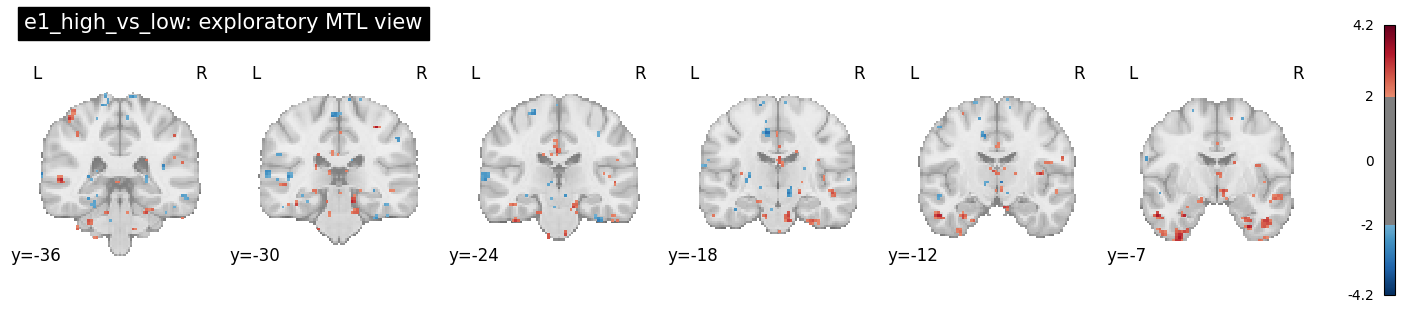

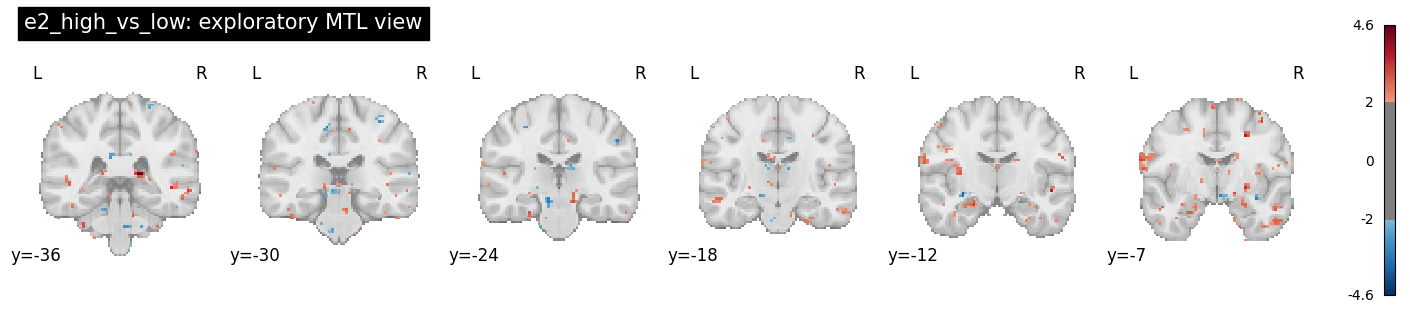

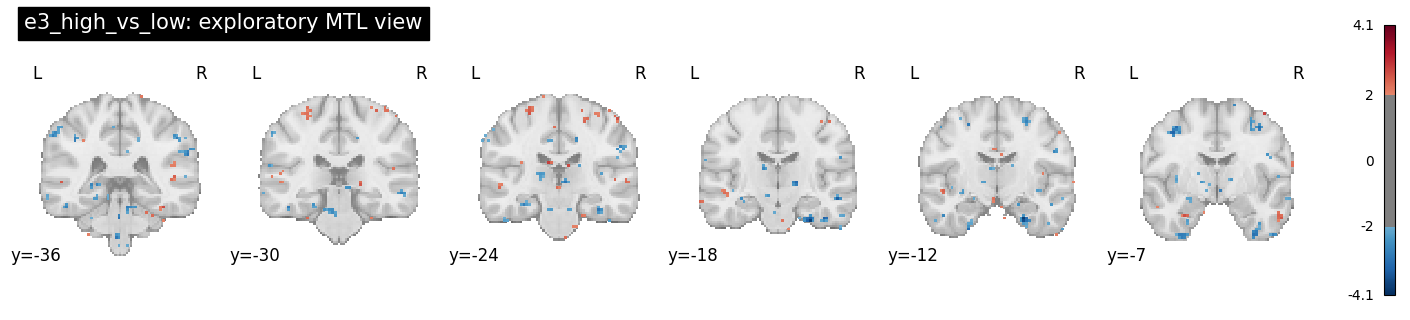

In [89]:
# --------------------------------------------------
# Visualize e1/e2/e3 maps in MTL
# --------------------------------------------------

for contrast_name in ["e1_high_vs_low", "e2_high_vs_low", "e3_high_vs_low"]:
    group_z = nib.load(
        str(OUT_DIR_TEMPORAL / f"group_{contrast_name}_z.nii.gz")
    )
    
    plotting.plot_stat_map(
        group_z,
        threshold=2.0,
        display_mode="y",
        cut_coords=[-36, -30, -24, -18, -12, -7],
        title=f"{contrast_name}: exploratory MTL view",
        colorbar=True,
    )
    plt.show()

In [90]:
# --------------------------------------------------
# Targeted extraction from common left hippocampal peak
# --------------------------------------------------

left_hipp_common_peak = [-28.5, -7.0, -28.0]

left_hipp_rows = []

for contrast_name in ["e1_high_vs_low", "e2_high_vs_low", "e3_high_vs_low"]:
    for effect_path in temporal_maps[contrast_name]:
        sub = effect_path.parts[-2]
        effect_img = nib.load(str(effect_path))
        encoding_session = contrast_name.split("_")[0]
        
        masker = NiftiSpheresMasker(
            seeds=[left_hipp_common_peak],
            radius=5,
            standardize=False,
        )
        
        value = masker.fit_transform(effect_img).ravel()[0]
        
        left_hipp_rows.append({
            "sub": sub,
            "encoding_session": encoding_session,
            "contrast": contrast_name,
            "mean_effect": value,
        })

left_hipp_temporal_df = pd.DataFrame(left_hipp_rows)

display(left_hipp_temporal_df.head())

print(
    left_hipp_temporal_df
    .groupby("encoding_session")["sub"]
    .nunique()
)

,sub,encoding_session,contrast,mean_effect
0,sub-P10,e1,e1_high_vs_low,0.112422
1,sub-P12,e1,e1_high_vs_low,-0.050136
2,sub-P13,e1,e1_high_vs_low,0.262789
3,sub-P14,e1,e1_high_vs_low,-0.113658
4,sub-P15,e1,e1_high_vs_low,0.012747


encoding_session
e1    20
e2    20
e3    19
Name: sub, dtype: int64


In [91]:
# --------------------------------------------------
# Stats for common left hippocampal peak
# --------------------------------------------------

left_hipp_stats_rows = []

for ses, df in left_hipp_temporal_df.groupby("encoding_session"):
    values = df["mean_effect"].dropna()
    
    t_res = ttest_1samp(values, 0)
    
    try:
        w_res = wilcoxon(values)
        w_p = w_res.pvalue
    except Exception:
        w_p = np.nan
    
    left_hipp_stats_rows.append({
        "encoding_session": ses,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_p,
    })

left_hipp_stats_df = pd.DataFrame(left_hipp_stats_rows).sort_values("encoding_session")
display(left_hipp_stats_df)

,encoding_session,n,mean_effect,std,t,p,wilcoxon_p
0,e1,20,0.124542,0.161579,3.447030,0.002701,0.004221
1,e2,20,0.093040,0.144439,2.880723,0.009576,0.017181
2,e3,19,0.083103,0.222742,1.626271,0.121271,0.133621


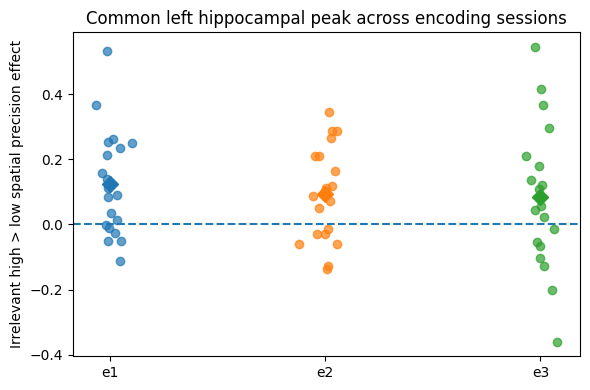

In [92]:
# --------------------------------------------------
# Plot common left hippocampal peak across sessions
# --------------------------------------------------

session_order = ["e1", "e2", "e3"]

plt.figure(figsize=(6, 4))

for i, ses in enumerate(session_order):
    vals = left_hipp_temporal_df.query(
        "encoding_session == @ses"
    )["mean_effect"].dropna().values
    
    x = np.repeat(i, len(vals)) + np.random.normal(0, 0.04, len(vals))
    
    plt.scatter(x, vals, alpha=0.7)
    
    if len(vals) > 0:
        plt.plot(i, vals.mean(), marker="D", markersize=8)

plt.axhline(0, linestyle="--")
plt.xticks(range(len(session_order)), session_order)
plt.ylabel("Irrelevant high > low spatial precision effect")
plt.title("Common left hippocampal peak across encoding sessions")
plt.tight_layout()
plt.show()

In [93]:
left_hipp_temporal_df.to_csv(
    OUT_DIR_TEMPORAL / "common_left_hippocampal_peak_temporal_effects.csv",
    index=False,
)

left_hipp_stats_df.to_csv(
    OUT_DIR_TEMPORAL / "common_left_hippocampal_peak_temporal_stats.csv",
    index=False,
)

print("Saved common left hippocampal peak outputs.")

Saved common left hippocampal peak outputs.


In [9]:
# --------------------------------------------------
# Create frontoparietal and MTL masks
# --------------------------------------------------

from nilearn.image import math_img
from nilearn import image
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp, wilcoxon

# MTL mask: hippocampus + amygdala + parahippocampal
mtl_mask = math_img(
    "((hipp > 0) | (amyg > 0) | (phg > 0)).astype(int)",
    hipp=hippocampus_mask,
    amyg=amygdala_mask,
    phg=parahippocampal_mask,
)

# Build a broad frontoparietal/control mask from Harvard-Oxford cortical labels
frontoparietal_keywords = [
    "Frontal Pole",
    "Middle Frontal Gyrus",
    "Superior Frontal Gyrus",
    "Inferior Frontal Gyrus",
    "Frontal Operculum Cortex",
    "Precentral Gyrus",
    "Juxtapositional Lobule Cortex",
    "Paracingulate Gyrus",
    "Cingulate Gyrus, anterior division",
    "Superior Parietal Lobule",
    "Supramarginal Gyrus",
    "Angular Gyrus",
    "Lateral Occipital Cortex, superior division",
    "Precuneous Cortex",
]

cort_data = cort_img.get_fdata()
frontoparietal_data = np.zeros(cort_data.shape, dtype=int)

for idx, label in enumerate(cort_labels):
    if any(keyword in label for keyword in frontoparietal_keywords):
        frontoparietal_data[cort_data == idx] = 1
        print(idx, label)

frontoparietal_mask = nib.Nifti1Image(
    frontoparietal_data.astype("int16"),
    affine=cort_img.affine,
    header=cort_img.header,
)

print("MTL voxels:", int(np.sum(mtl_mask.get_fdata() > 0)))
print("Frontoparietal voxels:", int(np.sum(frontoparietal_mask.get_fdata() > 0)))

1 Frontal Pole
3 Superior Frontal Gyrus
4 Middle Frontal Gyrus
5 Inferior Frontal Gyrus, pars triangularis
6 Inferior Frontal Gyrus, pars opercularis
7 Precentral Gyrus
18 Superior Parietal Lobule
19 Supramarginal Gyrus, anterior division
20 Supramarginal Gyrus, posterior division
21 Angular Gyrus
22 Lateral Occipital Cortex, superior division
26 Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
28 Paracingulate Gyrus
29 Cingulate Gyrus, anterior division
31 Precuneous Cortex
MTL voxels: 3958
Frontoparietal voxels: 68593


/tmp/ipykernel_3114717/3752998595.py:12: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  mtl_mask = math_img(


In [19]:
# --------------------------------------------------
# Extract ROI effects for relevant vs irrelevant high > low spatial precision
# Exact filename matching to avoid "relevant" matching "irrelevant"
# --------------------------------------------------

roi_masks = {
    "MTL": mtl_mask,
    "frontoparietal": frontoparietal_mask,
    "hippocampus": hippocampus_mask,
    "parahippocampal": parahippocampal_mask,
    "amygdala": amygdala_mask,
}

contrast_names = [
    "irrelevant_high_vs_low",
    "relevant_high_vs_low",
]

roi_effect_rows = []

for contrast_name in contrast_names:
    
    effect_paths = sorted(
        OUT_DIR_INTERACTION.glob(
            f"sub-*/*_{contrast_name}_effect.nii.gz"
        )
    )
    
    print(contrast_name, len(effect_paths))
    
    for effect_path in effect_paths:
        sub = effect_path.parts[-2]
        effect_img = nib.load(str(effect_path))
        
        condition = contrast_name.replace("_high_vs_low", "")
        
        for roi_name, roi_mask in roi_masks.items():
            
            roi_mask_resampled = image.resample_to_img(
                roi_mask,
                effect_img,
                interpolation="nearest",
                force_resample=True,
                copy_header=True,
            )
            
            effect_data = effect_img.get_fdata()
            mask_data = roi_mask_resampled.get_fdata().astype(bool)
            
            mean_effect = np.nanmean(effect_data[mask_data])
            
            roi_effect_rows.append({
                "sub": sub,
                "contrast": contrast_name,
                "condition": condition,
                "roi": roi_name,
                "mean_effect": mean_effect,
            })

roi_effect_df = pd.DataFrame(roi_effect_rows)

display(roi_effect_df.head())

print("\nSubjects per contrast/ROI:")
display(
    roi_effect_df
    .groupby(["condition", "roi"])["sub"]
    .nunique()
    .reset_index()
)

irrelevant_high_vs_low 20
relevant_high_vs_low 20


,sub,contrast,condition,roi,mean_effect
0,sub-P10,irrelevant_high_vs_low,irrelevant,MTL,0.067069
1,sub-P10,irrelevant_high_vs_low,irrelevant,frontoparietal,-0.064147
2,sub-P10,irrelevant_high_vs_low,irrelevant,hippocampus,-0.000273
3,sub-P10,irrelevant_high_vs_low,irrelevant,parahippocampal,0.137868
4,sub-P10,irrelevant_high_vs_low,irrelevant,amygdala,0.012854



Subjects per contrast/ROI:


,condition,roi,sub
0,irrelevant,MTL,20
1,irrelevant,amygdala,20
2,irrelevant,frontoparietal,20
3,irrelevant,hippocampus,20
4,irrelevant,parahippocampal,20
5,relevant,MTL,20
6,relevant,amygdala,20
7,relevant,frontoparietal,20
8,relevant,hippocampus,20
9,relevant,parahippocampal,20


In [20]:
# --------------------------------------------------
# One-sample ROI stats
# --------------------------------------------------

roi_stats_rows = []

for (condition, roi), df in roi_effect_df.groupby(["condition", "roi"]):
    values = df["mean_effect"].dropna()
    
    t_res = ttest_1samp(values, 0)
    
    try:
        w_res = wilcoxon(values)
        w_p = w_res.pvalue
    except Exception:
        w_p = np.nan
    
    roi_stats_rows.append({
        "condition": condition,
        "roi": roi,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_p,
    })

roi_stats_df = pd.DataFrame(roi_stats_rows).sort_values(["roi", "condition"])

display(roi_stats_df)

,condition,roi,n,mean_effect,std,t,p,wilcoxon_p
0,irrelevant,MTL,20,0.018506,0.071534,1.156938,0.261637,0.261099
5,relevant,MTL,20,-0.011921,0.068367,-0.779763,0.445136,0.452375
1,irrelevant,amygdala,20,0.026578,0.106481,1.116248,0.278235,0.311794
6,relevant,amygdala,20,-0.016329,0.098826,-0.738947,0.468971,0.388376
2,irrelevant,frontoparietal,20,-0.005702,0.024334,-1.047909,0.307829,0.329983
7,relevant,frontoparietal,20,0.006713,0.030446,0.986100,0.336476,0.409098
3,irrelevant,hippocampus,20,0.003259,0.079945,0.182302,0.857277,0.756166
8,relevant,hippocampus,20,-0.017774,0.058322,-1.362917,0.188845,0.164957
4,irrelevant,parahippocampal,20,0.026465,0.085783,1.379728,0.183693,0.294252
9,relevant,parahippocampal,20,-0.006180,0.088660,-0.311738,0.758634,0.756166


In [21]:
# --------------------------------------------------
# Paired relevant vs irrelevant comparisons inside each ROI
# --------------------------------------------------

roi_wide = roi_effect_df.pivot_table(
    index=["sub", "roi"],
    columns="condition",
    values="mean_effect",
).reset_index()

display(roi_wide.head())

roi_comparison_rows = []

for roi, df in roi_wide.groupby("roi"):
    tmp = df.dropna(subset=["relevant", "irrelevant"]).copy()
    
    diff_relevant_minus_irrelevant = tmp["relevant"] - tmp["irrelevant"]
    diff_irrelevant_minus_relevant = tmp["irrelevant"] - tmp["relevant"]
    
    t_rel = ttest_1samp(diff_relevant_minus_irrelevant, 0)
    t_irr = ttest_1samp(diff_irrelevant_minus_relevant, 0)
    
    try:
        w_rel = wilcoxon(diff_relevant_minus_irrelevant).pvalue
    except Exception:
        w_rel = np.nan
        
    try:
        w_irr = wilcoxon(diff_irrelevant_minus_relevant).pvalue
    except Exception:
        w_irr = np.nan
    
    roi_comparison_rows.append({
        "roi": roi,
        "n": len(tmp),
        "mean_relevant": tmp["relevant"].mean(),
        "mean_irrelevant": tmp["irrelevant"].mean(),
        "mean_relevant_minus_irrelevant": diff_relevant_minus_irrelevant.mean(),
        "p_relevant_gt_irrelevant": t_rel.pvalue,
        "wilcoxon_relevant_gt_irrelevant": w_rel,
        "mean_irrelevant_minus_relevant": diff_irrelevant_minus_relevant.mean(),
        "p_irrelevant_gt_relevant": t_irr.pvalue,
        "wilcoxon_irrelevant_gt_relevant": w_irr,
    })

roi_comparison_df = pd.DataFrame(roi_comparison_rows).sort_values("roi")

display(roi_comparison_df)

condition,sub,roi,irrelevant,relevant
0,sub-P10,MTL,0.067069,0.007511
1,sub-P10,amygdala,0.012854,0.070999
2,sub-P10,frontoparietal,-0.064147,0.019740
3,sub-P10,hippocampus,-0.000273,-0.045606
4,sub-P10,parahippocampal,0.137868,0.023411


,roi,n,mean_relevant,mean_irrelevant,mean_relevant_minus_irrelevant,p_relevant_gt_irrelevant,wilcoxon_relevant_gt_irrelevant,mean_irrelevant_minus_relevant,p_irrelevant_gt_relevant,wilcoxon_irrelevant_gt_relevant
0,MTL,20,-0.011921,0.018506,-0.030426,0.148694,0.202450,0.030426,0.148694,0.202450
1,amygdala,20,-0.016329,0.026578,-0.042907,0.240086,0.474905,0.042907,0.240086,0.474905
2,frontoparietal,20,0.006713,-0.005702,0.012415,0.144204,0.245487,-0.012415,0.144204,0.245487
3,hippocampus,20,-0.017774,0.003259,-0.021033,0.358429,0.329983,0.021033,0.358429,0.329983
4,parahippocampal,20,-0.006180,0.026465,-0.032646,0.157580,0.176853,0.032646,0.157580,0.176853


In [22]:
# --------------------------------------------------
# Formal ROI x relevance dissociation test
# --------------------------------------------------

dissociation_wide = roi_effect_df.query(
    "roi in ['MTL', 'frontoparietal']"
).pivot_table(
    index="sub",
    columns=["condition", "roi"],
    values="mean_effect",
)

display(dissociation_wide.head())

dissociation_df = dissociation_wide.dropna().copy()

dissociation_df["relevant_fp_minus_mtl"] = (
    dissociation_df[("relevant", "frontoparietal")]
    - dissociation_df[("relevant", "MTL")]
)

dissociation_df["irrelevant_fp_minus_mtl"] = (
    dissociation_df[("irrelevant", "frontoparietal")]
    - dissociation_df[("irrelevant", "MTL")]
)

dissociation_df["dissociation"] = (
    dissociation_df["relevant_fp_minus_mtl"]
    - dissociation_df["irrelevant_fp_minus_mtl"]
)

values = dissociation_df["dissociation"].dropna()

t_res = ttest_1samp(values, 0)

try:
    w_p = wilcoxon(values).pvalue
except Exception:
    w_p = np.nan

dissociation_stats = pd.DataFrame([{
    "n": len(values),
    "mean_dissociation": values.mean(),
    "std": values.std(),
    "t": t_res.statistic,
    "p": t_res.pvalue,
    "wilcoxon_p": w_p,
}])

display(dissociation_stats)
display(dissociation_df.reset_index())

condition irrelevant                 relevant               
roi              MTL frontoparietal       MTL frontoparietal
sub                                                         
sub-P10     0.067069      -0.064147  0.007511       0.019740
sub-P12    -0.094113       0.013842 -0.053051      -0.003673
sub-P13     0.064566      -0.035667  0.130691      -0.028043
sub-P14     0.002391       0.020002 -0.032001      -0.016120
sub-P15     0.023546      -0.000896 -0.022679       0.025903

,n,mean_dissociation,std,t,p,wilcoxon_p
0,20,0.042842,0.104427,1.834712,0.082256,0.123093


condition      sub irrelevant                 relevant                 \
roi                       MTL frontoparietal       MTL frontoparietal   
0          sub-P10   0.067069      -0.064147  0.007511       0.019740   
1          sub-P12  -0.094113       0.013842 -0.053051      -0.003673   
2          sub-P13   0.064566      -0.035667  0.130691      -0.028043   
3          sub-P14   0.002391       0.020002 -0.032001      -0.016120   
4          sub-P15   0.023546      -0.000896 -0.022679       0.025903   
5          sub-P18   0.240844       0.018320 -0.045748       0.081790   
6          sub-P19   0.011460      -0.011376  0.067962       0.016471   
7          sub-P20   0.028769      -0.006102  0.069543      -0.040625   
8          sub-P21  -0.005382       0.011275 -0.053313       0.061911   
9          sub-P23   0.024980      -0.018185 -0.119723       0.014990   
10         sub-P27   0.079260      -0.034242  0.028138       0.009451   
11         sub-P31   0.035383       0.033172 -0.103359      -0.005815   
12         sub-P34  -0.015313      -0.025718 -0.045969      -0.008841   
13         sub-P35  -0.054090       0.005464 -0.116490       0.035086   
14         sub-P41  -0.095691      -0.014766  0.018623       0.018528   
15         sub-P44  -0.025182       0.003265 -0.085782      -0.010648   
16         sub-P45  -0.031865      -0.014752  0.019894       0.009746   
17         sub-P47   0.020412      -0.013782  0.024965      -0.040946   
18         sub-P49   0.054427       0.034168 -0.002120      -0.007477   
19         sub-P50   0.038647      -0.013914  0.074495       0.002836   

condition relevant_fp_minus_mtl irrelevant_fp_minus_mtl dissociation  
roi                                                                   
0                      0.012229               -0.131217     0.143446  
1                      0.049378                0.107955    -0.058578  
2                     -0.158735               -0.100233    -0.058502  
3                      0.015881                0.017611    -0.001730  
4                      0.048583               -0.024442     0.073024  
5                      0.127538               -0.222524     0.350062  
6                     -0.051491               -0.022836    -0.028655  
7                     -0.110168               -0.034871    -0.075297  
8                      0.115224                0.016657     0.098567  
9                      0.134713               -0.043166     0.177879  
10                    -0.018687               -0.113501     0.094814  
11                     0.097543               -0.002211     0.099754  
12                     0.037128               -0.010405     0.047533  
13                     0.151577                0.059554     0.092023  
14                    -0.000095                0.080925    -0.081020  
15                     0.075134                0.028447     0.046687  
16                    -0.010148                0.017113    -0.027261  
17                    -0.065910               -0.034194    -0.031716  
18                    -0.005357               -0.020259     0.014902  
19                    -0.071659               -0.052560    -0.019099

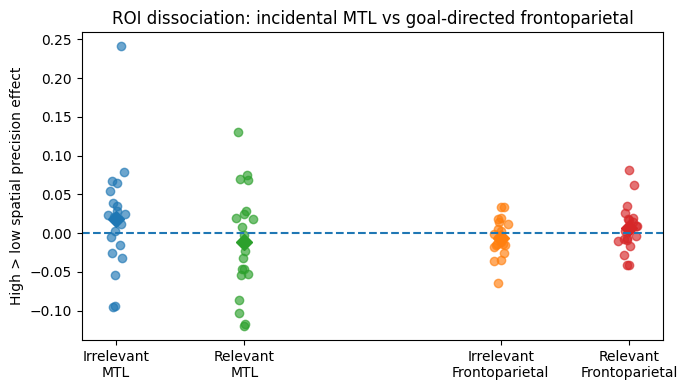

In [23]:
# --------------------------------------------------
# Plot relevant vs irrelevant effects in MTL and frontoparietal ROIs
# --------------------------------------------------

plot_df = roi_effect_df.query("roi in ['MTL', 'frontoparietal']").copy()

plt.figure(figsize=(7, 4))

x_positions = {
    ("irrelevant", "MTL"): 0,
    ("relevant", "MTL"): 1,
    ("irrelevant", "frontoparietal"): 3,
    ("relevant", "frontoparietal"): 4,
}

for (condition, roi), df in plot_df.groupby(["condition", "roi"]):
    x0 = x_positions[(condition, roi)]
    vals = df["mean_effect"].dropna().values
    x = np.repeat(x0, len(vals)) + np.random.normal(0, 0.04, len(vals))
    
    plt.scatter(x, vals, alpha=0.65)
    plt.plot(x0, vals.mean(), marker="D", markersize=8)

plt.axhline(0, linestyle="--")
plt.xticks(
    [0, 1, 3, 4],
    [
        "Irrelevant\nMTL",
        "Relevant\nMTL",
        "Irrelevant\nFrontoparietal",
        "Relevant\nFrontoparietal",
    ],
)
plt.ylabel("High > low spatial precision effect")
plt.title("ROI dissociation: incidental MTL vs goal-directed frontoparietal")
plt.tight_layout()
plt.show()

In [28]:
# --------------------------------------------------
# Corrected peak-level exploratory dissociation
# Exact filename matching
# --------------------------------------------------

peak_rois = {
    "right_anterior_parahippocampal_peak": [19.0, 0.5, -38.0],
    "left_amygdala_peak": [-23.5, -4.5, -28.0],
    
    # Replace with real relevant high > low peaks if available
    "superior_frontal_peak": [14.0, 10.5, 59.5],
    "posterior_parietal_peak": [0.0, -50.0, 40.0],
}

peak_effect_rows = []

for contrast_name in ["irrelevant_high_vs_low", "relevant_high_vs_low"]:
    
    effect_paths = sorted(
        OUT_DIR_INTERACTION.glob(
            f"sub-*/*_{contrast_name}_effect.nii.gz"
        )
    )
    
    print(contrast_name, len(effect_paths))
    
    for effect_path in effect_paths:
        sub = effect_path.parts[-2]
        effect_img = nib.load(str(effect_path))
        condition = contrast_name.replace("_high_vs_low", "")
        
        for peak_name, coord in peak_rois.items():
            masker = NiftiSpheresMasker(
                seeds=[coord],
                radius=5,
                standardize=False,
            )
            
            value = masker.fit_transform(effect_img).ravel()[0]
            
            peak_effect_rows.append({
                "sub": sub,
                "condition": condition,
                "peak": peak_name,
                "mean_effect": value,
            })

peak_effect_df = pd.DataFrame(peak_effect_rows)

display(peak_effect_df.head())

print(
    peak_effect_df
    .groupby(["condition", "peak"])["sub"]
    .nunique()
)

irrelevant_high_vs_low 20
relevant_high_vs_low 20


,sub,condition,peak,mean_effect
0,sub-P10,irrelevant,right_anterior_parahippocampal_peak,1.039685
1,sub-P10,irrelevant,left_amygdala_peak,0.045545
2,sub-P10,irrelevant,superior_frontal_peak,-0.028457
3,sub-P10,irrelevant,posterior_parietal_peak,0.068627
4,sub-P12,irrelevant,right_anterior_parahippocampal_peak,-0.024456


condition   peak                               
irrelevant  left_amygdala_peak                     20
            posterior_parietal_peak                20
            right_anterior_parahippocampal_peak    20
            superior_frontal_peak                  20
relevant    left_amygdala_peak                     20
            posterior_parietal_peak                20
            right_anterior_parahippocampal_peak    20
            superior_frontal_peak                  20
Name: sub, dtype: int64


In [29]:
peak_stats_rows = []

for (condition, peak), df in peak_effect_df.groupby(["condition", "peak"]):
    values = df["mean_effect"].dropna()
    t_res = ttest_1samp(values, 0)
    
    try:
        w_p = wilcoxon(values).pvalue
    except Exception:
        w_p = np.nan
    
    peak_stats_rows.append({
        "condition": condition,
        "peak": peak,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_p,
    })

peak_stats_df = pd.DataFrame(peak_stats_rows).sort_values(["peak", "condition"])
display(peak_stats_df)

,condition,peak,n,mean_effect,std,t,p,wilcoxon_p
0,irrelevant,left_amygdala_peak,20,0.079647,0.139927,2.545557,0.019744,0.026642
4,relevant,left_amygdala_peak,20,-0.022531,0.111783,-0.901401,0.378660,0.474905
1,irrelevant,posterior_parietal_peak,20,-0.004529,0.239257,-0.084658,0.933419,0.812355
5,relevant,posterior_parietal_peak,20,0.050114,0.183655,1.220316,0.237275,0.277355
2,irrelevant,right_anterior_parahippocampal_peak,20,0.216097,0.288455,3.350303,0.003362,0.002325
6,relevant,right_anterior_parahippocampal_peak,20,-0.019784,0.462726,-0.191203,0.850395,0.202450
3,irrelevant,superior_frontal_peak,20,0.038961,0.046065,3.782472,0.001259,0.003654
7,relevant,superior_frontal_peak,20,0.017406,0.084696,0.919069,0.369581,0.621513


In [30]:
peak_wide = peak_effect_df.pivot_table(
    index=["sub", "peak"],
    columns="condition",
    values="mean_effect",
).reset_index()

peak_comparison_rows = []

for peak, df in peak_wide.groupby("peak"):
    tmp = df.dropna(subset=["irrelevant", "relevant"]).copy()
    
    diff_rel_minus_irr = tmp["relevant"] - tmp["irrelevant"]
    diff_irr_minus_rel = tmp["irrelevant"] - tmp["relevant"]
    
    t_rel = ttest_1samp(diff_rel_minus_irr, 0)
    t_irr = ttest_1samp(diff_irr_minus_rel, 0)
    
    try:
        w_rel = wilcoxon(diff_rel_minus_irr).pvalue
    except Exception:
        w_rel = np.nan
    
    try:
        w_irr = wilcoxon(diff_irr_minus_rel).pvalue
    except Exception:
        w_irr = np.nan
    
    peak_comparison_rows.append({
        "peak": peak,
        "n": len(tmp),
        "mean_relevant": tmp["relevant"].mean(),
        "mean_irrelevant": tmp["irrelevant"].mean(),
        "mean_relevant_minus_irrelevant": diff_rel_minus_irr.mean(),
        "p_relevant_gt_irrelevant": t_rel.pvalue,
        "wilcoxon_relevant_gt_irrelevant": w_rel,
        "mean_irrelevant_minus_relevant": diff_irr_minus_rel.mean(),
        "p_irrelevant_gt_relevant": t_irr.pvalue,
        "wilcoxon_irrelevant_gt_relevant": w_irr,
    })

peak_comparison_df = pd.DataFrame(peak_comparison_rows)
display(peak_comparison_df)

,peak,n,mean_relevant,mean_irrelevant,mean_relevant_minus_irrelevant,p_relevant_gt_irrelevant,wilcoxon_relevant_gt_irrelevant,mean_irrelevant_minus_relevant,p_irrelevant_gt_relevant,wilcoxon_irrelevant_gt_relevant
0,left_amygdala_peak,20,-0.022531,0.079647,-0.102178,0.020424,0.069580,0.102178,0.020424,0.069580
1,posterior_parietal_peak,20,0.050114,-0.004529,0.054643,0.422140,0.701181,-0.054643,0.422140,0.701181
2,right_anterior_parahippocampal_peak,20,-0.019784,0.216097,-0.235880,0.081416,0.026642,0.235880,0.081416,0.026642
3,superior_frontal_peak,20,0.017406,0.038961,-0.021555,0.290767,0.189348,0.021555,0.290767,0.189348


In [31]:
roi_effect_df.to_csv(
    OUT_DIR_INTERACTION / "roi_effects_relevant_irrelevant_spatial_precision.csv",
    index=False,
)

roi_stats_df.to_csv(
    OUT_DIR_INTERACTION / "roi_stats_relevant_irrelevant_spatial_precision.csv",
    index=False,
)

roi_comparison_df.to_csv(
    OUT_DIR_INTERACTION / "roi_comparisons_relevant_vs_irrelevant_spatial_precision.csv",
    index=False,
)

dissociation_stats.to_csv(
    OUT_DIR_INTERACTION / "roi_dissociation_relevant_fp_irrelevant_mtl_stats.csv",
    index=False,
)

dissociation_df.reset_index().to_csv(
    OUT_DIR_INTERACTION / "roi_dissociation_relevant_fp_irrelevant_mtl_subjects.csv",
    index=False,
)

print("Saved ROI dissociation outputs.")

Saved ROI dissociation outputs.


In [32]:
# --------------------------------------------------
# Create literature-inspired ROI masks
# --------------------------------------------------

from nilearn import image
from nilearn.image import math_img
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp, wilcoxon
import nibabel as nib

# MTL mask
mtl_mask = math_img(
    "((hipp > 0) | (amyg > 0) | (phg > 0)).astype(int)",
    hipp=hippocampus_mask,
    amyg=amygdala_mask,
    phg=parahippocampal_mask,
)

# Left angular gyrus mask from Harvard-Oxford cortical atlas
cort_data = cort_img.get_fdata()

left_angular_data = np.zeros(cort_data.shape, dtype=np.int16)

for idx, label in enumerate(cort_labels):
    if "Angular Gyrus" in label:
        print(idx, label)
        left_angular_data[cort_data == idx] = 1

left_angular_mask = nib.Nifti1Image(
    left_angular_data,
    affine=cort_img.affine,
    header=cort_img.header,
)

# Right parahippocampal mask: approximate by x > 0 within parahippocampal mask
phg_data = parahippocampal_mask.get_fdata()
coords = np.indices(phg_data.shape)
xyz = nib.affines.apply_affine(parahippocampal_mask.affine, coords.reshape(3, -1).T)
x_coords = xyz[:, 0].reshape(phg_data.shape)

right_phg_data = ((phg_data > 0) & (x_coords > 0)).astype(np.int16)

right_parahippocampal_mask = nib.Nifti1Image(
    right_phg_data,
    affine=parahippocampal_mask.affine,
    header=parahippocampal_mask.header,
)

literature_roi_masks = {
    "hippocampus": hippocampus_mask,
    "left_angular_gyrus": left_angular_mask,
    "right_parahippocampal": right_parahippocampal_mask,
    "parahippocampal": parahippocampal_mask,
    "MTL": mtl_mask,
}

for name, mask in literature_roi_masks.items():
    print(name, int(np.sum(mask.get_fdata() > 0)))

21 Angular Gyrus
hippocampus 1391
left_angular_gyrus 2409
right_parahippocampal 980
parahippocampal 1958
MTL 3958


/tmp/ipykernel_3114717/3501218217.py:13: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  mtl_mask = math_img(


In [47]:
# --------------------------------------------------
# Trial-wise spatial precision variable
# --------------------------------------------------

precision_items = item_memory_all.copy()

precision_items = precision_items.dropna(subset=[
    "placement_distance",
    "event_filename",
    "is_relevant",
    "sub",
]).copy()

# Higher value = better spatial precision
# z-score within subject to avoid subject-level scale differences
precision_items["placement_distance_z"] = (
    precision_items
    .groupby("sub")["placement_distance"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

precision_items["spatial_precision_z"] = -precision_items["placement_distance_z"]

precision_items["relevance_label"] = np.where(
    precision_items["is_relevant"],
    "relevant",
    "irrelevant",
)

print("Precision items:", precision_items.shape)

print("\nRelevance counts:")
print(precision_items["relevance_label"].value_counts())

print("\nPrecision summary:")
display(
    precision_items
    .groupby("relevance_label")["spatial_precision_z"]
    .describe()
)

print("\nSubjects:")
print(precision_items["sub"].nunique())

Precision items: (846, 27)

Relevance counts:
relevance_label
relevant      430
irrelevant    416
Name: count, dtype: int64

Precision summary:


,count,mean,std,min,25%,50%,75%,max
relevance_label,,,,,,,,
irrelevant,416.0,-0.063658,1.032476,-3.424013,-0.776025,0.078276,0.713946,1.820022
relevant,430.0,0.061585,0.941520,-3.395868,-0.466672,0.231673,0.728833,1.816786



Subjects:
20


In [48]:
# --------------------------------------------------
# Output folders for trial-wise precision GLM
# --------------------------------------------------

OUT_DIR_PRECISION_PARAM = PROJECT_ROOT / "data" / "processed" / "glm" / "trialwise_spatial_precision_parametric"
OUT_DIR_PRECISION_PARAM.mkdir(parents=True, exist_ok=True)

EVENTS_OUT_DIR_PRECISION_PARAM = PROJECT_ROOT / "data" / "preprocessed" / "relabeled_events_trialwise_spatial_precision_parametric"
EVENTS_OUT_DIR_PRECISION_PARAM.mkdir(parents=True, exist_ok=True)

print("OUT_DIR_PRECISION_PARAM:", OUT_DIR_PRECISION_PARAM)
print("EVENTS_OUT_DIR_PRECISION_PARAM:", EVENTS_OUT_DIR_PRECISION_PARAM)

OUT_DIR_PRECISION_PARAM: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/trialwise_spatial_precision_parametric
EVENTS_OUT_DIR_PRECISION_PARAM: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_trialwise_spatial_precision_parametric


In [49]:
# --------------------------------------------------
# Create parametric modulation events for post-viewing
# --------------------------------------------------

for sub, sub_df in precision_items.groupby("sub"):
    
    ses = "ses-05"
    
    events_path = (
        BIDS_DIR
        / sub
        / ses
        / "func"
        / f"{sub}_{ses}_task-viewing_run-01_events.tsv"
    )
    
    if not events_path.exists():
        print("Missing events:", events_path)
        continue
    
    events = pd.read_csv(events_path, sep="\t")
    
    label_map = sub_df[[
        "event_filename",
        "relevance_label",
        "spatial_precision_z",
        "placement_distance",
    ]].copy()
    
    events_labeled = events.merge(
        label_map,
        left_on="event",
        right_on="event_filename",
        how="left",
    )
    
    glm_rows = []
    
    for _, row in events_labeled.iterrows():
        
        onset = row["onset"]
        duration = row["duration"]
        
        if pd.isna(row["relevance_label"]):
            glm_rows.append({
                "onset": onset,
                "duration": duration,
                "trial_type": "other",
                "modulation": 1.0,
            })
        else:
            relevance = row["relevance_label"]
            precision = row["spatial_precision_z"]
            
            # Main response to this item type
            glm_rows.append({
                "onset": onset,
                "duration": duration,
                "trial_type": f"{relevance}_main",
                "modulation": 1.0,
            })
            
            # Parametric precision regressor
            glm_rows.append({
                "onset": onset,
                "duration": duration,
                "trial_type": f"{relevance}_precision",
                "modulation": precision,
            })
    
    glm_events = pd.DataFrame(glm_rows)
    
    out_path = EVENTS_OUT_DIR_PRECISION_PARAM / f"{sub}_{ses}_task-viewing_run-01_events_trialwise_spatial_precision_parametric.tsv"
    glm_events.to_csv(out_path, sep="\t", index=False)
    
    print("\n", sub)
    print(glm_events["trial_type"].value_counts())
    print("Saved:", out_path)


 sub-P10
trial_type
other                   216
relevant_precision       96
relevant_main            96
irrelevant_precision     72
irrelevant_main          72
Name: count, dtype: int64
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_trialwise_spatial_precision_parametric/sub-P10_ses-05_task-viewing_run-01_events_trialwise_spatial_precision_parametric.tsv

 sub-P12
trial_type
other                   204
relevant_main           108
relevant_precision      108
irrelevant_main          72
irrelevant_precision     72
Name: count, dtype: int64
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_trialwise_spatial_precision_parametric/sub-P12_ses-05_task-viewing_run-01_events_trialwise_spatial_precision_parametric.tsv

 sub-P13
trial_type
other                   132
relevant_main           126
relevant_precision      126
irrelevant_main         126
irrelevant_precision    126
N

In [50]:
def run_subject_trialwise_precision_glm(
    sub,
    smooth_fwhm=5.0,
    fmriprep_dir=FMRIPREP_DIR,
    events_dir=EVENTS_OUT_DIR_PRECISION_PARAM,
):
    ses = "ses-05"
    
    bold_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*space-MNI152NLin2009cAsym*desc-preproc_bold.nii.gz"
        )
    )
    
    confound_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*desc-confounds_timeseries.tsv"
        )
    )
    
    events_path = events_dir / f"{sub}_{ses}_task-viewing_run-01_events_trialwise_spatial_precision_parametric.tsv"
    
    if len(bold_candidates) == 0 or len(confound_candidates) == 0 or not events_path.exists():
        print("Missing files for", sub)
        return None
    
    bold_img = nib.load(str(bold_candidates[0]))
    events = pd.read_csv(events_path, sep="\t")
    confounds = pd.read_csv(confound_candidates[0], sep="\t")
    
    print("\n" + "="*70)
    print(sub)
    print("="*70)
    print(events["trial_type"].value_counts())
    
    confound_cols = [
        "trans_x", "trans_y", "trans_z",
        "rot_x", "rot_y", "rot_z",
        "global_signal", "csf", "white_matter",
    ]
    
    available_confound_cols = [c for c in confound_cols if c in confounds.columns]
    selected_confounds = confounds[available_confound_cols].copy()
    selected_confounds = selected_confounds.replace([np.inf, -np.inf], np.nan)
    selected_confounds = selected_confounds.fillna(0)
    
    gm_mask = datasets.load_mni152_gm_mask(threshold=0.2)
    gm_mask_resampled = image.resample_to_img(
        gm_mask,
        bold_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    fmri_glm = FirstLevelModel(
        t_r=1.0,
        slice_time_ref=0.5,
        hrf_model="spm + derivative + dispersion",
        drift_model="cosine",
        high_pass=0.01,
        mask_img=gm_mask_resampled,
        smoothing_fwhm=smooth_fwhm,
        standardize=False,
        signal_scaling=0,
        noise_model="ar1",
        minimize_memory=False,
        n_jobs=-1,
    )
    
    fmri_glm = fmri_glm.fit(
        run_imgs=bold_img,
        events=events,
        confounds=selected_confounds,
    )
    
    design_matrix = fmri_glm.design_matrices_[0]
    
    print("Design columns containing precision:")
    print([c for c in design_matrix.columns if "precision" in c])
    
    def make_contrast(weights):
        contrast_vec = np.zeros(len(design_matrix.columns))
        valid = True
        
        for name, weight in weights.items():
            if name in design_matrix.columns:
                contrast_vec[design_matrix.columns.get_loc(name)] = weight
            else:
                print("Missing regressor:", name)
                valid = False
        
        if not valid:
            return None
        
        return contrast_vec
    
    contrast_specs = {
        "irrelevant_precision_slope": {
            "irrelevant_precision": 1.0,
        },
        "relevant_precision_slope": {
            "relevant_precision": 1.0,
        },
        "all_precision_slope": {
            "irrelevant_precision": 0.5,
            "relevant_precision": 0.5,
        },
        "irrelevant_gt_relevant_precision_slope": {
            "irrelevant_precision": 1.0,
            "relevant_precision": -1.0,
        },
        "relevant_gt_irrelevant_precision_slope": {
            "relevant_precision": 1.0,
            "irrelevant_precision": -1.0,
        },
    }
    
    z_maps = {}
    effect_maps = {}
    
    for contrast_name, weights in contrast_specs.items():
        contrast_vec = make_contrast(weights)
        
        if contrast_vec is None:
            print("Skipping contrast:", contrast_name)
            continue
        
        z_maps[contrast_name] = fmri_glm.compute_contrast(
            contrast_vec,
            output_type="z_score",
        )
        
        effect_maps[contrast_name] = fmri_glm.compute_contrast(
            contrast_vec,
            output_type="effect_size",
        )
    
    return {
        "sub": sub,
        "glm": fmri_glm,
        "design_matrix": design_matrix,
        "z_maps": z_maps,
        "effect_maps": effect_maps,
    }

In [51]:
precision_param_results = []

precision_param_maps = {
    "irrelevant_precision_slope": [],
    "relevant_precision_slope": [],
    "all_precision_slope": [],
    "irrelevant_gt_relevant_precision_slope": [],
    "relevant_gt_irrelevant_precision_slope": [],
}

for sub in sorted(precision_items["sub"].unique()):
    res = run_subject_trialwise_precision_glm(sub)
    
    if res is None:
        continue
    
    sub_dir = OUT_DIR_PRECISION_PARAM / sub
    sub_dir.mkdir(parents=True, exist_ok=True)
    
    for contrast_name in precision_param_maps.keys():
        if contrast_name not in res["effect_maps"]:
            continue
        
        z_path = sub_dir / f"{sub}_{contrast_name}_z.nii.gz"
        effect_path = sub_dir / f"{sub}_{contrast_name}_effect.nii.gz"
        
        res["z_maps"][contrast_name].to_filename(z_path)
        res["effect_maps"][contrast_name].to_filename(effect_path)
        
        precision_param_maps[contrast_name].append(effect_path)
    
    precision_param_results.append(res)

print("Processed subjects:", len(precision_param_results))
print([r["sub"] for r in precision_param_results])

for contrast_name, paths in precision_param_maps.items():
    print(contrast_name, len(paths))


sub-P10
trial_type
other                   216
relevant_precision       96
relevant_main            96
irrelevant_precision     72
irrelevant_main          72
Name: count, dtype: int64
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Design columns containing precision:
['irrelevant_precision', 'irrelevant_precision_derivative', 'irrelevant_precision_dispersion', 'relevant_precision', 'relevant_precision_derivative', 'relevant_precision_dispersion']

sub-P12
trial_type
other                   204
relevant_main           108
relevant_precision      108
irrelevant_main          72
irrelevant_precision     72
Name: count, dtype: int64
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Design columns containing precision:
['irrelevant_precision', 'irrelevant_precision_derivative', 'irrelevant_precision_dispersion', 'relevant_precision', 'relevant_precision_derivative', 'relevant_precision_dispersion']

sub

/tmp/ipykernel_3114717/991011657.py:71: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


Design columns containing precision:
['irrelevant_precision', 'irrelevant_precision_derivative', 'irrelevant_precision_dispersion', 'relevant_precision', 'relevant_precision_derivative', 'relevant_precision_dispersion']

sub-P34
trial_type
irrelevant_precision    132
irrelevant_main         132
relevant_main           126
other                   126
relevant_precision      126
Name: count, dtype: int64
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Design columns containing precision:
['irrelevant_precision', 'irrelevant_precision_derivative', 'irrelevant_precision_dispersion', 'relevant_precision', 'relevant_precision_derivative', 'relevant_precision_dispersion']

sub-P35
trial_type
relevant_main           132
relevant_precision      132
other                   132
irrelevant_main         120
irrelevant_precision    120
Name: count, dtype: int64
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Desi

/tmp/ipykernel_3114717/991011657.py:71: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


Design columns containing precision:
['irrelevant_precision', 'irrelevant_precision_derivative', 'irrelevant_precision_dispersion', 'relevant_precision', 'relevant_precision_derivative', 'relevant_precision_dispersion']

sub-P44
trial_type
relevant_main           144
relevant_precision      144
irrelevant_main         138
irrelevant_precision    138
other                   102
Name: count, dtype: int64
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Design columns containing precision:
['irrelevant_precision', 'irrelevant_precision_derivative', 'irrelevant_precision_dispersion', 'relevant_precision', 'relevant_precision_derivative', 'relevant_precision_dispersion']

sub-P45
trial_type
irrelevant_precision    138
irrelevant_main         138
relevant_precision      126
relevant_main           126
other                   120
Name: count, dtype: int64
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Desi


Second level: irrelevant_precision_slope
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/trialwise_spatial_precision_parametric/group_irrelevant_precision_slope_z.nii.gz


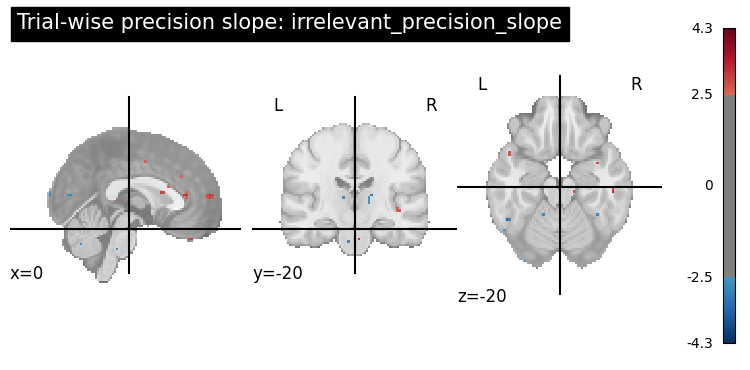


Second level: relevant_precision_slope
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/trialwise_spatial_precision_parametric/group_relevant_precision_slope_z.nii.gz


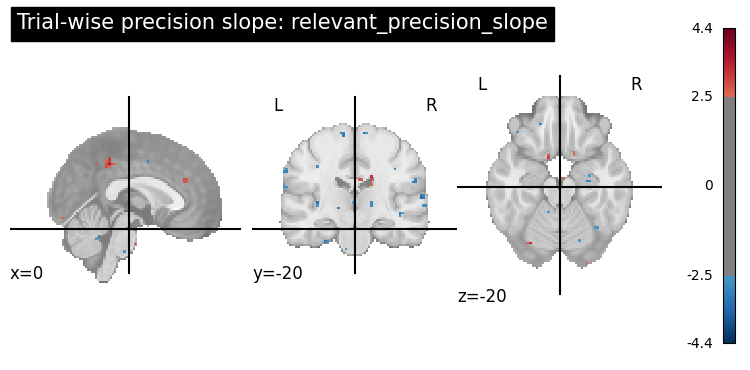


Second level: all_precision_slope
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/trialwise_spatial_precision_parametric/group_all_precision_slope_z.nii.gz


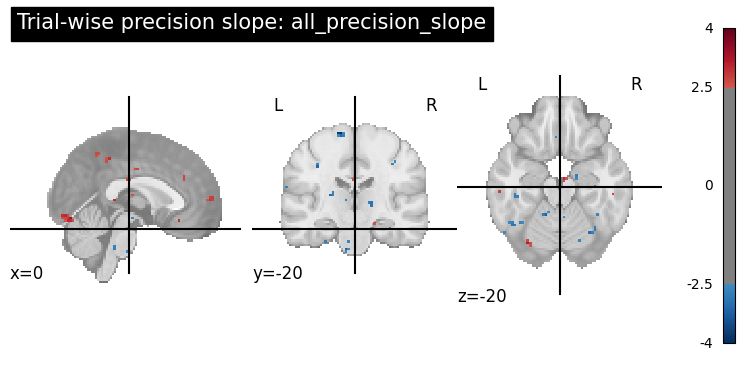


Second level: irrelevant_gt_relevant_precision_slope
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/trialwise_spatial_precision_parametric/group_irrelevant_gt_relevant_precision_slope_z.nii.gz


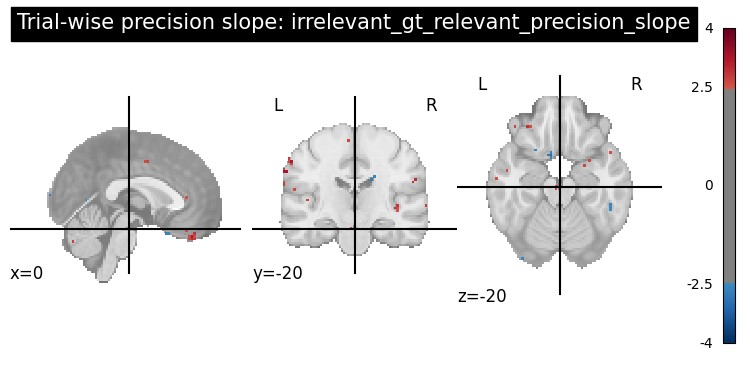


Second level: relevant_gt_irrelevant_precision_slope
N maps: 20
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/trialwise_spatial_precision_parametric/group_relevant_gt_irrelevant_precision_slope_z.nii.gz


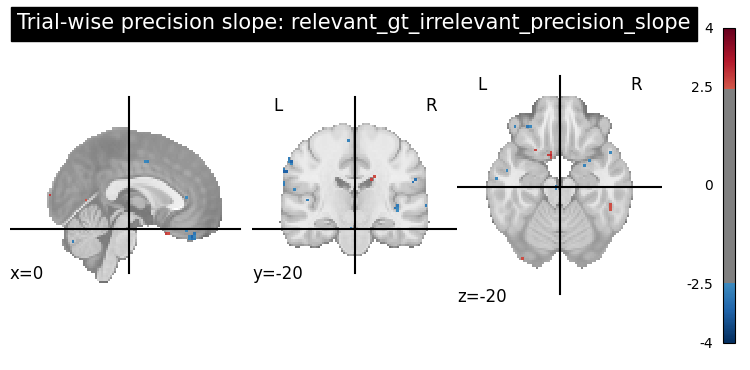

In [55]:
# --------------------------------------------------
# Second-level maps for trial-wise spatial precision
# --------------------------------------------------

precision_group_z_maps = {}

for contrast_name, effect_paths in precision_param_maps.items():
    
    if len(effect_paths) < 5:
        print("Skipping", contrast_name, "not enough maps")
        continue
    
    group_z = run_second_level_from_maps(
        effect_paths,
        contrast_name,
        OUT_DIR_PRECISION_PARAM,
    )
    
    precision_group_z_maps[contrast_name] = group_z
    
    plotting.plot_stat_map(
        group_z,
        threshold=2.5,
        display_mode="ortho",
        cut_coords=(0, -20, -20),
        title=f"Trial-wise precision slope: {contrast_name}",
        colorbar=True,
    )
    plt.show()

In [56]:
# --------------------------------------------------
# ROI extraction: does activity track trial-wise precision?
# --------------------------------------------------

precision_roi_rows = []

for contrast_name, effect_paths in precision_param_maps.items():
    
    for effect_path in effect_paths:
        sub = effect_path.parts[-2]
        effect_img = nib.load(str(effect_path))
        
        for roi_name, roi_mask in literature_roi_masks.items():
            
            roi_mask_resampled = image.resample_to_img(
                roi_mask,
                effect_img,
                interpolation="nearest",
                force_resample=True,
                copy_header=True,
            )
            
            effect_data = effect_img.get_fdata()
            mask_data = roi_mask_resampled.get_fdata().astype(bool)
            
            mean_effect = np.nanmean(effect_data[mask_data])
            
            precision_roi_rows.append({
                "sub": sub,
                "contrast": contrast_name,
                "roi": roi_name,
                "mean_effect": mean_effect,
            })

precision_roi_df = pd.DataFrame(precision_roi_rows)

display(precision_roi_df.head())

print("\nSubjects per contrast/ROI:")
display(
    precision_roi_df
    .groupby(["contrast", "roi"])["sub"]
    .nunique()
    .reset_index()
)

,sub,contrast,roi,mean_effect
0,sub-P10,irrelevant_precision_slope,hippocampus,0.026280
1,sub-P10,irrelevant_precision_slope,left_angular_gyrus,0.010334
2,sub-P10,irrelevant_precision_slope,right_parahippocampal,0.066840
3,sub-P10,irrelevant_precision_slope,parahippocampal,0.060245
4,sub-P10,irrelevant_precision_slope,MTL,0.036655



Subjects per contrast/ROI:


,contrast,roi,sub
0,all_precision_slope,MTL,20
1,all_precision_slope,hippocampus,20
2,all_precision_slope,left_angular_gyrus,20
3,all_precision_slope,parahippocampal,20
4,all_precision_slope,right_parahippocampal,20
5,irrelevant_gt_relevant_precision_slope,MTL,20
6,irrelevant_gt_relevant_precision_slope,hippocampus,20
7,irrelevant_gt_relevant_precision_slope,left_angular_gyrus,20
8,irrelevant_gt_relevant_precision_slope,parahippocampal,20
9,irrelevant_gt_relevant_precision_slope,right_parahippocampal,20


In [57]:
# --------------------------------------------------
# Stats: trial-wise precision slopes in each ROI
# --------------------------------------------------

precision_roi_stats_rows = []

for (contrast_name, roi), df in precision_roi_df.groupby(["contrast", "roi"]):
    values = df["mean_effect"].dropna()
    
    if len(values) < 3:
        continue
    
    t_res = ttest_1samp(values, 0)
    
    try:
        w_res = wilcoxon(values)
        w_p = w_res.pvalue
    except Exception:
        w_p = np.nan
    
    precision_roi_stats_rows.append({
        "contrast": contrast_name,
        "roi": roi,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_p,
    })

precision_roi_stats_df = pd.DataFrame(precision_roi_stats_rows).sort_values(
    ["roi", "contrast"]
)

display(precision_roi_stats_df)

,contrast,roi,n,mean_effect,std,t,p,wilcoxon_p
0,all_precision_slope,MTL,20,-0.000055,0.029603,-0.008328,0.993442,0.756166
5,irrelevant_gt_relevant_precision_slope,MTL,20,0.024768,0.064374,1.720669,0.101556,0.294252
10,irrelevant_precision_slope,MTL,20,0.012571,0.042989,1.307744,0.206563,0.294252
15,relevant_gt_irrelevant_precision_slope,MTL,20,-0.024768,0.064374,-1.720669,0.101556,0.294252
20,relevant_precision_slope,MTL,20,-0.012714,0.044350,-1.282040,0.215252,0.277355
1,all_precision_slope,hippocampus,20,-0.004032,0.029556,-0.610081,0.549036,0.812355
6,irrelevant_gt_relevant_precision_slope,hippocampus,20,0.022277,0.059680,1.669310,0.111450,0.113987
11,irrelevant_precision_slope,hippocampus,20,0.007363,0.041711,0.789415,0.439610,0.329983
16,relevant_gt_irrelevant_precision_slope,hippocampus,20,-0.022277,0.059680,-1.669310,0.111450,0.113987
21,relevant_precision_slope,hippocampus,20,-0.015454,0.041940,-1.647826,0.115827,0.153646


In [58]:
# --------------------------------------------------
# Peak-level precision-slope extraction
# --------------------------------------------------

precision_peak_coords = {
    "left_hippocampus_common_peak": [-28.5, -7.0, -28.0],
    "right_anterior_parahippocampal_peak": [19.0, 0.5, -38.0],
    "left_amygdala_peak": [-23.5, -4.5, -28.0],
}

precision_peak_rows = []

for contrast_name, effect_paths in precision_param_maps.items():
    
    for effect_path in effect_paths:
        sub = effect_path.parts[-2]
        effect_img = nib.load(str(effect_path))
        
        for peak_name, coord in precision_peak_coords.items():
            masker = NiftiSpheresMasker(
                seeds=[coord],
                radius=5,
                standardize=False,
            )
            
            value = masker.fit_transform(effect_img).ravel()[0]
            
            precision_peak_rows.append({
                "sub": sub,
                "contrast": contrast_name,
                "peak": peak_name,
                "mean_effect": value,
            })

precision_peak_df = pd.DataFrame(precision_peak_rows)

display(precision_peak_df.head())

print(
    precision_peak_df
    .groupby(["contrast", "peak"])["sub"]
    .nunique()
)

,sub,contrast,peak,mean_effect
0,sub-P10,irrelevant_precision_slope,left_hippocampus_common_peak,0.121097
1,sub-P10,irrelevant_precision_slope,right_anterior_parahippocampal_peak,0.374438
2,sub-P10,irrelevant_precision_slope,left_amygdala_peak,-0.001002
3,sub-P12,irrelevant_precision_slope,left_hippocampus_common_peak,-0.137012
4,sub-P12,irrelevant_precision_slope,right_anterior_parahippocampal_peak,-0.054042


contrast                                peak                               
all_precision_slope                     left_amygdala_peak                     20
                                        left_hippocampus_common_peak           20
                                        right_anterior_parahippocampal_peak    20
irrelevant_gt_relevant_precision_slope  left_amygdala_peak                     20
                                        left_hippocampus_common_peak           20
                                        right_anterior_parahippocampal_peak    20
irrelevant_precision_slope              left_amygdala_peak                     20
                                        left_hippocampus_common_peak           20
                                        right_anterior_parahippocampal_peak    20
relevant_gt_irrelevant_precision_slope  left_amygdala_peak                     20
                                        left_hippocampus_common_peak           20
                      

In [59]:
# --------------------------------------------------
# Stats: trial-wise precision slopes at peaks
# --------------------------------------------------

precision_peak_stats_rows = []

for (contrast_name, peak), df in precision_peak_df.groupby(["contrast", "peak"]):
    values = df["mean_effect"].dropna()
    
    if len(values) < 3:
        continue
    
    t_res = ttest_1samp(values, 0)
    
    try:
        w_res = wilcoxon(values)
        w_p = w_res.pvalue
    except Exception:
        w_p = np.nan
    
    precision_peak_stats_rows.append({
        "contrast": contrast_name,
        "peak": peak,
        "n": len(values),
        "mean_effect": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_p,
    })

precision_peak_stats_df = pd.DataFrame(precision_peak_stats_rows).sort_values(
    ["peak", "contrast"]
)

display(precision_peak_stats_df)

,contrast,peak,n,mean_effect,std,t,p,wilcoxon_p
0,all_precision_slope,left_amygdala_peak,20,0.010141,0.055308,0.819952,0.422411,0.430433
3,irrelevant_gt_relevant_precision_slope,left_amygdala_peak,20,0.043518,0.118516,1.642118,0.117014,0.105398
6,irrelevant_precision_slope,left_amygdala_peak,20,0.030924,0.069786,1.981719,0.062167,0.113987
9,relevant_gt_irrelevant_precision_slope,left_amygdala_peak,20,-0.043518,0.118516,-1.642118,0.117014,0.105398
12,relevant_precision_slope,left_amygdala_peak,20,-0.012238,0.091575,-0.597648,0.557131,0.409098
1,all_precision_slope,left_hippocampus_common_peak,20,0.013287,0.052717,1.127144,0.273716,0.311794
4,irrelevant_gt_relevant_precision_slope,left_hippocampus_common_peak,20,0.049899,0.112337,1.986495,0.061595,0.032768
7,irrelevant_precision_slope,left_hippocampus_common_peak,20,0.039128,0.072102,2.426938,0.025342,0.021484
10,relevant_gt_irrelevant_precision_slope,left_hippocampus_common_peak,20,-0.049899,0.112337,-1.986495,0.061595,0.032768
13,relevant_precision_slope,left_hippocampus_common_peak,20,-0.011069,0.081037,-0.610836,0.548547,0.294252


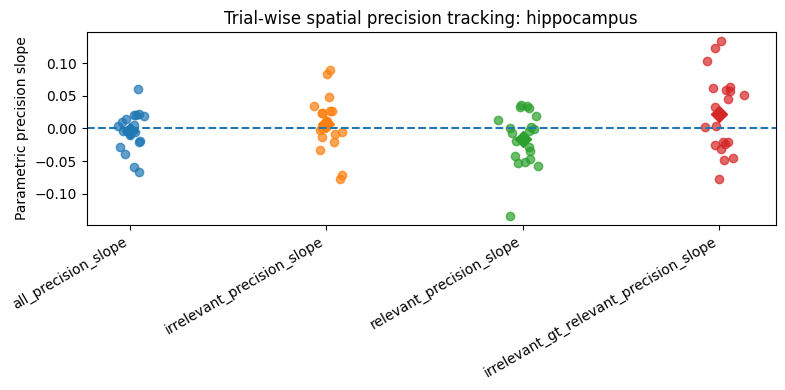

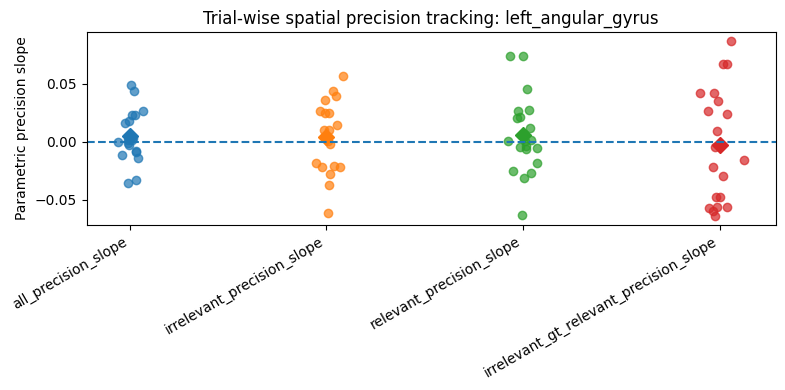

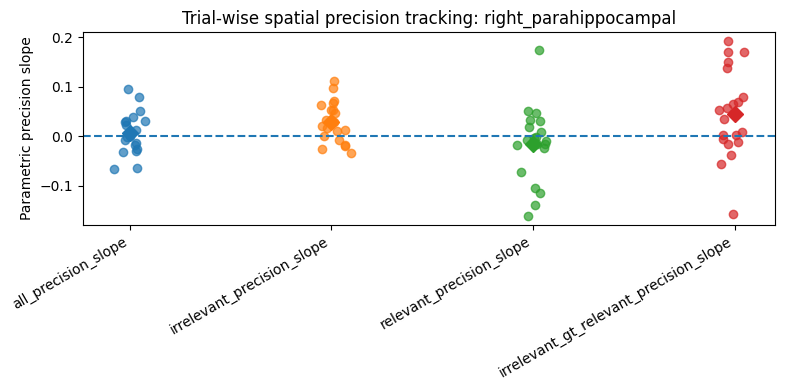

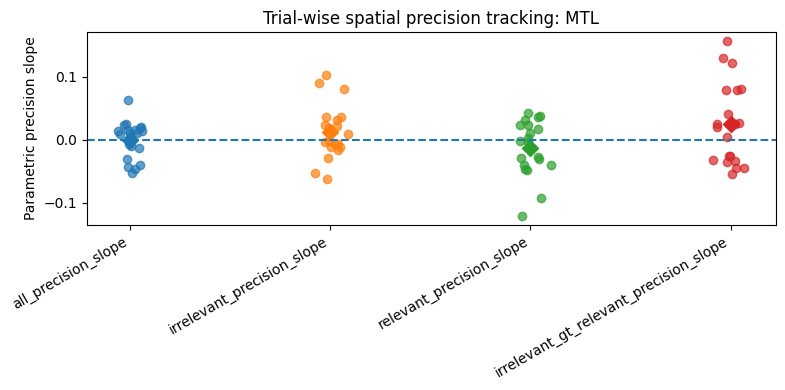

In [60]:
# --------------------------------------------------
# Plot key trial-wise precision effects
# --------------------------------------------------

key_contrasts = [
    "all_precision_slope",
    "irrelevant_precision_slope",
    "relevant_precision_slope",
    "irrelevant_gt_relevant_precision_slope",
]

key_rois = [
    "hippocampus",
    "left_angular_gyrus",
    "right_parahippocampal",
    "MTL",
]

plot_df = precision_roi_df.query(
    "contrast in @key_contrasts and roi in @key_rois"
).copy()

for roi in key_rois:
    plt.figure(figsize=(8, 4))
    
    roi_df = plot_df.query("roi == @roi")
    
    for i, contrast_name in enumerate(key_contrasts):
        vals = roi_df.query("contrast == @contrast_name")["mean_effect"].dropna().values
        x = np.repeat(i, len(vals)) + np.random.normal(0, 0.04, len(vals))
        
        plt.scatter(x, vals, alpha=0.7)
        
        if len(vals) > 0:
            plt.plot(i, vals.mean(), marker="D", markersize=8)
    
    plt.axhline(0, linestyle="--")
    plt.xticks(range(len(key_contrasts)), key_contrasts, rotation=30, ha="right")
    plt.ylabel("Parametric precision slope")
    plt.title(f"Trial-wise spatial precision tracking: {roi}")
    plt.tight_layout()
    plt.show()

In [61]:
precision_roi_df.to_csv(
    OUT_DIR_PRECISION_PARAM / "trialwise_precision_roi_effects.csv",
    index=False,
)

precision_roi_stats_df.to_csv(
    OUT_DIR_PRECISION_PARAM / "trialwise_precision_roi_stats.csv",
    index=False,
)

precision_peak_df.to_csv(
    OUT_DIR_PRECISION_PARAM / "trialwise_precision_peak_effects.csv",
    index=False,
)

precision_peak_stats_df.to_csv(
    OUT_DIR_PRECISION_PARAM / "trialwise_precision_peak_stats.csv",
    index=False,
)

print("Saved trial-wise precision outputs.")

Saved trial-wise precision outputs.
